# 16. Regime Switching models for portfolio selection

In [1]:
from pathlib import Path
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display
from sklearn.calibration import CalibratedClassifierCV
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
    silhouette_score,
)
from sklearn.mixture import BayesianGaussianMixture, GaussianMixture
from sklearn.model_selection import TimeSeriesSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

try:
    from hmmlearn.hmm import GaussianHMM
    hmm_available = True
except Exception:
    GaussianHMM = None
    hmm_available = False

try:
    from lightgbm import LGBMClassifier
    lgbm_available = True
except Exception:
    LGBMClassifier = None
    lgbm_available = False

from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.dataio import load_macro_factors, load_par_yield_curve, load_yfinance_panel, prices_to_returns_panel
from quantfinlab.macro.indicators import (
    condition_blocks,
    expanding_zscore,
    external_demand_stress,
    external_vulnerability,
    goldilocks_support,
    growth_acceleration_stress,
    growth_breadth_stress,
    growth_momentum_stress,
    housing_impulse_stress,
    housing_rate_squeeze,
    inflation_acceleration,
    inflation_diffusion,
    inflation_impulse,
    inflation_level_pressure,
    labor_cooling,
    policy_catchup_risk,
    policy_shock,
    policy_tightness,
    real_rate_squeeze,
    sahm_pressure,
    severe_stress_breadth,
    stagflation_pressure,
    stress_breadth,
    survey_warning,
)
from quantfinlab.macro.models import economic_fci, pca_fci
from quantfinlab.plotting.curves import LAB_COLORS, set_plot_style
from quantfinlab.plotting.diagrams import (
    agglomerative_tree,
    bayesian_mixture,
    ensemble_bagging,
    gmm_mixture,
    hidden_markov_model,
    kmeans_geometry,
    knn_neighbors,
    lda_projection,
    logistic_boundary,
    markov_chain,
    ml_pipeline,
    svm_margin,
    unsupervised_supervised,
    walkforward_split,
)
from quantfinlab.plotting.portfolio import plot_strategy_drawdowns, plot_strategy_nav, plot_turnover
from quantfinlab.plotting.risk import plot_corr_heatmap
from quantfinlab.portfolio import covariance, expected_returns, make_rebalance_dates, optimizers, selection
from quantfinlab.portfolio.cvar import mean_cvar_weight_frame
from quantfinlab.portfolio.robust import wasserstein_weight_frame
from quantfinlab.portfolio.walkforward import run_walkforward_grid
from quantfinlab.reports import risk_report

warnings.filterwarnings("ignore")
set_plot_style()
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

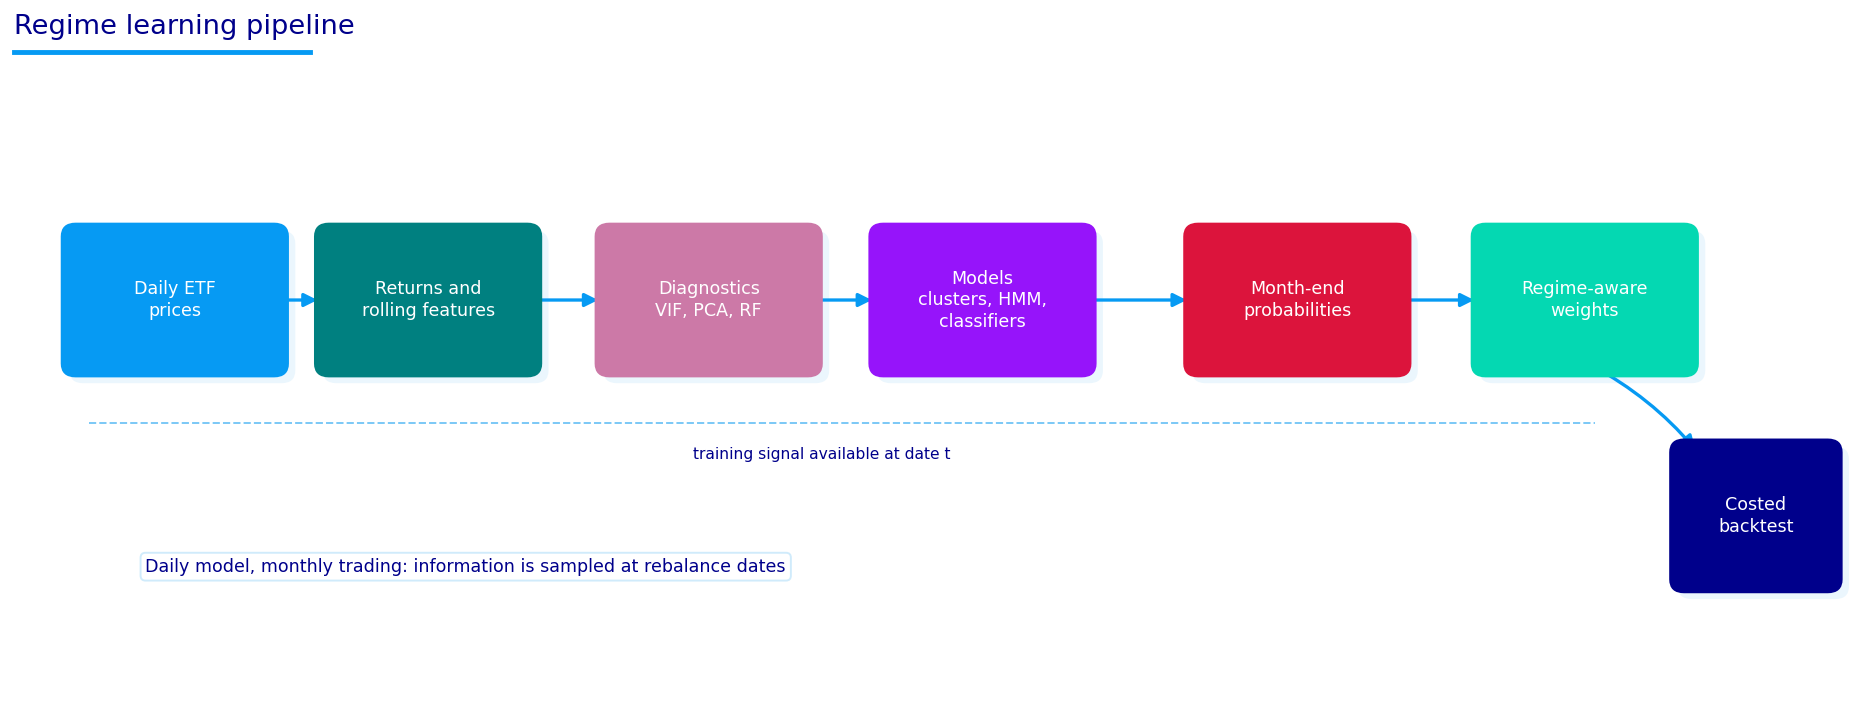

In [2]:
fig, ax = ml_pipeline()
plt.show()

In [3]:
project_title = "Regime Classification and Regime-Switching Portfolio Allocation"
data_path = Path("../data")
etf_path = [data_path / "core_cross_asset_etfs.csv", data_path / "sector_etfs.csv"]
macro_path = data_path / "us_macro_factors.csv"
par_yield_path = data_path / "us_treasury_yields.csv"

assets = [
    "SPY", "QQQ", "IWM", "EFA", "EEM",
    "VNQ", "DBC", "GLD", "IEF", "TLT",
    "LQD", "HYG",
]
cash_ticker = "SHY"
risk_assets = ["SPY", "QQQ", "IWM", "EFA", "EEM", "VNQ", "HYG"]
defensive_assets = ["IEF", "TLT", "GLD", "SHY"]
outcome_assets = ["SPY", "HYG", "TLT", "DBC", "GLD", "EEM"]
context_tickers = ["XLE", "XLU"]
all_tickers = assets + [cash_ticker] + context_tickers

annualization = 252.0
cost_bps = 10.0
train_days = 1260
horizon = 63
horizon_slow = 126
rf_daily = (1.0 + 0.04) ** (1.0 / annualization) - 1.0
regime_names = ["risk_on", "neutral", "defensive"]


In [4]:
panels = load_yfinance_panel(
    etf_path,
    fields=("close", "volume"),
    tickers=sorted(set(all_tickers + outcome_assets)),
    lowercase=False,
)
close = panels["close"].ffill(limit=3).reindex(columns=sorted(set(all_tickers + outcome_assets)))
volume = panels["volume"].ffill(limit=3).reindex(columns=close.columns)
coverage = pd.DataFrame(
    {
        "first": close.apply(pd.Series.first_valid_index),
        "last": close.apply(pd.Series.last_valid_index),
        "observations": close.notna().sum(),
    }
)
display(coverage.loc[all_tickers])

,first,last,observations
SPY,1999-01-04,2026-05-22,7020
QQQ,1999-03-10,2026-05-22,6975
IWM,2000-05-26,2026-05-22,6663
EFA,2001-08-27,2026-05-22,6341
EEM,2003-04-14,2026-05-22,5924
VNQ,2004-09-29,2026-05-22,5548
DBC,2006-02-06,2026-05-22,5199
GLD,2004-11-18,2026-05-22,5512
IEF,2002-07-30,2026-05-22,6105
TLT,2002-07-30,2026-05-22,6105


In [5]:
returns = prices_to_returns_panel(close, kind="simple").fillna(0.0)
returns = returns.reindex(columns=close.columns).fillna(0.0)
monthly_prices = close.resample("ME").last()
rebalance_dates_all = make_rebalance_dates(returns.index, freq="ME", min_history_days=train_days)
print(project_title)
print(close.index.min().date(), "to", close.index.max().date())
print("daily rows:", len(close), "rebalance dates:", len(rebalance_dates_all))

Regime Classification and Regime-Switching Portfolio Allocation
1999-01-04 to 2026-05-22
daily rows: 7020 rebalance dates: 270


In [6]:
rates = load_par_yield_curve(par_yield_path, source="us_treasury").reindex(close.index).ffill()
rates = rates[["3M", "2Y", "10Y"]].dropna(how="all").reindex(close.index).ffill()

x_rates = pd.DataFrame(index=close.index)
x_rates["rate_3m"] = rates["3M"]
x_rates["rate_2y"] = rates["2Y"]
x_rates["rate_10y"] = rates["10Y"]
x_rates["slope_10y_3m"] = rates["10Y"] - rates["3M"]
x_rates["slope_10y_2y"] = rates["10Y"] - rates["2Y"]
x_rates["slope_10y_3m_change_21"] = x_rates["slope_10y_3m"].diff(21)
x_rates["slope_10y_3m_change_63"] = x_rates["slope_10y_3m"].diff(63)
x_rates["slope_10y_3m_change_126"] = x_rates["slope_10y_3m"].diff(126)
x_rates["slope_10y_2y_change_63"] = x_rates["slope_10y_2y"].diff(63)
x_rates["rate_10y_change_63"] = rates["10Y"].diff(63)
x_rates["rate_2y_change_63"] = rates["2Y"].diff(63)
display(x_rates.dropna().tail().round(4))

,rate_3m,rate_2y,rate_10y,slope_10y_3m,slope_10y_2y,slope_10y_3m_change_21,slope_10y_3m_change_63,slope_10y_3m_change_126,slope_10y_2y_change_63,rate_10y_change_63,rate_2y_change_63
date,,,,,,,,,,,
2026-05-18,0.0368,0.0356,0.0426,0.0058,0.007,0.0,0.0,0.0042,0.0,0.0,0.0
2026-05-19,0.0368,0.0356,0.0426,0.0058,0.007,0.0,0.0,0.0040,0.0,0.0,0.0
2026-05-20,0.0368,0.0356,0.0426,0.0058,0.007,0.0,0.0,0.0040,0.0,0.0,0.0
2026-05-21,0.0368,0.0356,0.0426,0.0058,0.007,0.0,0.0,0.0042,0.0,0.0,0.0
2026-05-22,0.0368,0.0356,0.0426,0.0058,0.007,0.0,0.0,0.0042,0.0,0.0,0.0


In [7]:
macro_factors = load_macro_factors(macro_path, start="1990-01-01")
min_macro_history = 60

inflation = pd.concat(
    [
        inflation_level_pressure(macro_factors, min_history=min_macro_history),
        inflation_impulse(macro_factors, min_history=min_macro_history),
        inflation_acceleration(macro_factors, min_history=min_macro_history),
        inflation_diffusion(macro_factors, min_history=min_macro_history),
    ],
    axis=1,
)
policy = pd.concat(
    [
        policy_tightness(macro_factors, min_history=min_macro_history),
        policy_shock(macro_factors, min_history=min_macro_history),
    ],
    axis=1,
)
policy["real_rate_squeeze"] = real_rate_squeeze(policy["policy_tightness"], inflation["inflation_impulse"], min_history=min_macro_history)
policy["policy_catchup_risk"] = policy_catchup_risk(inflation["inflation_level_pressure"], policy["policy_tightness"], min_history=min_macro_history)
growth_macro = pd.concat(
    [
        growth_momentum_stress(macro_factors, min_history=min_macro_history),
        growth_acceleration_stress(macro_factors, min_history=min_macro_history),
        growth_breadth_stress(macro_factors, min_history=min_macro_history),
        survey_warning(macro_factors, min_history=min_macro_history),
    ],
    axis=1,
)
labor = pd.concat(
    [
        labor_cooling(macro_factors, min_history=min_macro_history),
        sahm_pressure(macro_factors, min_history=min_macro_history),
    ],
    axis=1,
)
housing = pd.concat([housing_impulse_stress(macro_factors, min_history=min_macro_history)], axis=1)
housing["housing_rate_squeeze"] = housing_rate_squeeze(housing["housing_impulse_stress"], policy["policy_tightness"])
external = pd.concat(
    [
        external_demand_stress(macro_factors, min_history=min_macro_history),
        external_vulnerability(macro_factors, min_history=min_macro_history),
    ],
    axis=1,
)
macro_signals = pd.concat([inflation, policy, growth_macro, labor, housing, external], axis=1)
macro_breadth = pd.concat(
    [
        stress_breadth(macro_signals, min_history=min_macro_history),
        severe_stress_breadth(macro_signals, min_history=min_macro_history),
        stagflation_pressure(macro_signals),
        goldilocks_support(macro_signals),
    ],
    axis=1,
)
macro_signals = pd.concat([macro_signals, macro_breadth], axis=1)
macro_blocks = condition_blocks(macro_signals)
fci_econ = economic_fci(macro_blocks, min_history=min_macro_history).rename("fci_econ")
fci_pca = pca_fci(macro_blocks, min_history=min_macro_history, min_blocks=5).rename("fci_pca")
fci_blend = expanding_zscore(0.60 * fci_econ + 0.40 * fci_pca, min_history=24).rename("fci_blend")

x_macro_m = pd.concat(
    [
        fci_blend,
        fci_econ,
        fci_pca,
        macro_blocks[[
            "inflation_pressure_block",
            "policy_rate_pressure_block",
            "growth_recession_block",
            "labor_cooling_block",
            "macro_breadth_conflict_block",
        ]],
        macro_breadth[["stress_breadth", "stagflation_pressure", "goldilocks_support"]],
    ],
    axis=1,
)
x_macro_m["fci_change_3m"] = x_macro_m["fci_blend"].diff(3)
x_macro_m["fci_change_6m"] = x_macro_m["fci_blend"].diff(6)
x_macro = x_macro_m.shift(1).reindex(close.index, method="ffill")
display(x_macro_m.dropna(how="all").tail(12).round(3))

,fci_blend,fci_econ,fci_pca,inflation_pressure_block,policy_rate_pressure_block,growth_recession_block,labor_cooling_block,macro_breadth_conflict_block,stress_breadth,stagflation_pressure,goldilocks_support,fci_change_3m,fci_change_6m
date,,,,,,,,,,,,,
2025-02-28,0.370,0.500,-0.070,1.170,-0.359,0.016,-0.579,0.379,0.450,0.359,-0.039,0.556,0.438
2025-03-31,0.326,0.420,-0.051,0.852,-0.272,0.077,-0.588,0.124,0.044,0.330,-0.010,0.522,0.444
2025-04-30,-0.376,-0.394,-0.489,0.217,-0.115,-0.100,-0.553,-0.322,-1.171,0.320,-0.004,-0.613,-0.235
2025-05-31,-0.258,-0.308,-0.340,-0.048,0.102,-0.230,-0.578,-0.131,-0.358,0.289,0.010,-0.628,-0.072
2025-06-30,-0.194,-0.127,-0.462,0.648,-0.093,-0.209,-0.610,-0.223,-0.763,0.313,-0.001,-0.520,0.002
2025-07-31,-0.039,0.065,-0.387,0.920,-0.134,-0.299,-0.593,-0.014,0.050,0.324,-0.012,0.337,-0.277
2025-08-31,-0.049,0.016,-0.337,0.839,-0.246,-0.142,-0.563,0.019,-0.357,0.310,-0.006,0.209,-0.419
2025-09-30,-0.292,-0.257,-0.496,0.622,-0.262,-0.160,-0.515,-0.232,-0.763,0.286,0.010,-0.098,-0.618
2025-10-31,-0.418,-0.450,-0.505,0.355,-0.260,-0.051,-0.494,-0.332,-1.167,0.288,0.008,-0.379,-0.043


In [8]:
asset_ret = returns[assets]
asset_summary = pd.DataFrame(
    {
        "ann_return": asset_ret.mean() * annualization,
        "ann_vol": asset_ret.std(ddof=1) * np.sqrt(annualization),
        "sharpe": asset_ret.mean() / asset_ret.std(ddof=1) * np.sqrt(annualization),
        "max_drawdown": (close[assets] / close[assets].cummax() - 1.0).min(),
        "first_price": close[assets].apply(pd.Series.first_valid_index),
    }
).sort_values("sharpe", ascending=False)
display(asset_summary.round(4))

,ann_return,ann_vol,sharpe,max_drawdown,first_price
GLD,0.0932,0.1591,0.5855,-0.4556,2004-11-18
LQD,0.0407,0.0772,0.5281,-0.2510,2002-07-30
SPY,0.0998,0.1910,0.5226,-0.5519,1999-01-04
QQQ,0.1360,0.2660,0.5114,-0.8296,1999-03-10
IEF,0.0316,0.0629,0.5027,-0.2408,2002-07-30
IWM,0.1038,0.2307,0.4500,-0.5864,2000-05-26
EEM,0.1093,0.2462,0.4438,-0.6643,2003-04-14
HYG,0.0365,0.0904,0.4041,-0.3425,2007-04-11
EFA,0.0745,0.1960,0.3804,-0.6104,2001-08-27
VNQ,0.0885,0.2504,0.3536,-0.7307,2004-09-29


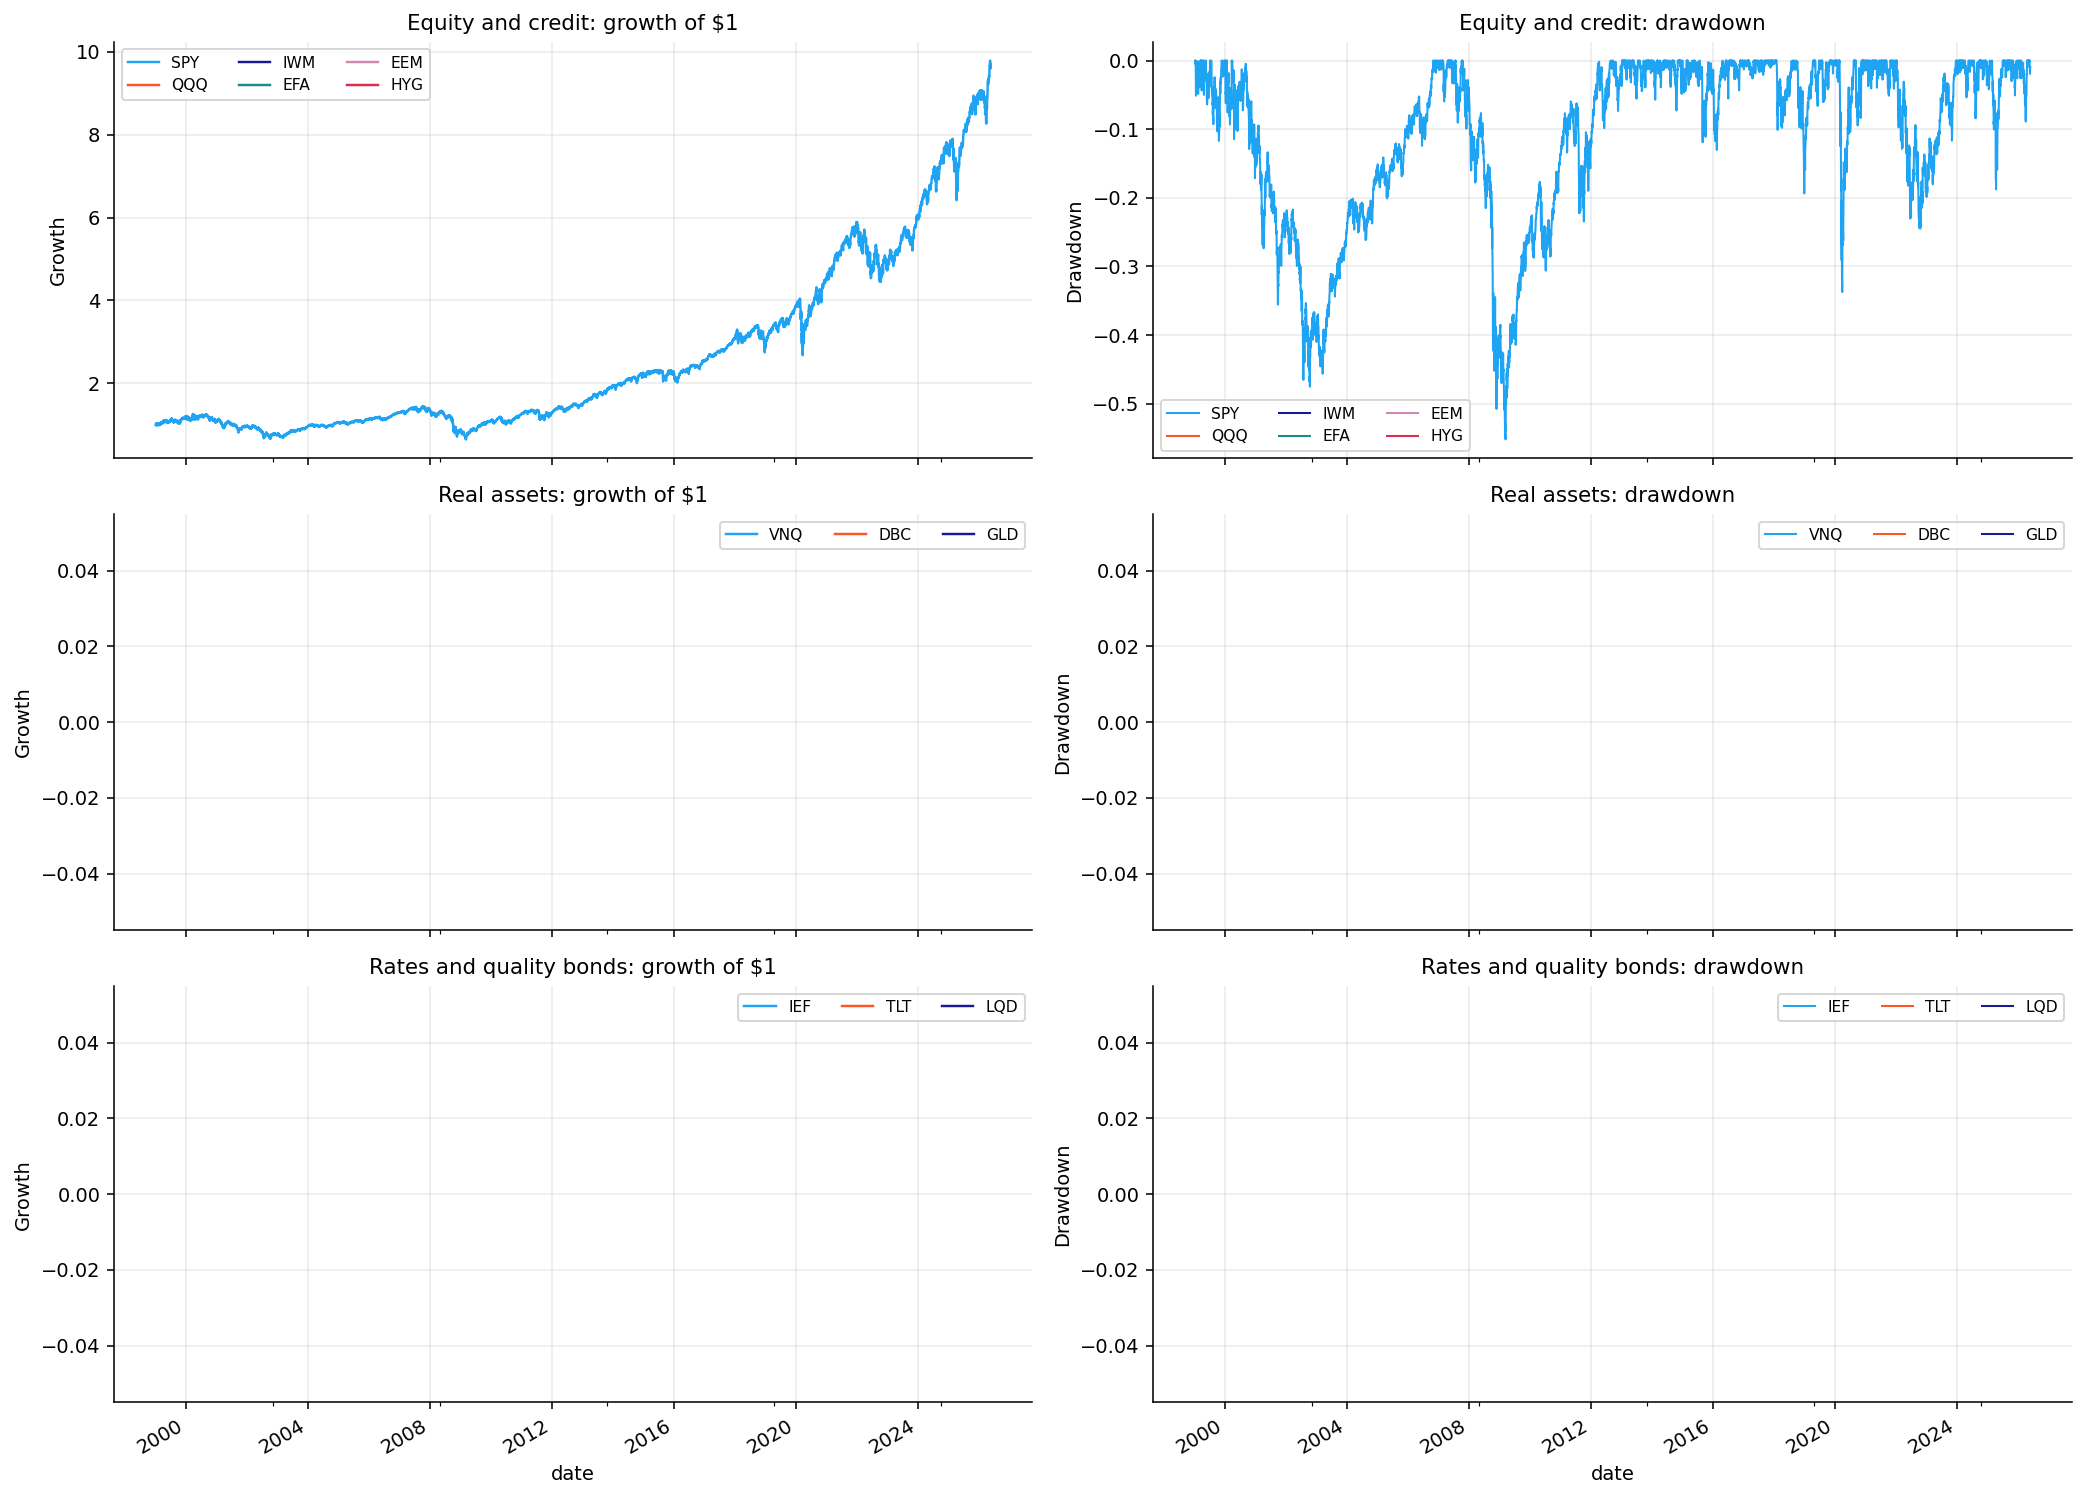

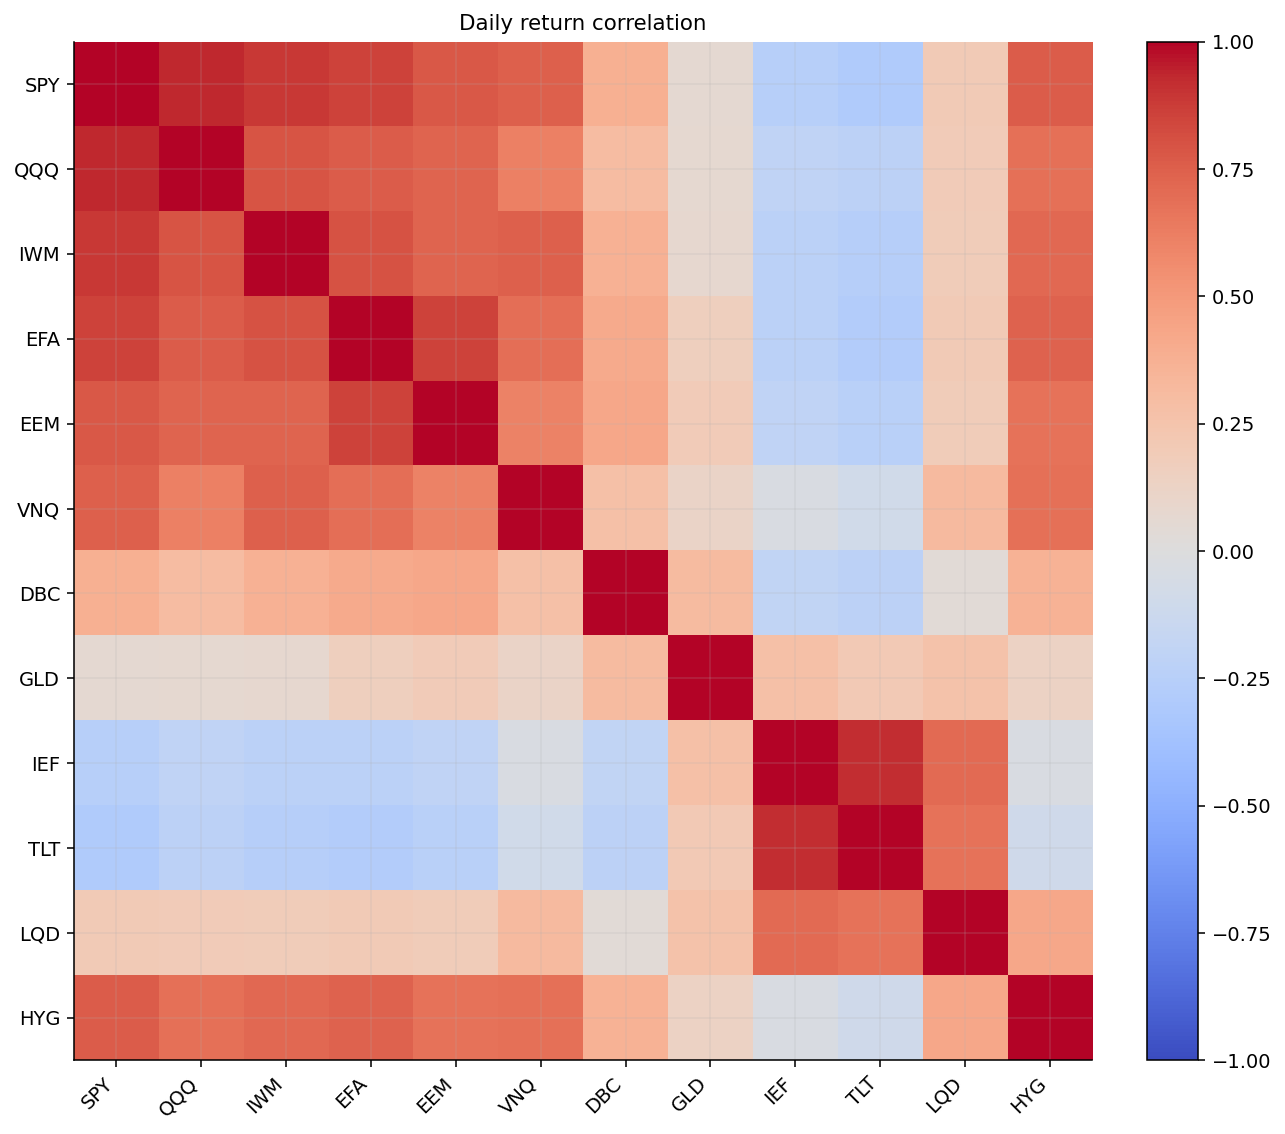

In [9]:
growth = close[assets].dropna(how="all").ffill()
growth = growth.divide(growth.dropna(how="all").iloc[0])
drawdowns = growth / growth.cummax() - 1.0

asset_groups = {
    "Equity and credit": ["SPY", "QQQ", "IWM", "EFA", "EEM", "HYG"],
    "Real assets": ["VNQ", "DBC", "GLD"],
    "Rates and quality bonds": ["IEF", "TLT", "LQD"],
}

fig, axes = plt.subplots(len(asset_groups), 2, figsize=(15.0, 10.8), sharex="col")
for row, (group_name, tickers) in enumerate(asset_groups.items()):
    growth[tickers].plot(ax=axes[row, 0], lw=1.25, alpha=0.9)
    axes[row, 0].set_title(f"{group_name}: growth of $1")
    axes[row, 0].set_ylabel("Growth")
    axes[row, 0].legend(ncol=min(3, len(tickers)), fontsize=8)
    axes[row, 0].grid(True, alpha=0.25)
    drawdowns[tickers].plot(ax=axes[row, 1], lw=1.05, alpha=0.9)
    axes[row, 1].set_title(f"{group_name}: drawdown")
    axes[row, 1].set_ylabel("Drawdown")
    axes[row, 1].legend(ncol=min(3, len(tickers)), fontsize=8)
    axes[row, 1].grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10.5, 8.2))
plot_corr_heatmap(ax, asset_ret.loc["2010":].corr(), title="Daily return correlation", annotate=False)
plt.tight_layout()
plt.show()

In [10]:
benchmark_train_end = pd.Timestamp("2018-12-31")
backtest_cols = assets + [cash_ticker]
benchmark_cov_lookback = 756
benchmark_mu_lookback = 252
benchmark_ewma_lambda = 0.97
benchmark_w_min = 0.0
benchmark_w_max = 0.40
benchmark_mv_lambda = 6.0
benchmark_alt_mv_lambda = 3.0
benchmark_dates = make_rebalance_dates(
    returns.index,
    freq="ME",
    min_history_days=max(benchmark_cov_lookback, benchmark_mu_lookback),
)

w_equal_all = pd.DataFrame(0.0, index=benchmark_dates, columns=backtest_cols)
w_equal_all.loc[:, assets] = 1.0 / len(assets)
display(w_equal_all.head().round(4))

,SPY,QQQ,IWM,EFA,EEM,VNQ,DBC,GLD,IEF,TLT,LQD,HYG,SHY
2001-12-31,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0
2002-01-31,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0
2002-02-28,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0
2002-03-28,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0
2002-04-30,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0


In [11]:
fixed_universe_by_date = {
    pd.Timestamp(dt): {"tickers": list(assets), "avg_dollar_volume": pd.Series(1.0, index=assets)}
    for dt in benchmark_dates
}
benchmark_cov_models = {
    "LedoitWolf": covariance.ledoit_wolf_covariance,
    "OAS": covariance.oas_covariance,
    "EWMA": covariance.ewma_covariance,
}
benchmark_mu_models = {
    "Momentum": expected_returns.momentum_mu,
    "BayesStein": expected_returns.bayes_stein_mu,
    "BayesSteinMomentum": expected_returns.bayes_stein_momentum_mu,
}
mv_specs = [
    {"name": f"{optimizer_name} ({cov_name}, {mu_name})", "optimizer": optimizer_name, "cov_model": cov_name, "mu_model": mu_name}
    for optimizer_name in ["MV", "MaxSharpe"]
    for cov_name in benchmark_cov_models
    for mu_name in benchmark_mu_models
]
mv_grid = run_walkforward_grid(
    returns=returns[assets],
    close=close[assets],
    rebalance_dates=benchmark_dates,
    universe_by_date=fixed_universe_by_date,
    cov_models=benchmark_cov_models,
    mu_models=benchmark_mu_models,
    optimizers={"MV": optimizers.mean_variance, "MaxSharpe": optimizers.max_sharpe_slsqp},
    strategy_specs=mv_specs,
    cov_lookback=benchmark_cov_lookback,
    mu_lookback=benchmark_mu_lookback,
    min_cov_observations=benchmark_cov_lookback - 1,
    min_mu_observations=benchmark_mu_lookback - 1,
    max_weight=benchmark_w_max,
    min_weight=benchmark_w_min,
    trading_cost_bps=cost_bps,
    turnover_penalty_bps=cost_bps,
    fallback="equal",
    annualization=annualization,
    rf_daily=rf_daily,
    ewma_lambda=benchmark_ewma_lambda,
    optimizer_params={"MV": {"mv_lambda": benchmark_mv_lambda}},
)

mv_train_rows = []
for name, res in mv_grid.backtests.items():
    r = res.net_returns.loc[:benchmark_train_end]
    v = (1.0 + r).cumprod()
    m = selection.performance_metrics(r, v, rf_daily=rf_daily, annualization=annualization)
    optimizer_name, mu_name, cov_name = selection.parse_strategy_spec(name, res)
    mv_train_rows.append({"strategy": name, "Optimizer": optimizer_name, "Mu model": mu_name, "Covariance model": cov_name, **m})
mv_train_table = pd.DataFrame(mv_train_rows).set_index("strategy").sort_values(["Sharpe", "Max Drawdown"], ascending=[False, False])
mv_choice = str(
    mv_train_table[mv_train_table["Optimizer"].eq("MV")]
    .sort_values(["Sharpe", "Max Drawdown", "CAGR"], ascending=[False, False, False])
    .index[0]
)
maxsharpe_candidates = mv_grid.results.loc[mv_grid.results["Optimizer"].eq("MaxSharpe")].dropna(subset=["Sharpe"])
maxsharpe_source = str(
    maxsharpe_candidates.sort_values(["Sharpe", "Max Drawdown", "Turnover", "CAGR"], ascending=[False, False, True, False]).index[0]
    if not maxsharpe_candidates.empty
    else mv_choice
)
w_mv_all = mv_grid.backtests[mv_choice].weights.reindex(index=benchmark_dates, columns=assets).fillna(0.0)
w_mv_all[cash_ticker] = 0.0
w_mv_all = w_mv_all.reindex(columns=backtest_cols).fillna(0.0)

_, maxsharpe_mu_model, maxsharpe_cov_model = selection.parse_strategy_spec(maxsharpe_source, mv_grid.backtests[maxsharpe_source])

def prepare_benchmark_weights(w):
    out = w.reindex(index=benchmark_dates, columns=assets).ffill()
    out = out.fillna(1.0 / len(assets))
    out[cash_ticker] = 0.0
    return out.reindex(columns=backtest_cols).fillna(0.0)

w_mean_cvar_all = prepare_benchmark_weights(
    mean_cvar_weight_frame(
        cache=mv_grid.cache,
        rebalance_dates=benchmark_dates,
        cov_model=maxsharpe_cov_model,
        mu_model=maxsharpe_mu_model,
        reference="equal",
        alpha=0.95,
        budget_scale=0.90,
        w_min=benchmark_w_min,
        w_max=benchmark_w_max,
    )
)

w_wasserstein_all = prepare_benchmark_weights(
    wasserstein_weight_frame(
        cache=mv_grid.cache,
        rebalance_dates=benchmark_dates,
        cov_model=maxsharpe_cov_model,
        mu_model=maxsharpe_mu_model,
        radius=0.10,
        mv_lambda=benchmark_alt_mv_lambda,
        w_min=benchmark_w_min,
        w_max=benchmark_w_max,
    )
)

display(mv_train_table.round(4))
print("MV choice:", mv_choice)
print("MaxSharpe source for Mean-CVaR/Wasserstein:", maxsharpe_source)
display(pd.DataFrame(
    {
        "MV source": [mv_choice],
        "Mean-CVaR source": [maxsharpe_source],
        "Mean-CVaR cov": [maxsharpe_cov_model],
        "Mean-CVaR mu": [maxsharpe_mu_model],
        "Wasserstein source": [maxsharpe_source],
        "Wasserstein cov": [maxsharpe_cov_model],
        "Wasserstein mu": [maxsharpe_mu_model],
    }
))

,Optimizer,Mu model,Covariance model,CAGR,Vol,Sharpe,Max Drawdown,Calmar,Sortino
strategy,,,,,,,,,
"MV (EWMA, BayesSteinMomentum)",MV,BayesSteinMomentum,EWMA,0.0602,0.0610,0.3459,-0.0805,0.7481,0.4578
"MV (EWMA, BayesStein)",MV,BayesStein,EWMA,0.0608,0.0651,0.3370,-0.0942,0.6456,0.4443
"MV (OAS, BayesStein)",MV,BayesStein,OAS,0.0593,0.0634,0.3222,-0.0981,0.6049,0.4276
"MV (EWMA, Momentum)",MV,Momentum,EWMA,0.0599,0.0655,0.3216,-0.0856,0.6997,0.4204
"MV (LedoitWolf, BayesStein)",MV,BayesStein,LedoitWolf,0.0598,0.0661,0.3177,-0.1056,0.5660,0.4211
"MV (OAS, Momentum)",MV,Momentum,OAS,0.0556,0.0601,0.2774,-0.0850,0.6537,0.3727
"MV (LedoitWolf, Momentum)",MV,Momentum,LedoitWolf,0.0558,0.0617,0.2752,-0.0874,0.6385,0.3689
"MaxSharpe (LedoitWolf, Momentum)",MaxSharpe,Momentum,LedoitWolf,0.0647,0.1072,0.2730,-0.1514,0.4274,0.3422
"MV (LedoitWolf, BayesSteinMomentum)",MV,BayesSteinMomentum,LedoitWolf,0.0548,0.0586,0.2709,-0.0838,0.6540,0.3636


MV choice: MV (EWMA, BayesSteinMomentum)
MaxSharpe source for Mean-CVaR/Wasserstein: MaxSharpe (LedoitWolf, Momentum)


,MV source,Mean-CVaR source,Mean-CVaR cov,Mean-CVaR mu,Wasserstein source,Wasserstein cov,Wasserstein mu
0,"MV (EWMA, BayesSteinMomentum)","MaxSharpe (LedoitWolf, Momentum)",LedoitWolf,Momentum,"MaxSharpe (LedoitWolf, Momentum)",LedoitWolf,Momentum


In [12]:
def total_ret(ticker, window):
    return close[ticker].astype(float) / close[ticker].astype(float).shift(int(window)) - 1.0

def rel_ret(left, right, window):
    return total_ret(left, window) - total_ret(right, window)

def skip_ret(ticker, lookback=252, skip=21):
    return close[ticker].shift(int(skip)) / close[ticker].shift(int(lookback)) - 1.0

In [13]:
x_eq = pd.DataFrame(index=close.index)
x_eq["spy_252_21"] = skip_ret("SPY", 252, 21)
x_eq["spy_126"] = total_ret("SPY", 126)
x_eq["qqq_spy_126"] = rel_ret("QQQ", "SPY", 126)
x_eq["iwm_spy_126"] = rel_ret("IWM", "SPY", 126)
x_eq["efa_spy_126"] = rel_ret("EFA", "SPY", 126)
x_eq["eem_efa_126"] = rel_ret("EEM", "EFA", 126)
display(x_eq.tail().round(4))

,spy_252_21,spy_126,qqq_spy_126,iwm_spy_126,efa_spy_126,eem_efa_126
date,,,,,,
2026-05-18,0.2319,0.1160,0.0564,0.0758,-0.0043,0.1017
2026-05-19,0.2378,0.1179,0.0615,0.0574,0.0003,0.0880
2026-05-20,0.2297,0.1250,0.0668,0.0800,0.0152,0.0927
2026-05-21,0.2169,0.1424,0.0783,0.0853,0.0138,0.0939
2026-05-22,0.2192,0.1312,0.0805,0.0628,0.0075,0.1117


In [14]:
x_credit = pd.DataFrame(index=close.index)
x_credit["hyg_lqd_126"] = rel_ret("HYG", "LQD", 126)
x_credit["hyg_lqd_63"] = rel_ret("HYG", "LQD", 63)
x_credit["hyg_lqd_change_21"] = x_credit["hyg_lqd_126"] - x_credit["hyg_lqd_126"].shift(21)
x_credit["hyg_lqd_change_63"] = x_credit["hyg_lqd_126"] - x_credit["hyg_lqd_126"].shift(63)
x_credit["hyg_63"] = total_ret("HYG", 63)
x_credit["hyg_dd_252"] = close["HYG"] / close["HYG"].rolling(252, min_periods=63).max() - 1.0
x_credit["hyg_dd_speed_21"] = x_credit["hyg_dd_252"] - x_credit["hyg_dd_252"].shift(21)
x_credit["hyg_vol_63"] = returns["HYG"].rolling(63).std(ddof=1) * np.sqrt(annualization)
x_credit["hyg_downside_semivar_63"] = returns["HYG"].clip(upper=0.0).rolling(63).std(ddof=1) * np.sqrt(annualization)
x_credit["hyg_shy_126"] = rel_ret("HYG", "SHY", 126)
x_credit["lqd_shy_126"] = rel_ret("LQD", "SHY", 126)
x_credit["lqd_ief_126"] = rel_ret("LQD", "IEF", 126)

x_duration = pd.DataFrame(index=close.index)
x_duration["tlt_shy_126"] = rel_ret("TLT", "SHY", 126)
x_duration["ief_shy_126"] = rel_ret("IEF", "SHY", 126)
x_duration["tlt_ief_126"] = rel_ret("TLT", "IEF", 126)

x_real = pd.DataFrame(index=close.index)
x_real["dbc_126"] = total_ret("DBC", 126)
x_real["gld_126"] = total_ret("GLD", 126)
x_real["dbc_ief_126"] = rel_ret("DBC", "IEF", 126)
x_real["gld_spy_126"] = rel_ret("GLD", "SPY", 126)
x_real["xle_spy_126"] = rel_ret("XLE", "SPY", 126)
x_real["xle_xlu_126"] = rel_ret("XLE", "XLU", 126)
display(pd.concat([x_credit, x_duration, x_real], axis=1).tail().round(4))

,hyg_lqd_126,hyg_lqd_63,hyg_lqd_change_21,hyg_lqd_change_63,hyg_63,hyg_dd_252,hyg_dd_speed_21,hyg_vol_63,hyg_downside_semivar_63,hyg_shy_126,lqd_shy_126,lqd_ief_126,tlt_shy_126,ief_shy_126,tlt_ief_126,dbc_126,gld_126,dbc_ief_126,gld_spy_126,xle_spy_126,xle_xlu_126
date,,,,,,,,,,,,,,,,,,,,,
2026-05-18,0.0242,0.0242,-0.0014,0.0304,-0.0009,-0.0086,-0.0086,0.0547,0.0318,0.0136,-0.0107,0.0117,-0.0500,-0.0224,-0.0276,0.4140,0.1259,0.4273,0.0099,0.2455,0.3659
2026-05-19,0.0270,0.0245,0.0012,0.0300,-0.0045,-0.0110,-0.0101,0.0549,0.0318,0.0122,-0.0148,0.0117,-0.0545,-0.0265,-0.0280,0.4126,0.0992,0.4314,-0.0187,0.2486,0.3581
2026-05-20,0.0254,0.0238,-0.0032,0.0309,0.0015,-0.0046,-0.0011,0.0564,0.0318,0.0168,-0.0086,0.0120,-0.0438,-0.0206,-0.0232,0.3939,0.1132,0.4053,-0.0118,0.2257,0.3299
2026-05-21,0.0274,0.0223,-0.0029,0.0315,0.0008,-0.0046,-0.0027,0.0563,0.0318,0.0183,-0.0091,0.0130,-0.0468,-0.0221,-0.0247,0.4074,0.1135,0.4212,-0.0289,0.2238,0.3402
2026-05-22,0.0275,0.0249,-0.0004,0.0350,0.0024,-0.0046,-0.0011,0.0563,0.0319,0.0161,-0.0114,0.0127,-0.0484,-0.0241,-0.0243,0.4167,0.1152,0.4338,-0.0159,0.2265,0.3332


In [15]:
def avg_total_return(tickers, window):
    return pd.concat([total_ret(t, window) for t in tickers], axis=1).mean(axis=1)

x_pressure = pd.DataFrame(index=close.index)
x_pressure["risk_on_63"] = avg_total_return(risk_assets, 63) - avg_total_return(defensive_assets, 63)
x_pressure["risk_on_126"] = avg_total_return(risk_assets, 126) - avg_total_return(defensive_assets, 126)
x_pressure["growth_duration_126"] = rel_ret("QQQ", "TLT", 126)
x_pressure["credit_equity_63"] = rel_ret("HYG", "SPY", 63)
x_pressure["credit_equity_divergence_63"] = rel_ret("HYG", "LQD", 63) - rel_ret("SPY", "IEF", 63)
x_pressure["credit_momentum_minus_equity_126"] = total_ret("HYG", 126) - total_ret("SPY", 126)
x_pressure["hyg_spy_divergence_63"] = total_ret("HYG", 63) - total_ret("SPY", 63)
x_pressure["inflation_duration_126"] = avg_total_return(["DBC", "GLD"], 126) - avg_total_return(["IEF", "TLT"], 126)
x_pressure["inflation_equity_126"] = avg_total_return(["DBC", "GLD", "XLE"], 126) - total_ret("SPY", 126)
x_pressure["duration_stress_63"] = rel_ret("TLT", "SPY", 63)
x_pressure["duration_equity_divergence_126"] = rel_ret("TLT", "IEF", 126) - total_ret("SPY", 126)
display(x_pressure.tail().round(4))

,risk_on_63,risk_on_126,growth_duration_126,credit_equity_63,credit_equity_divergence_63,credit_momentum_minus_equity_126,hyg_spy_divergence_63,inflation_duration_126,inflation_equity_126,duration_stress_63,duration_equity_divergence_126
date,,,,,,,,,,,
2026-05-18,0.0921,0.1110,0.2133,-0.0856,-0.0897,-0.0933,-0.0856,0.2971,0.1845,-0.1446,-0.1435
2026-05-19,0.0939,0.1191,0.2263,-0.0765,-0.0785,-0.0980,-0.0765,0.2887,0.1749,-0.1345,-0.1460
2026-05-20,0.1050,0.1285,0.2265,-0.0844,-0.0874,-0.0991,-0.0844,0.2766,0.1609,-0.1393,-0.1483
2026-05-21,0.1007,0.1455,0.2592,-0.0773,-0.0811,-0.1158,-0.0773,0.2866,0.1533,-0.1293,-0.1671
2026-05-22,0.1170,0.1337,0.2530,-0.0868,-0.0931,-0.1080,-0.0868,0.2952,0.1654,-0.1439,-0.1555


In [16]:
def breadth(tickers, window):
    data = pd.concat([total_ret(t, window) for t in tickers], axis=1)
    return data.gt(0.0).mean(axis=1)

def dispersion(tickers, window):
    data = pd.concat([total_ret(t, window) for t in tickers], axis=1)
    return data.std(axis=1, ddof=1)

def realized_vol(ticker, window):
    return returns[ticker].rolling(int(window)).std(ddof=1) * np.sqrt(annualization)

def drawdown_level(ticker, window):
    return close[ticker] / close[ticker].rolling(int(window), min_periods=max(63, int(window) // 4)).max() - 1.0

def rolling_avg_corr(tickers, window):
    data = returns[tickers].astype(float)
    pairs = []
    for i, left in enumerate(tickers):
        for right in tickers[i + 1:]:
            pairs.append(data[left].rolling(int(window)).corr(data[right]))
    return pd.concat(pairs, axis=1).mean(axis=1)

In [17]:
x_internal = pd.DataFrame(index=close.index)
x_internal["breadth_63"] = breadth(risk_assets, 63)
x_internal["breadth_126"] = breadth(risk_assets, 126)
x_internal["dispersion_21"] = dispersion(risk_assets, 21)
x_internal["dispersion_63"] = dispersion(risk_assets, 63)
x_internal["vol_shock"] = realized_vol("SPY", 21) / realized_vol("SPY", 126)
x_internal["vol_level"] = realized_vol("SPY", 63)
x_internal["vol_change_21"] = x_internal["vol_level"] - x_internal["vol_level"].shift(21)
x_internal["vol_change_63"] = x_internal["vol_level"] - x_internal["vol_level"].shift(63)
x_internal["dd_level"] = drawdown_level("SPY", 252)
x_internal["dd_speed"] = x_internal["dd_level"] - x_internal["dd_level"].shift(21)
x_internal["corr_level"] = rolling_avg_corr(all_tickers, 252)
x_internal["corr_shock"] = rolling_avg_corr(all_tickers, 63) - rolling_avg_corr(all_tickers, 252)
x_internal["corr_change_21"] = x_internal["corr_level"] - x_internal["corr_level"].shift(21)
x_internal["corr_change_63"] = x_internal["corr_level"] - x_internal["corr_level"].shift(63)
x_internal["eq_bond_corr"] = returns["SPY"].rolling(252).corr(returns["TLT"])
x_internal["breadth_speed_21"] = x_internal["breadth_63"] - x_internal["breadth_63"].shift(21)
x_internal["breadth_speed_63"] = x_internal["breadth_126"] - x_internal["breadth_126"].shift(63)
display(x_internal.tail().round(4))

,breadth_63,breadth_126,dispersion_21,dispersion_63,vol_shock,vol_level,vol_change_21,vol_change_63,dd_level,dd_speed,corr_level,corr_shock,corr_change_21,corr_change_63,eq_bond_corr,breadth_speed_21,breadth_speed_63
date,,,,,,,,,,,,,,,,,
2026-05-18,0.7143,1.0,0.0382,0.0658,0.8081,0.1459,-0.0093,0.0331,-0.0127,-0.0127,0.2907,0.0574,0.0098,-0.0529,0.1494,-0.2857,0.0
2026-05-19,0.7143,1.0,0.0386,0.0601,0.8355,0.1466,-0.0087,0.0348,-0.0193,-0.0173,0.2913,0.0581,0.0149,-0.0515,0.1545,-0.2857,0.0
2026-05-20,0.8571,1.0,0.0365,0.0634,0.8283,0.1475,-0.0026,0.0357,-0.0092,-0.0007,0.2919,0.0592,0.0135,-0.0522,0.1614,-0.1429,0.0
2026-05-21,0.8571,1.0,0.0296,0.0614,0.8151,0.1470,-0.0027,0.0392,-0.0092,-0.0092,0.2908,0.0607,0.0124,-0.0533,0.1416,-0.1429,0.0
2026-05-22,0.8571,1.0,0.0325,0.0662,0.8042,0.1452,-0.0045,0.0367,-0.0092,-0.0054,0.2893,0.0684,0.0124,-0.0531,0.1394,-0.1429,0.0


In [18]:
x_all = pd.concat([x_eq, x_credit, x_duration, x_real, x_pressure, x_rates, x_macro, x_internal], axis=1)
x_all = x_all.replace([np.inf, -np.inf], np.nan).dropna()
feature_summary = x_all.describe(percentiles=[0.05, 0.50, 0.95]).T
feature_summary = feature_summary[["mean", "std", "min", "5%", "50%", "95%", "max"]]
display(feature_summary.round(4))
print("candidate features:", x_all.shape)

,mean,std,min,5%,50%,95%,max
spy_252_21,0.1073,0.1589,-0.4846,-0.1949,0.1342,0.3260,0.7820
spy_126,0.0582,0.1139,-0.4500,-0.1249,0.0724,0.2151,0.5130
qqq_spy_126,0.0253,0.0556,-0.1307,-0.0576,0.0238,0.1346,0.2523
iwm_spy_126,-0.0074,0.0723,-0.1899,-0.1116,-0.0116,0.1030,0.3800
efa_spy_126,-0.0278,0.0627,-0.1747,-0.1176,-0.0350,0.0986,0.1998
...,...,...,...,...,...,...,...
corr_change_21,0.0005,0.0193,-0.0857,-0.0241,-0.0003,0.0304,0.1526
corr_change_63,0.0015,0.0375,-0.1033,-0.0555,-0.0023,0.0726,0.1411
eq_bond_corr,-0.2973,0.2568,-0.7650,-0.6853,-0.3602,0.1473,0.3179
breadth_speed_21,0.0021,0.3143,-1.0000,-0.5714,0.0000,0.5714,1.0000


candidate features: (4708, 79)


In [19]:
def feature_vif_local(x):
    z0 = x.replace([np.inf, -np.inf], np.nan).dropna().astype(float)
    rows = []
    for col in z0.columns:
        other = [c for c in z0.columns if c != col]
        if not other:
            rows.append({"feature": col, "r2": np.nan, "vif": np.nan})
            continue
        y0 = z0[col].to_numpy(dtype=float)
        X0 = z0[other].to_numpy(dtype=float)
        r2 = LinearRegression().fit(X0, y0).score(X0, y0)
        vif = np.inf if r2 >= 1.0 - 1e-12 else 1.0 / (1.0 - r2)
        rows.append({"feature": col, "r2": r2, "vif": vif})
    return pd.DataFrame(rows).set_index("feature").sort_values("vif", ascending=False)

def pca_tables_local(x, n_components=10):
    z0 = x.replace([np.inf, -np.inf], np.nan).dropna().astype(float)
    arr = StandardScaler().fit_transform(z0)
    n = min(int(n_components), min(arr.shape))
    pca = PCA(n_components=n, random_state=42).fit(arr)
    cols = [f"PC{i + 1}" for i in range(n)]
    explained = pd.DataFrame(
        {
            "explained_variance": pca.explained_variance_,
            "explained_variance_ratio": pca.explained_variance_ratio_,
            "cumulative": np.cumsum(pca.explained_variance_ratio_),
        },
        index=cols,
    )
    loadings = pd.DataFrame(pca.components_.T, index=z0.columns, columns=cols)
    return explained, loadings

In [20]:
vif_all = feature_vif_local(x_all)
pca_explained_all, pca_loadings_all = pca_tables_local(x_all, n_components=10)
display(vif_all.head(20).round(2))
display(pca_explained_all.round(4))

,r2,vif
feature,,
spy_126,1.0,inf
qqq_spy_126,1.0,inf
hyg_lqd_126,1.0,inf
credit_equity_63,1.0,inf
xle_spy_126,1.0,inf
gld_spy_126,1.0,inf
dbc_ief_126,1.0,inf
gld_126,1.0,inf
dbc_126,1.0,inf


,explained_variance,explained_variance_ratio,cumulative
PC1,19.7895,0.2504,0.2504
PC2,10.4296,0.1320,0.3824
PC3,7.7715,0.0984,0.4808
PC4,6.1362,0.0777,0.5584
PC5,4.5486,0.0576,0.6160
PC6,3.5949,0.0455,0.6615
PC7,3.1126,0.0394,0.7009
PC8,2.1430,0.0271,0.7280
PC9,1.9764,0.0250,0.7530
PC10,1.8611,0.0236,0.7766


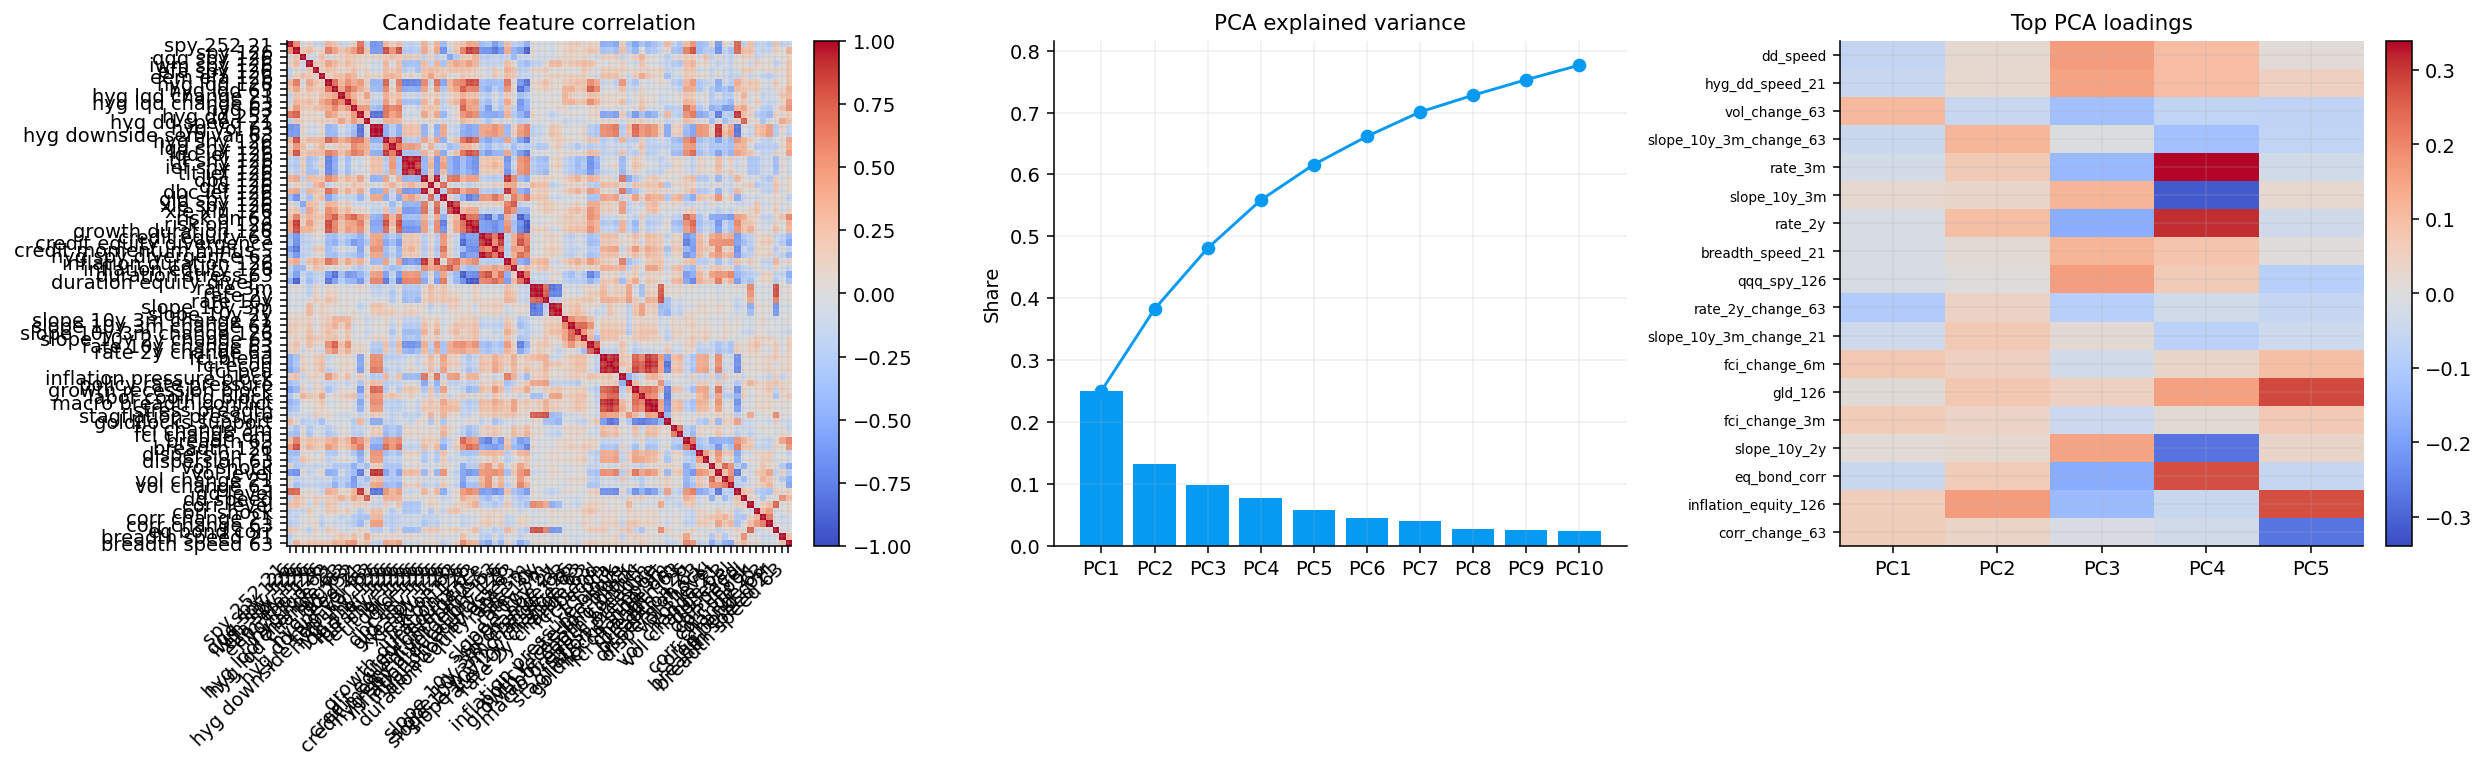

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18.0, 5.4))
plot_corr_heatmap(axes[0], x_all.corr(), title="Candidate feature correlation", annotate=False)
axes[1].bar(range(len(pca_explained_all)), pca_explained_all["explained_variance_ratio"])
axes[1].plot(range(len(pca_explained_all)), pca_explained_all["cumulative"], marker="o")
axes[1].set_xticks(range(len(pca_explained_all)))
axes[1].set_xticklabels(pca_explained_all.index)
axes[1].set_title("PCA explained variance")
axes[1].set_ylabel("Share")
top_loading_rows = pca_loadings_all.abs().max(axis=1).sort_values(ascending=False).head(18).index
load_show = pca_loadings_all.loc[top_loading_rows, pca_loadings_all.columns[:5]]
im = axes[2].imshow(load_show.values, aspect="auto", cmap="coolwarm", vmin=-abs(load_show.values).max(), vmax=abs(load_show.values).max())
axes[2].set_yticks(range(len(load_show.index)))
axes[2].set_yticklabels(load_show.index, fontsize=7)
axes[2].set_xticks(range(len(load_show.columns)))
axes[2].set_xticklabels(load_show.columns)
axes[2].set_title("Top PCA loadings")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [22]:
def state_profile_local(features, labels, outcomes=None):
    lab = pd.Series(labels, name="state")
    parts = [features.copy()]
    if outcomes is not None:
        out = outcomes.copy()
        if isinstance(out, pd.Series):
            out = out.to_frame()
        parts.append(out.add_prefix("outcome_"))
    z0 = pd.concat(parts + [lab], axis=1).replace([np.inf, -np.inf], np.nan).dropna(subset=["state"])
    cols = [c for c in z0.columns if c != "state"]
    prof = z0.groupby("state")[cols].mean()
    prof.insert(0, "share", z0.groupby("state").size() / len(z0))
    prof.insert(0, "observations", z0.groupby("state").size())
    prof.index = prof.index.astype(int)
    return prof.sort_index()

def sort_profile_states(profile):
    cols = [c for c in profile.columns if c not in {"observations", "share"}]
    z0 = profile[cols].astype(float)
    z0 = (z0 - z0.mean(axis=0)) / z0.std(axis=0, ddof=0).replace(0.0, np.nan)
    z0 = z0.fillna(0.0)
    score = pd.Series(0.0, index=profile.index)
    for col in z0.columns:
        name = str(col).lower()
        if "risk_defensive_spread" in name:
            score += 3.0 * z0[col]
            continue
        if any(k in name for k in ["spy", "qqq", "iwm", "efa", "eem", "hyg", "risk_on", "breadth", "growth", "credit", "cyclical", "sector_ew"]):
            score += z0[col]
        if any(k in name for k in ["vol", "corr", "dispersion"]):
            score -= z0[col]
        if "dd" in name or "drawdown" in name:
            score += z0[col]
        if "defensive_sleeve" in name:
            score -= 0.5 * z0[col]
        if "tlt" in name and "outcome" in name:
            score -= 0.5 * z0[col]
    return score.sort_values(ascending=False).index.astype(int).tolist()

def remap_series(labels, order):
    mapping = {int(old): int(new) for new, old in enumerate(order)}
    return pd.Series(labels).map(mapping).astype(int)

In [23]:
target_risk_weights = pd.Series({"SPY": 0.35, "QQQ": 0.20, "IWM": 0.15, "EFA": 0.15, "HYG": 0.15})
target_defensive_weights = pd.Series({"IEF": 0.45, "SHY": 0.25, "TLT": 0.15, "GLD": 0.15})

def forward_sleeve_return(weights, days):
    fwd = close[weights.index].shift(-int(days)) / close[weights.index] - 1.0
    return fwd.mul(weights, axis=1).sum(axis=1)

risk_forward_63 = forward_sleeve_return(target_risk_weights, horizon)
defensive_forward_63 = forward_sleeve_return(target_defensive_weights, horizon)
spread_63 = risk_forward_63 - defensive_forward_63

risk_forward_126 = forward_sleeve_return(target_risk_weights, horizon_slow)
defensive_forward_126 = forward_sleeve_return(target_defensive_weights, horizon_slow)
spread_126 = risk_forward_126 - defensive_forward_126

future_assets_63 = close[outcome_assets].shift(-horizon) / close[outcome_assets] - 1.0
future_assets_126 = close[outcome_assets].shift(-horizon_slow) / close[outcome_assets] - 1.0
future_for_quality = pd.concat(
    [
        future_assets_63.add_suffix("_63"),
        future_assets_126.add_suffix("_126"),
        risk_forward_63.rename("risk_sleeve_63"),
        defensive_forward_63.rename("defensive_sleeve_63"),
        spread_63.rename("risk_defensive_spread_63"),
        risk_forward_126.rename("risk_sleeve_126"),
        defensive_forward_126.rename("defensive_sleeve_126"),
        spread_126.rename("risk_defensive_spread_126"),
    ],
    axis=1,
).reindex(x_all.index).dropna()

y = pd.Series(1, index=future_for_quality.index, name="realized_regime")
y.loc[spread_63.reindex(y.index) > 0.02] = 0
y.loc[spread_63.reindex(y.index) < -0.02] = 2

y_slow = pd.Series(1, index=future_for_quality.index, name="slow_regime")
y_slow.loc[spread_126.reindex(y_slow.index) > 0.04] = 0
y_slow.loc[spread_126.reindex(y_slow.index) < -0.04] = 2

stress_label = (
    (future_assets_63["SPY"].reindex(future_for_quality.index) < -0.08)
    | (spread_63.reindex(future_for_quality.index) < -0.05)
).astype(int).rename("stress_63")

model_index = x_all.index.intersection(y.index)
x_model = x_all.loc[model_index]
y = y.loc[model_index].astype(int)
y_slow = y_slow.loc[model_index].astype(int)
stress_label = stress_label.loc[model_index].astype(int)
future_for_quality = future_for_quality.loc[model_index]
future_profile = state_profile_local(future_for_quality, y, future_for_quality)
future_profile.index = regime_names
display(future_profile.round(4))

,observations,share,SPY_63,HYG_63,TLT_63,DBC_63,GLD_63,EEM_63,SPY_126,HYG_126,TLT_126,DBC_126,GLD_126,EEM_126,risk_sleeve_63,defensive_sleeve_63,risk_defensive_spread_63,risk_sleeve_126,defensive_sleeve_126,risk_defensive_spread_126,outcome_SPY_63,outcome_HYG_63,outcome_TLT_63,outcome_DBC_63,outcome_GLD_63,outcome_EEM_63,outcome_SPY_126,outcome_HYG_126,outcome_TLT_126,outcome_DBC_126,outcome_GLD_126,outcome_EEM_126,outcome_risk_sleeve_63,outcome_defensive_sleeve_63,outcome_risk_defensive_spread_63,outcome_risk_sleeve_126,outcome_defensive_sleeve_126,outcome_risk_defensive_spread_126
risk_on,2605,0.5685,0.0749,0.0312,-0.0140,0.0365,0.0097,0.0593,0.1063,0.0444,-0.0081,0.0425,0.0344,0.0703,0.0718,-0.0019,0.0736,0.0995,0.0061,0.0934,0.0749,0.0312,-0.0140,0.0365,0.0097,0.0593,0.1063,0.0444,-0.0081,0.0425,0.0344,0.0703,0.0718,-0.0019,0.0736,0.0995,0.0061,0.0934
neutral,884,0.1929,0.0190,0.0108,0.0142,0.0026,0.0418,0.0071,0.0549,0.0245,0.0213,0.0133,0.0633,0.0271,0.0152,0.0129,0.0023,0.0482,0.0210,0.0272,0.0190,0.0108,0.0142,0.0026,0.0418,0.0071,0.0549,0.0245,0.0213,0.0133,0.0633,0.0271,0.0152,0.0129,0.0023,0.0482,0.0210,0.0272
defensive,1093,0.2385,-0.0662,-0.0250,0.0590,-0.0762,0.0450,-0.0855,-0.0380,-0.0098,0.0768,-0.0770,0.0784,-0.0601,-0.0661,0.0325,-0.0986,-0.0386,0.0471,-0.0857,-0.0662,-0.0250,0.0590,-0.0762,0.0450,-0.0855,-0.0380,-0.0098,0.0768,-0.0770,0.0784,-0.0601,-0.0661,0.0325,-0.0986,-0.0386,0.0471,-0.0857


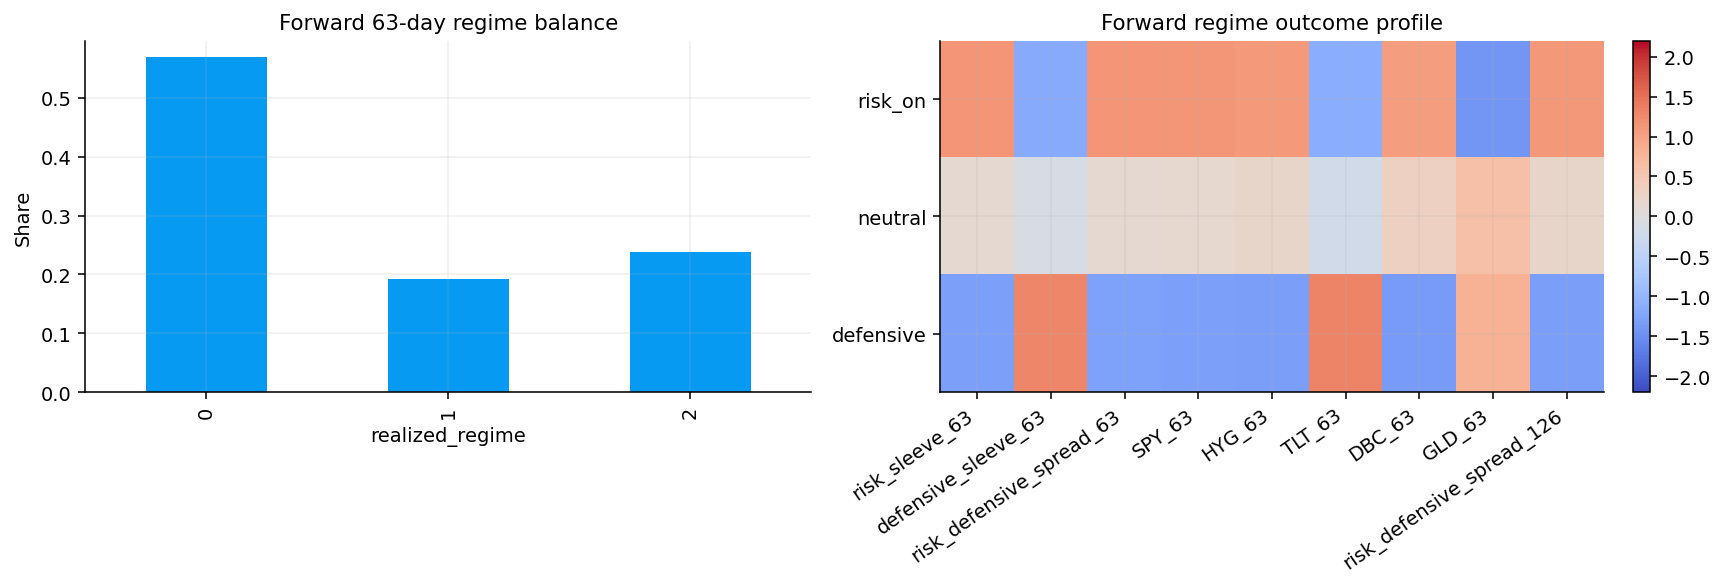

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))
y.value_counts(normalize=True).sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Forward 63-day regime balance")
axes[0].set_ylabel("Share")
profile_cols = [
    c for c in [
        "outcome_risk_sleeve_63",
        "outcome_defensive_sleeve_63",
        "outcome_risk_defensive_spread_63",
        "outcome_SPY_63",
        "outcome_HYG_63",
        "outcome_TLT_63",
        "outcome_DBC_63",
        "outcome_GLD_63",
        "outcome_risk_defensive_spread_126",
    ]
    if c in future_profile.columns
]
profile_z = future_profile[profile_cols]
profile_z = (profile_z - profile_z.mean()) / profile_z.std(ddof=0).replace(0, np.nan)
im = axes[1].imshow(profile_z.fillna(0.0).values, aspect="auto", cmap="coolwarm", vmin=-2.2, vmax=2.2)
axes[1].set_yticks(range(len(profile_z.index)))
axes[1].set_yticklabels(profile_z.index)
axes[1].set_xticks(range(len(profile_z.columns)))
axes[1].set_xticklabels([c.replace("outcome_", "") for c in profile_z.columns], rotation=35, ha="right")
axes[1].set_title("Forward regime outcome profile")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [25]:
feature_train_end = pd.Timestamp("2018-12-31")
train_mask = x_model.index <= feature_train_end
test_mask = x_model.index > feature_train_end

rf_selector = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=20,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=1,
)
rf_selector.fit(x_model.loc[train_mask], y.loc[train_mask])
perm = permutation_importance(
    rf_selector,
    x_model.loc[train_mask],
    y.loc[train_mask],
    n_repeats=8,
    random_state=42,
    scoring="balanced_accuracy",
    n_jobs=1,
)
importance = pd.DataFrame(
    {
        "feature": x_model.columns,
        "importance": rf_selector.feature_importances_,
        "permutation_importance": perm.importances_mean,
        "permutation_std": perm.importances_std,
    }
).sort_values(["permutation_importance", "importance"], ascending=False)
target_features = [
    "risk_on_63",
    "risk_on_126",
    "hyg_lqd_126",
    "hyg_lqd_change_63",
    "credit_equity_divergence_63",
    "duration_equity_divergence_126",
    "inflation_equity_126",
    "breadth_speed_63",
    "dd_level",
    "vol_change_63",
    "corr_shock",
    "slope_10y_3m",
    "fci_change_3m",
    "goldilocks_support",
]
target_features = [f for f in target_features if f in x_model.columns]
selected_features = list(dict.fromkeys(target_features + importance.head(18)["feature"].tolist()))[:16]
display(importance.head(18).round(4))
display(pd.DataFrame({"selected_features": selected_features}))

,feature,importance,permutation_importance,permutation_std
70,dd_level,0.0167,0.0066,0.0024
69,vol_change_63,0.0169,0.0055,0.0010
4,efa_spy_126,0.0229,0.0046,0.0022
41,slope_10y_3m,0.0174,0.0042,0.0017
72,corr_level,0.0290,0.0038,0.0007
1,spy_126,0.0121,0.0038,0.0005
59,goldilocks_support,0.0351,0.0033,0.0013
40,rate_10y,0.0331,0.0032,0.0010
73,corr_shock,0.0139,0.0028,0.0011
17,lqd_ief_126,0.0166,0.0028,0.0013


,selected_features
0,risk_on_63
1,risk_on_126
2,hyg_lqd_126
3,hyg_lqd_change_63
4,credit_equity_divergence_63
5,duration_equity_divergence_126
6,inflation_equity_126
7,breadth_speed_63
8,dd_level
9,vol_change_63


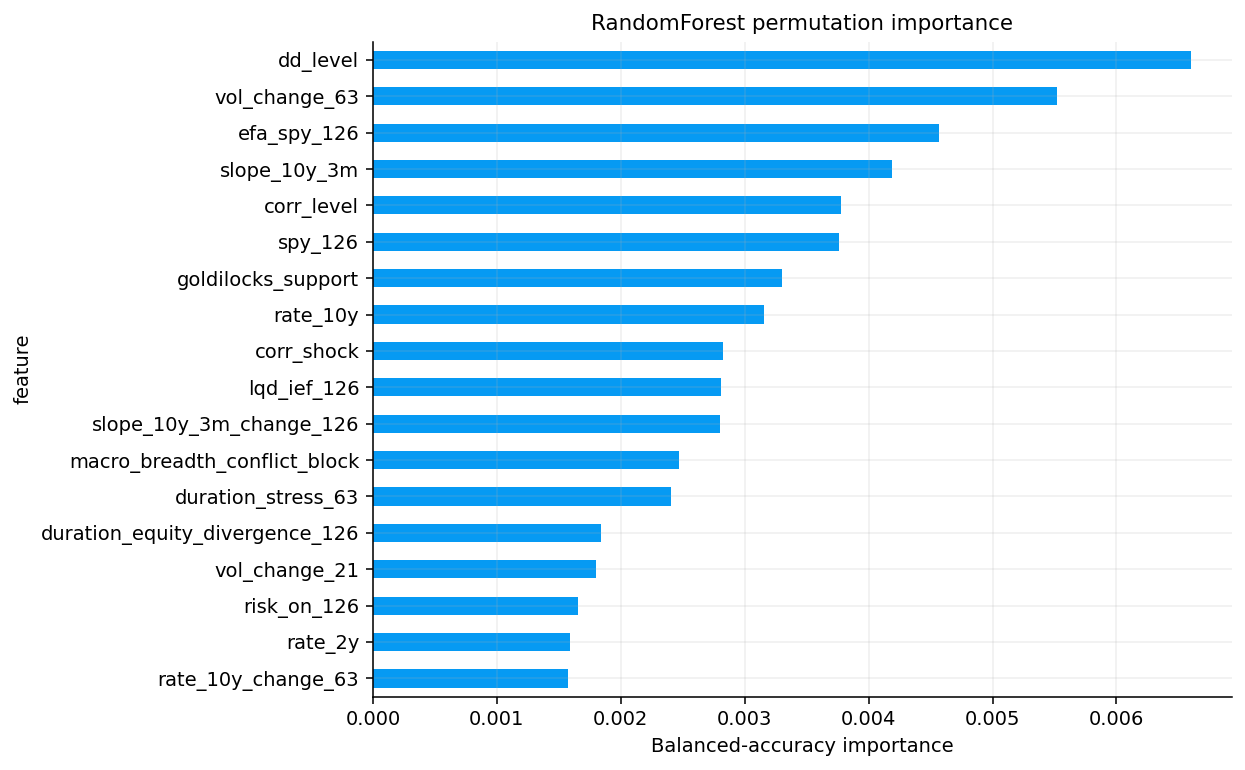

In [26]:
fig, ax = plt.subplots(figsize=(9.0, 5.6))
importance.head(18).sort_values("permutation_importance").plot(
    x="feature",
    y="permutation_importance",
    kind="barh",
    ax=ax,
    legend=False,
)
ax.set_title("RandomForest permutation importance")
ax.set_xlabel("Balanced-accuracy importance")
plt.tight_layout()
plt.show()

In [27]:
def selected_feature_transform(x, min_history=252, clip=4.0):
    base = x.replace([np.inf, -np.inf], np.nan).astype(float)
    mean = base.expanding(min_periods=int(min_history)).mean().shift(1)
    std = base.expanding(min_periods=int(min_history)).std(ddof=1).shift(1).replace(0.0, np.nan)
    transformed = ((base - mean) / std).clip(-float(clip), float(clip))
    return transformed

x_raw_unscaled = x_model[selected_features].copy()
x_raw = selected_feature_transform(x_raw_unscaled).dropna(how="any")
common_selected = x_raw.index.intersection(y.index)
x_raw = x_raw.loc[common_selected]
y = y.loc[common_selected].astype(int)
y_slow = y_slow.loc[common_selected].astype(int)
stress_label = stress_label.loc[common_selected].astype(int)
future_for_quality = future_for_quality.loc[common_selected]
train_mask = x_raw.index <= feature_train_end
test_mask = x_raw.index > feature_train_end
scaler = StandardScaler()
z = pd.DataFrame(scaler.fit_transform(x_raw), index=x_raw.index, columns=x_raw.columns)
vif_selected = feature_vif_local(x_raw)
pca_explained, pca_loadings = pca_tables_local(x_raw, n_components=min(8, x_raw.shape[1]))
display(vif_selected.round(2))
display(pca_explained.round(4))

,r2,vif
feature,,
risk_on_126,0.95,18.64
duration_equity_divergence_126,0.94,15.80
risk_on_63,0.91,10.80
credit_equity_divergence_63,0.87,7.96
hyg_lqd_126,0.83,5.93
dd_level,0.67,3.07
hyg_lqd_change_63,0.59,2.42
breadth_speed_63,0.56,2.27
goldilocks_support,0.54,2.19


,explained_variance,explained_variance_ratio,cumulative
PC1,5.1920,0.3244,0.3244
PC2,2.1108,0.1319,0.4563
PC3,1.7382,0.1086,0.5649
PC4,1.3996,0.0875,0.6524
PC5,1.0564,0.0660,0.7184
PC6,0.9775,0.0611,0.7795
PC7,0.7722,0.0483,0.8277
PC8,0.7170,0.0448,0.8725


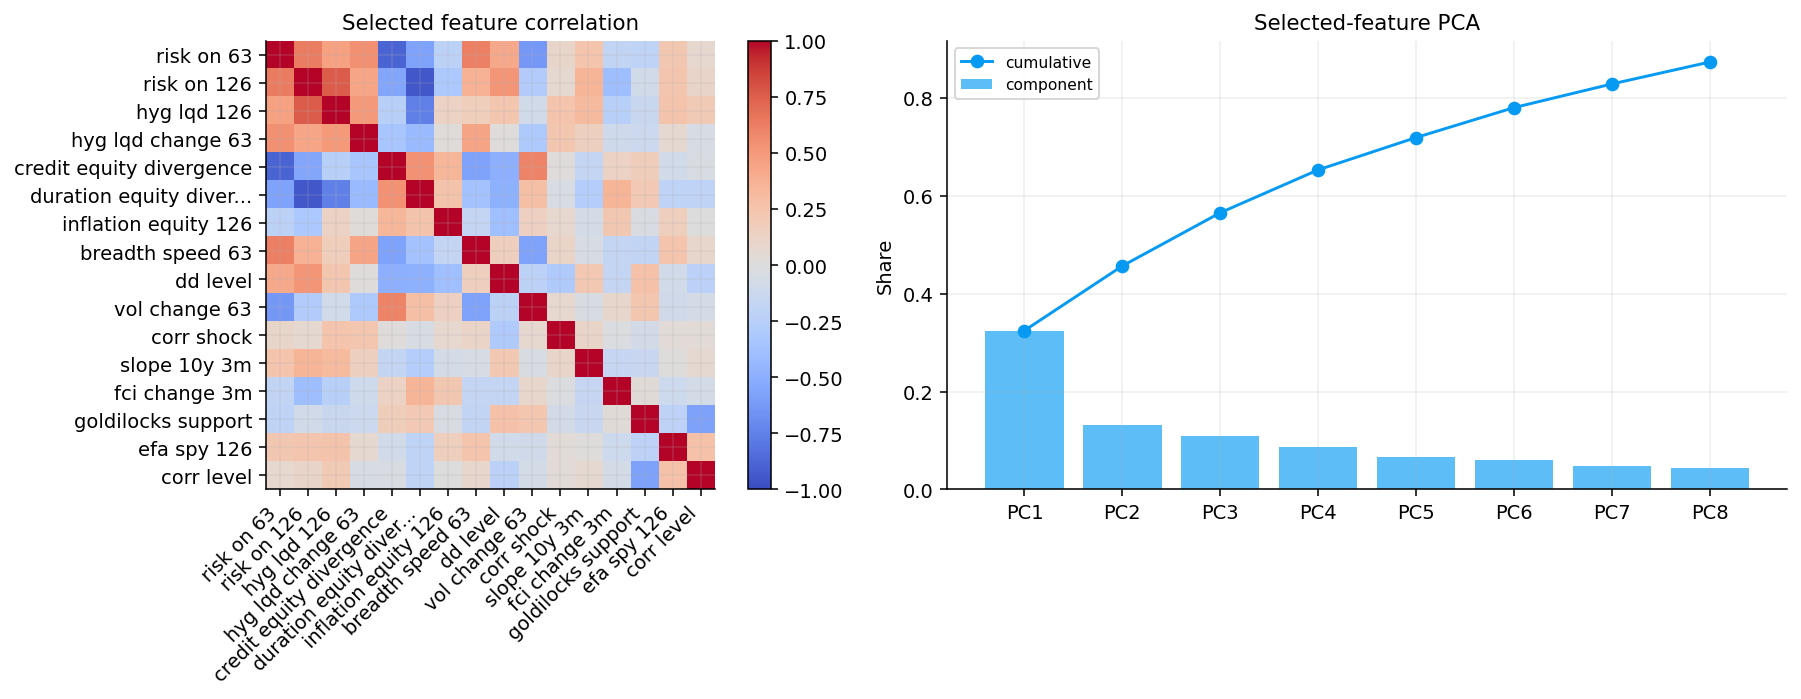

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.1))
plot_corr_heatmap(axes[0], x_raw.corr(), title="Selected feature correlation", annotate=False)
axes[1].plot(pca_explained.index, pca_explained["cumulative"], marker="o", label="cumulative")
axes[1].bar(pca_explained.index, pca_explained["explained_variance_ratio"], alpha=0.65, label="component")
axes[1].set_title("Selected-feature PCA")
axes[1].set_ylabel("Share")
axes[1].legend()
plt.tight_layout()
plt.show()

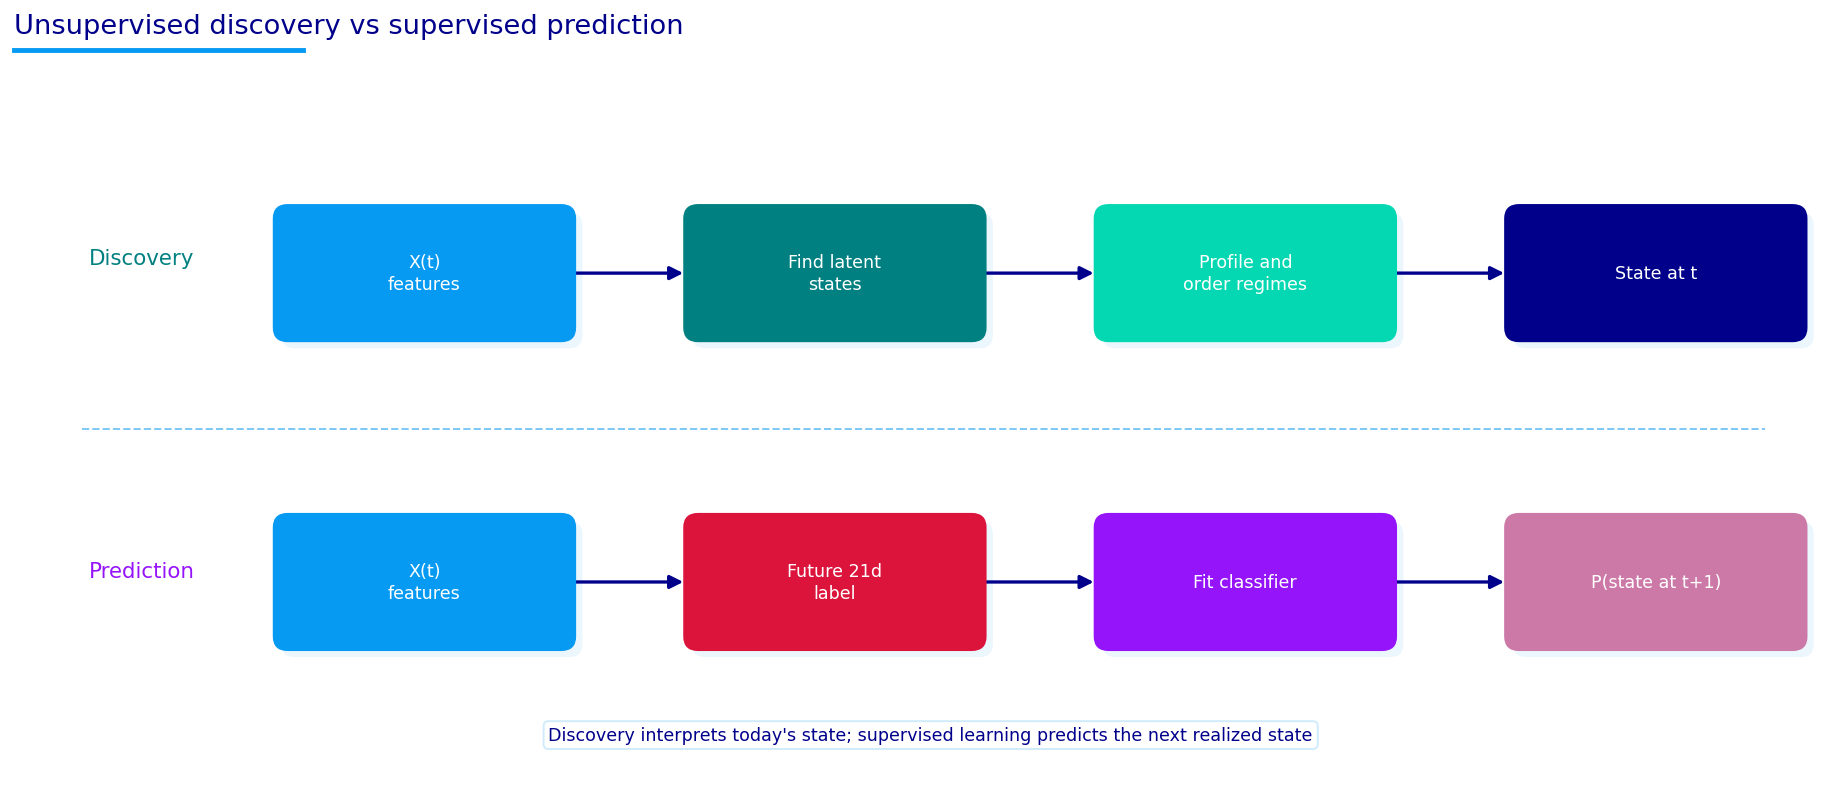

In [29]:
fig, ax = unsupervised_supervised()
plt.show()

In [30]:
def state_durations(labels):
    s = pd.Series(labels).dropna().astype(int)
    if s.empty:
        return []
    groups = (s != s.shift()).cumsum()
    return s.groupby(groups).size().astype(int).tolist()

def quality_row_local(name, labels, x=None, proba=None, outcomes=None, loglike=np.nan, aic=np.nan, bic=np.nan):
    lab = pd.Series(labels).dropna().astype(int)
    row = {
        "model": name,
        "states": lab.nunique(),
        "loglike": loglike,
        "aic": aic,
        "bic": bic,
        "silhouette": np.nan,
        "min_state_share": lab.value_counts(normalize=True).min() if len(lab) else np.nan,
        "avg_state_duration": np.mean(state_durations(lab)) if len(lab) else np.nan,
        "transitions_per_year": np.nan,
        "posterior_confidence": np.nan,
        "economic_separation": np.nan,
    }
    if isinstance(lab.index, pd.DatetimeIndex) and len(lab) > 1:
        years = max((lab.index[-1] - lab.index[0]).days / 365.25, 1.0 / annualization)
        row["transitions_per_year"] = ((lab != lab.shift()).sum() - 1) / years
    elif len(lab) > 1:
        row["transitions_per_year"] = ((lab != lab.shift()).sum() - 1) / (len(lab) / annualization)
    if x is not None and lab.nunique() > 1:
        try:
            Xq = x.loc[lab.index].to_numpy(dtype=float) if isinstance(x, pd.DataFrame) else np.asarray(x, dtype=float)
            row["silhouette"] = silhouette_score(Xq, lab.to_numpy(dtype=int))
        except Exception:
            pass
    if proba is not None:
        P = proba.loc[lab.index] if isinstance(proba, pd.DataFrame) else pd.DataFrame(proba, index=lab.index)
        row["posterior_confidence"] = P.max(axis=1).mean()
    if outcomes is not None and lab.nunique() > 1:
        out = outcomes.reindex(lab.index)
        joined = pd.concat([out, lab.rename("state")], axis=1).dropna()
        if not joined.empty:
            by_state = joined.groupby("state")[out.columns].mean()
            denom = joined[out.columns].std(ddof=1).replace(0.0, np.nan)
            row["economic_separation"] = (by_state.max() - by_state.min()).div(denom).mean()
    return row

eco_rows = []
eco_outputs = {}

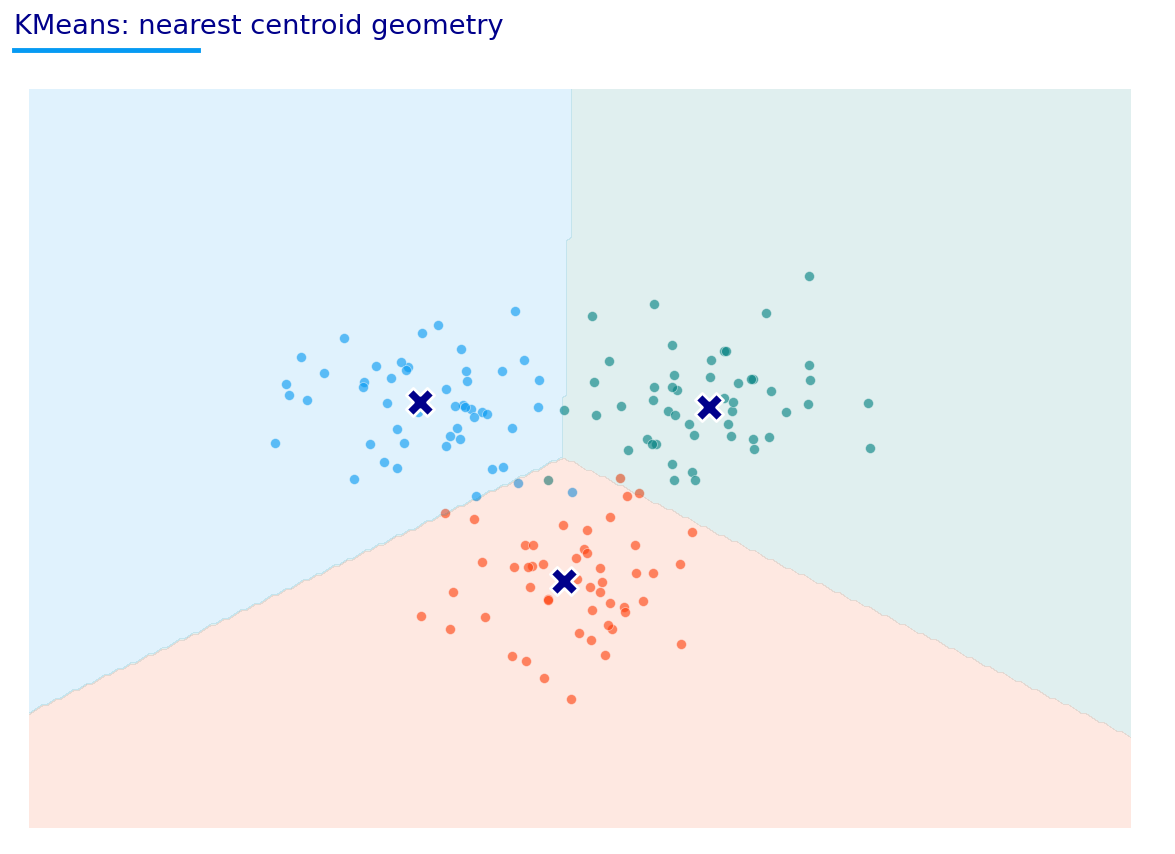

In [31]:
fig, ax = kmeans_geometry()
plt.show()

In [32]:
kmeans3 = KMeans(n_clusters=3, n_init=50, random_state=42)
lab = pd.Series(kmeans3.fit_predict(z), index=z.index, name="state")
order = sort_profile_states(state_profile_local(x_raw, lab, future_for_quality))
lab = remap_series(lab, order).set_axis(z.index)
eco_outputs["KMeans 3"] = {"labels": lab, "proba": pd.get_dummies(lab).reindex(columns=range(3), fill_value=0.0)}
eco_rows.append(quality_row_local("KMeans 3", lab, x=z, outcomes=future_for_quality))

kmeans4 = KMeans(n_clusters=4, n_init=50, random_state=42)
lab = pd.Series(kmeans4.fit_predict(z), index=z.index, name="state")
order = sort_profile_states(state_profile_local(x_raw, lab, future_for_quality))
lab = remap_series(lab, order).set_axis(z.index)
eco_outputs["KMeans 4"] = {"labels": lab, "proba": pd.get_dummies(lab).reindex(columns=range(4), fill_value=0.0)}
eco_rows.append(quality_row_local("KMeans 4", lab, x=z, outcomes=future_for_quality))

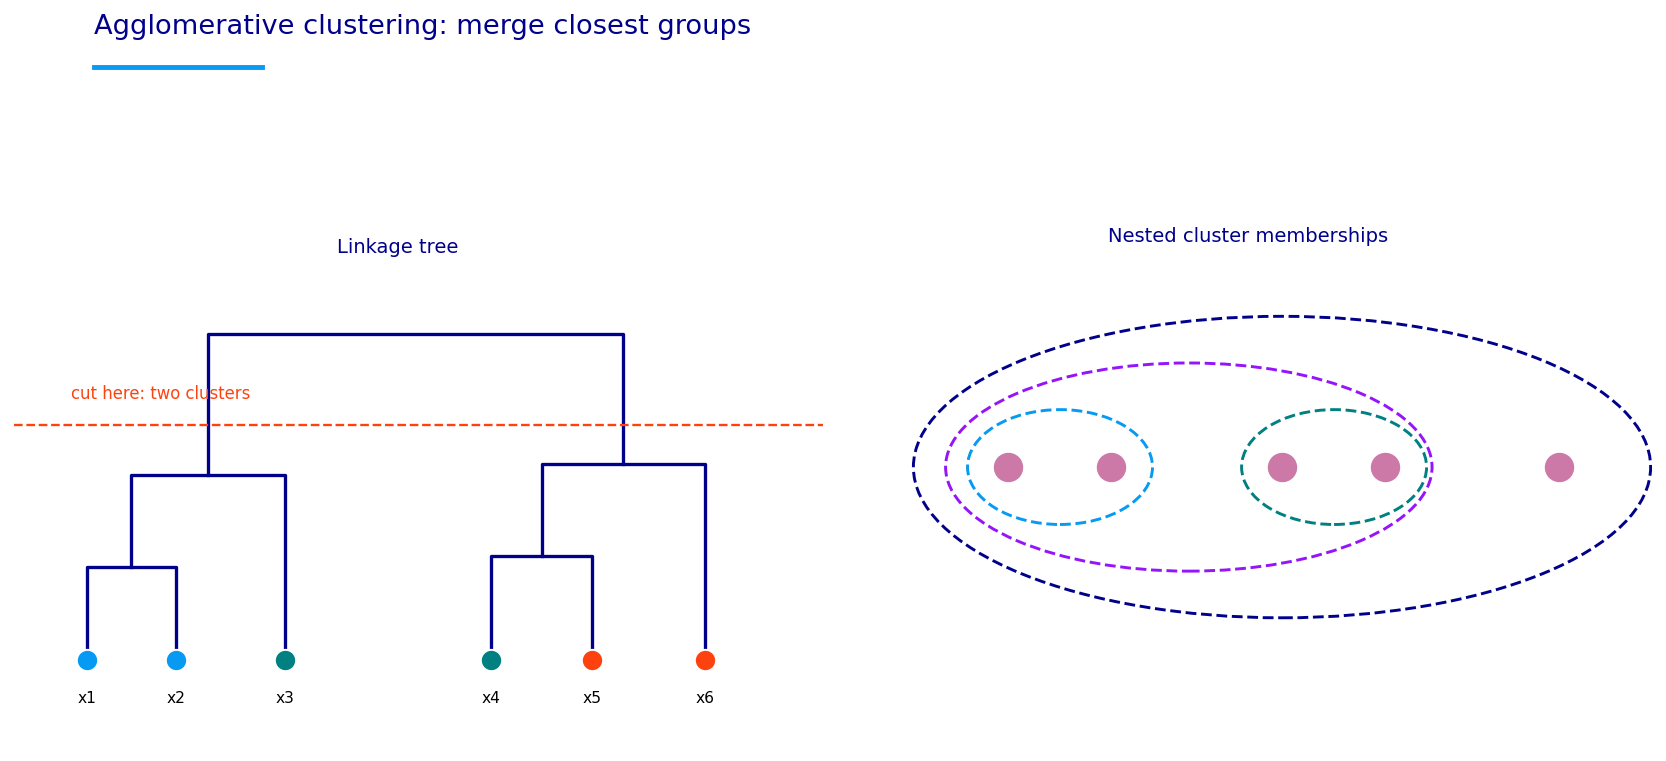

In [33]:
fig, axes = agglomerative_tree()
plt.show()

In [34]:
agg3 = AgglomerativeClustering(n_clusters=3, linkage="ward")
lab = pd.Series(agg3.fit_predict(z), index=z.index, name="state")
order = sort_profile_states(state_profile_local(x_raw, lab, future_for_quality))
lab = remap_series(lab, order).set_axis(z.index)
eco_outputs["Agglomerative 3"] = {"labels": lab, "proba": pd.get_dummies(lab).reindex(columns=range(3), fill_value=0.0)}
eco_rows.append(quality_row_local("Agglomerative 3", lab, x=z, outcomes=future_for_quality))

agg4 = AgglomerativeClustering(n_clusters=4, linkage="ward")
lab = pd.Series(agg4.fit_predict(z), index=z.index, name="state")
order = sort_profile_states(state_profile_local(x_raw, lab, future_for_quality))
lab = remap_series(lab, order).set_axis(z.index)
eco_outputs["Agglomerative 4"] = {"labels": lab, "proba": pd.get_dummies(lab).reindex(columns=range(4), fill_value=0.0)}
eco_rows.append(quality_row_local("Agglomerative 4", lab, x=z, outcomes=future_for_quality))

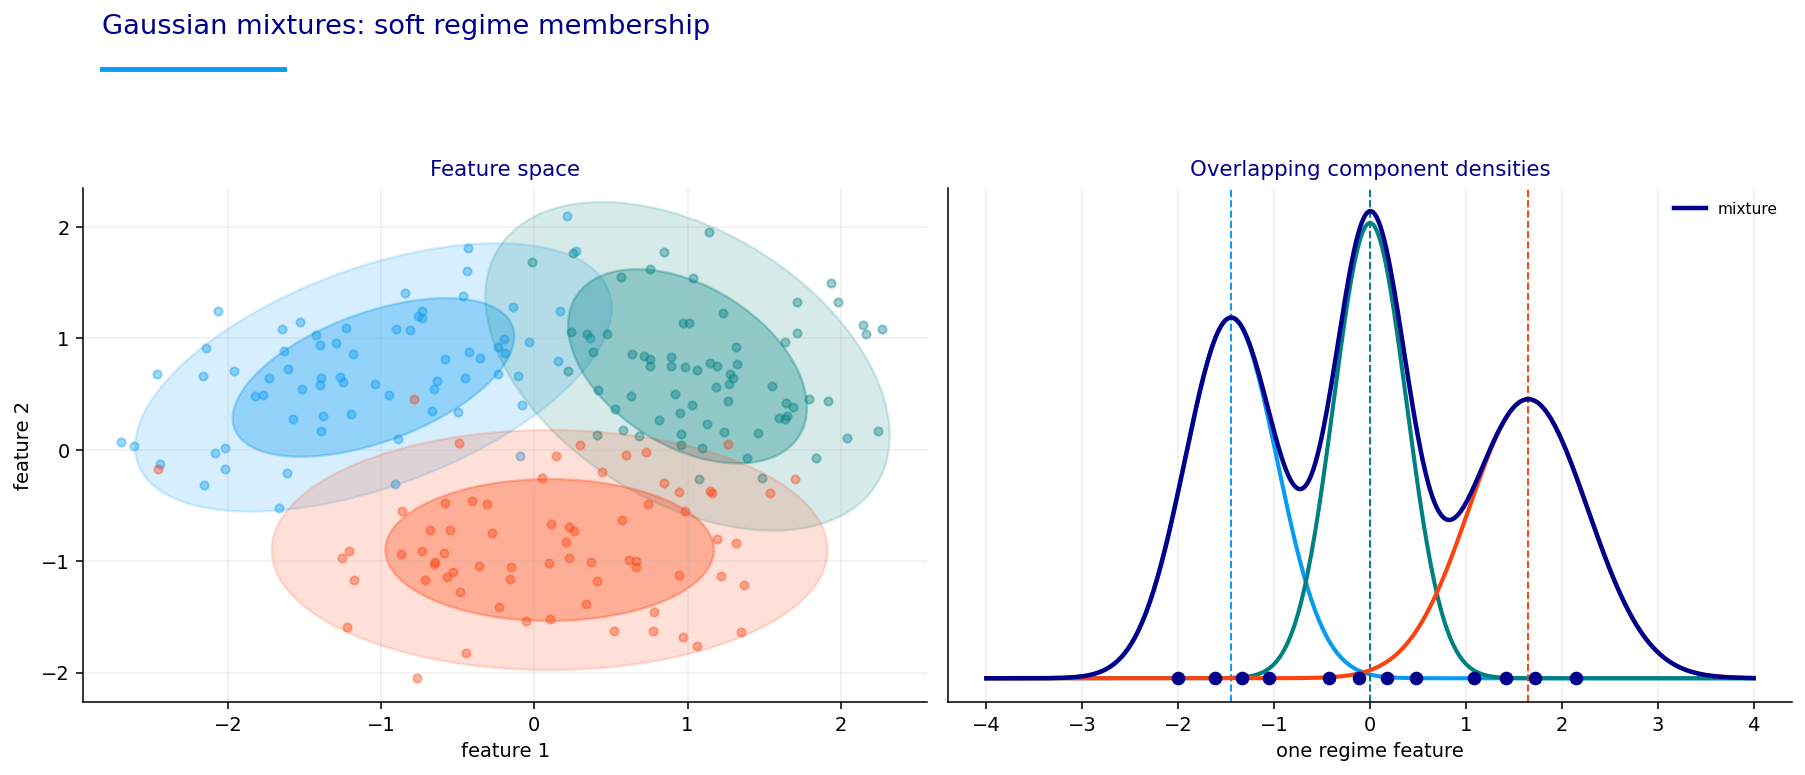

In [35]:
fig, axes = gmm_mixture()
plt.show()

In [36]:
gmm3 = GaussianMixture(n_components=3, covariance_type="diag", n_init=10, random_state=42, reg_covar=1e-5)
lab = pd.Series(gmm3.fit_predict(z), index=z.index, name="state")
proba = pd.DataFrame(gmm3.predict_proba(z), index=z.index)
order = sort_profile_states(state_profile_local(x_raw, lab, future_for_quality))
lab = remap_series(lab, order).set_axis(z.index)
proba = proba[order].set_axis(range(3), axis=1)
eco_outputs["GMM 3 diag"] = {"labels": lab, "proba": proba}
eco_rows.append(quality_row_local("GMM 3 diag", lab, x=z, proba=proba, outcomes=future_for_quality, loglike=gmm3.score(z) * len(z), aic=gmm3.aic(z), bic=gmm3.bic(z)))

gmm4 = GaussianMixture(n_components=4, covariance_type="diag", n_init=10, random_state=42, reg_covar=1e-5)
lab = pd.Series(gmm4.fit_predict(z), index=z.index, name="state")
proba = pd.DataFrame(gmm4.predict_proba(z), index=z.index)
order = sort_profile_states(state_profile_local(x_raw, lab, future_for_quality))
lab = remap_series(lab, order).set_axis(z.index)
proba = proba[order].set_axis(range(4), axis=1)
eco_outputs["GMM 4 diag"] = {"labels": lab, "proba": proba}
eco_rows.append(quality_row_local("GMM 4 diag", lab, x=z, proba=proba, outcomes=future_for_quality, loglike=gmm4.score(z) * len(z), aic=gmm4.aic(z), bic=gmm4.bic(z)))

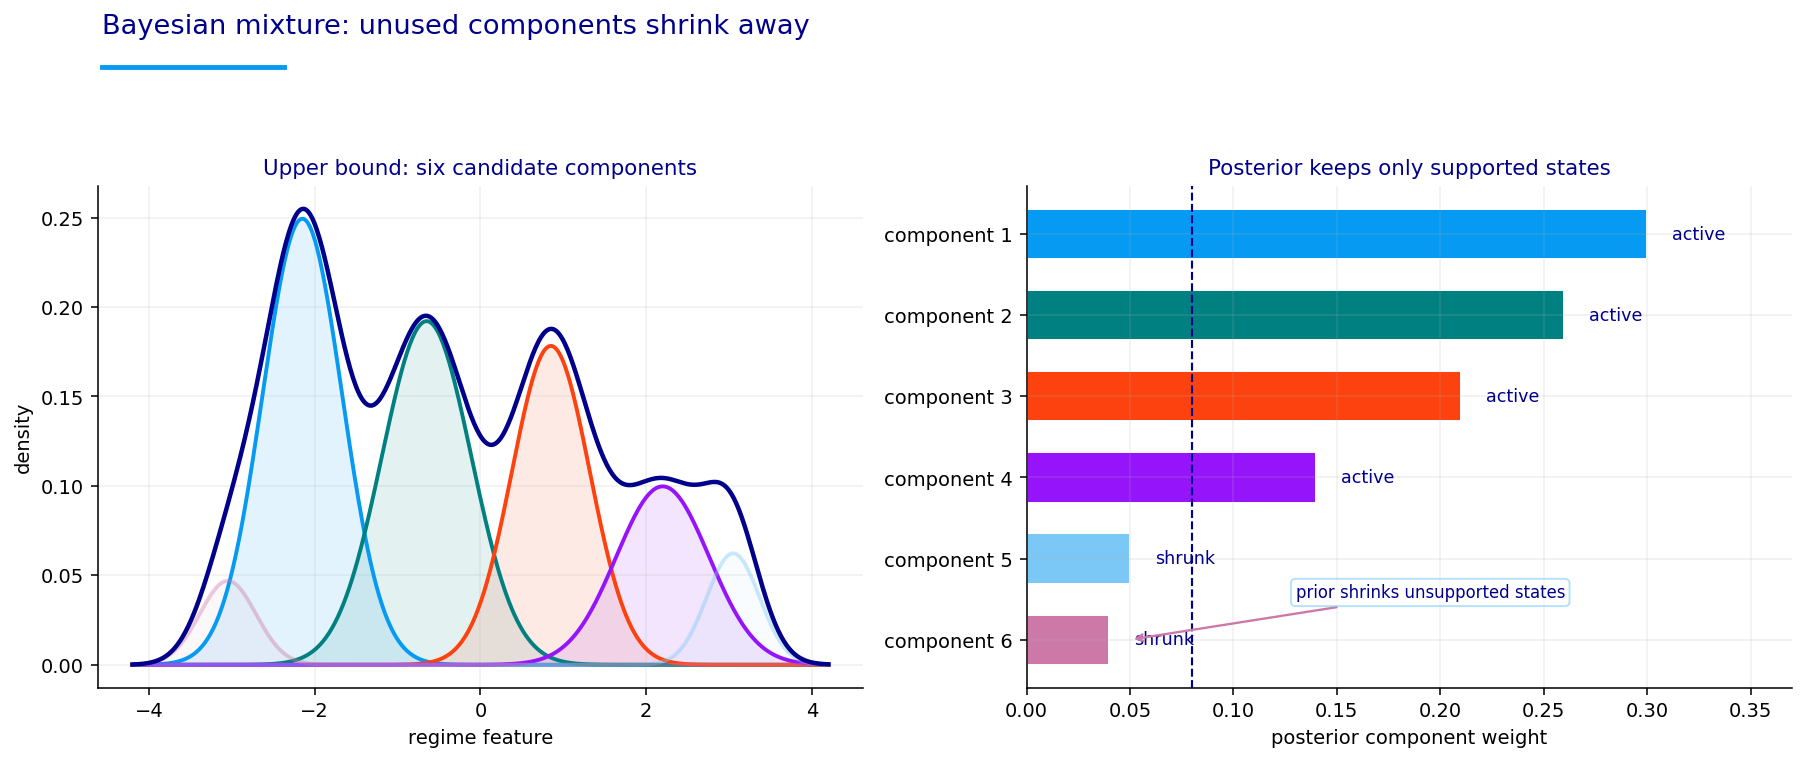

In [37]:
fig, ax = bayesian_mixture()
plt.show()

In [38]:
bgmm = BayesianGaussianMixture(
    n_components=6,
    covariance_type="diag",
    random_state=42,
    max_iter=500,
    weight_concentration_prior_type="dirichlet_process",
    weight_concentration_prior=0.25,
)
lab = pd.Series(bgmm.fit_predict(z), index=z.index, name="state")
active_states = sorted(lab.value_counts().loc[lambda s: s > 20].index.tolist())
lab = lab.where(lab.isin(active_states), lab.mode().iloc[0])
proba = pd.DataFrame(bgmm.predict_proba(z), index=z.index).reindex(columns=active_states, fill_value=0.0)
order = sort_profile_states(state_profile_local(x_raw, lab, future_for_quality))
lab = remap_series(lab, order).set_axis(z.index)
proba = proba[order].set_axis(range(len(order)), axis=1)
eco_outputs["Bayesian GMM"] = {"labels": lab, "proba": proba}
eco_rows.append(quality_row_local("Bayesian GMM", lab, x=z, proba=proba, outcomes=future_for_quality, loglike=bgmm.score(z) * len(z)))
display(pd.Series(bgmm.weights_, name="component_weight").round(4))

0    0.2083
1    0.1436
2    0.0471
3    0.1741
4    0.0311
5    0.3958
Name: component_weight, dtype: float64

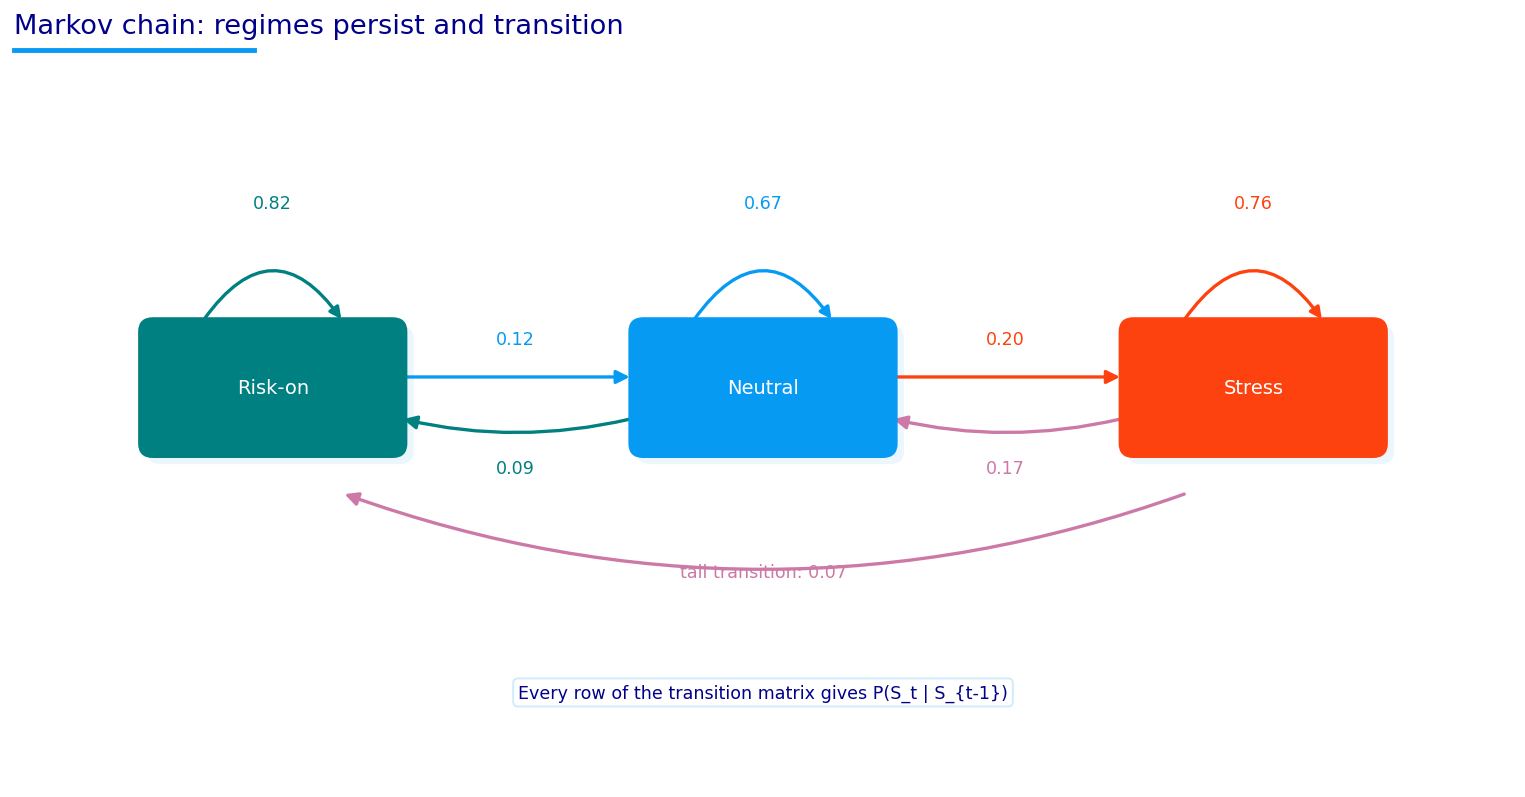

In [39]:
fig, ax = markov_chain()
plt.show()

In [40]:
global_ew_ret = returns[assets].mean(axis=1).reindex(z.index).dropna() * 100.0
try:
    mr3 = MarkovRegression(global_ew_ret, k_regimes=3, trend="c", switching_variance=True)
    mr3_res = mr3.fit(search_reps=12, em_iter=8, maxiter=120, disp=False)
    p = mr3_res.smoothed_marginal_probabilities
    proba = pd.DataFrame(np.asarray(p), index=global_ew_ret.index)
    lab = proba.idxmax(axis=1).astype(int)
    order = sort_profile_states(state_profile_local(x_raw.reindex(lab.index), lab, future_for_quality.reindex(lab.index)))
    lab = remap_series(lab, order).set_axis(lab.index)
    proba = proba[order].set_axis(range(len(order)), axis=1)
    eco_outputs["MarkovRegression 3"] = {"labels": lab, "proba": proba}
    eco_rows.append(quality_row_local("MarkovRegression 3", lab, x=z.reindex(lab.index), proba=proba, outcomes=future_for_quality, loglike=mr3_res.llf, aic=mr3_res.aic, bic=mr3_res.bic))
except Exception as exc:
    print("MarkovRegression skipped:", exc)

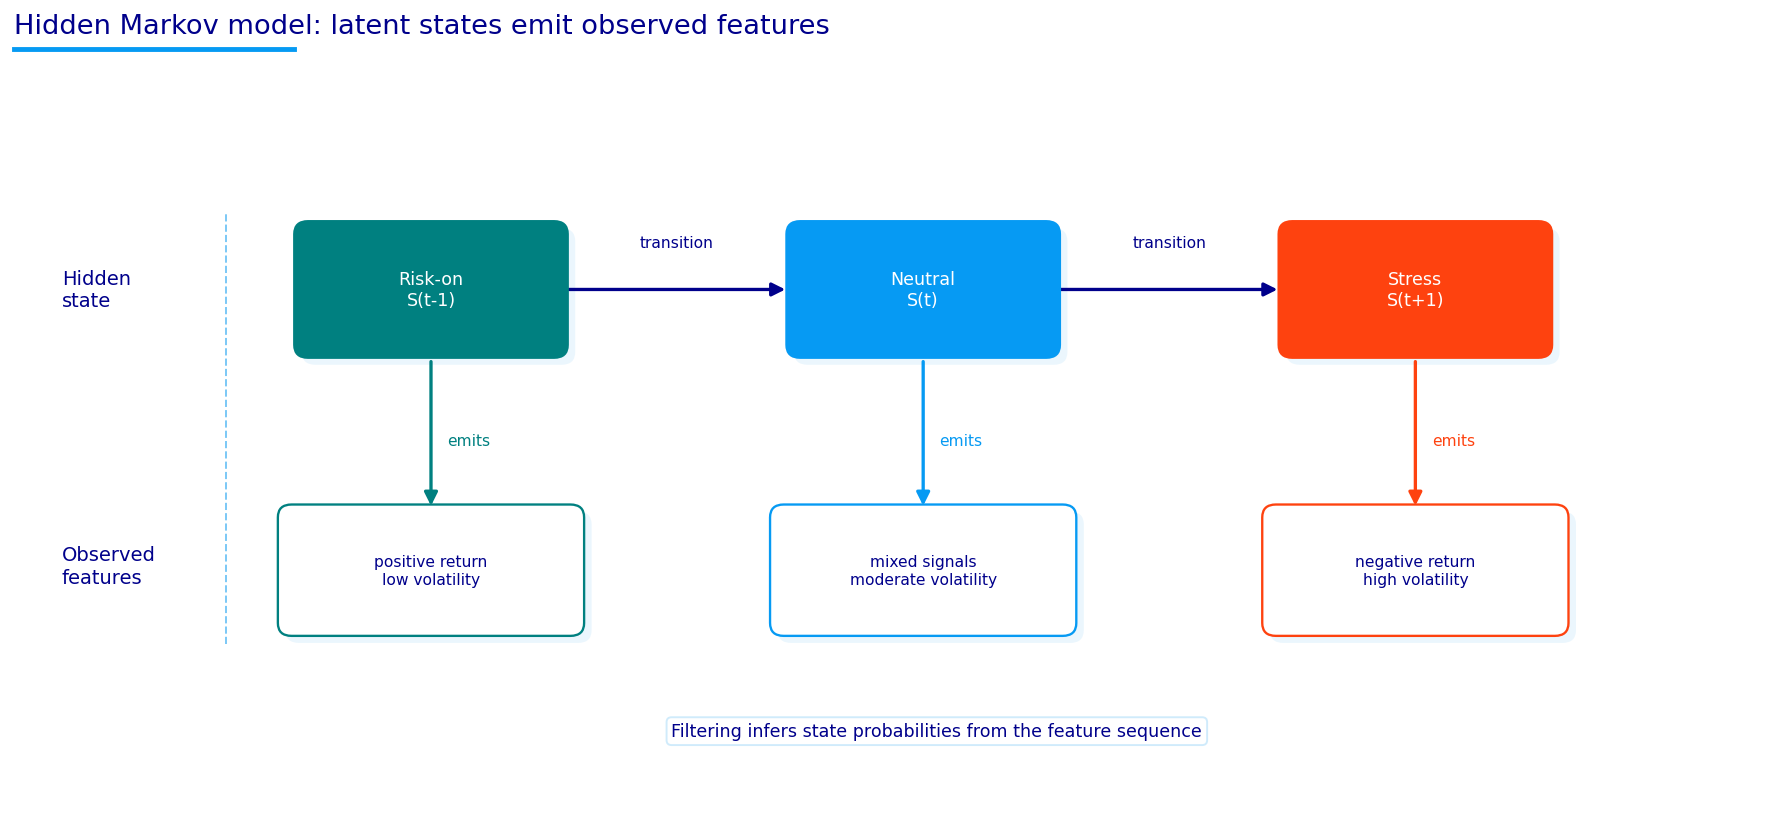

In [41]:
fig, ax = hidden_markov_model()
plt.show()

In [42]:
if hmm_available:
    for n_states in [3, 4]:
        hmm = GaussianHMM(
            n_components=n_states,
            covariance_type="diag",
            n_iter=120,
            random_state=42,
            min_covar=1e-4,
        )
        hmm.fit(z.to_numpy(dtype=float))
        raw = hmm.predict(z.to_numpy(dtype=float))
        proba = pd.DataFrame(hmm.predict_proba(z.to_numpy(dtype=float)), index=z.index)
        lab = pd.Series(raw, index=z.index, name="state")
        order = sort_profile_states(state_profile_local(x_raw, lab, future_for_quality))
        lab = remap_series(lab, order).set_axis(z.index)
        proba = proba[order].set_axis(range(n_states), axis=1)
        ll = hmm.score(z.to_numpy(dtype=float))
        k = (n_states - 1) + n_states * (n_states - 1) + 2 * n_states * z.shape[1]
        eco_outputs[f"HMM {n_states}"] = {"labels": lab, "proba": proba}
        eco_rows.append(quality_row_local(f"HMM {n_states}", lab, x=z, proba=proba, outcomes=future_for_quality, loglike=ll, aic=-2 * ll + 2 * k, bic=-2 * ll + k * np.log(len(z))))
else:
    print("hmmlearn is unavailable")

In [43]:
if hmm_available:
    pca_n = min(5, z.shape[1])
    pca_hmm_scaler = PCA(n_components=pca_n, random_state=42)
    z_pca = pd.DataFrame(pca_hmm_scaler.fit_transform(z), index=z.index, columns=[f"PC{i+1}" for i in range(pca_n)])
    pca_hmm = GaussianHMM(
        n_components=len(regime_names),
        covariance_type="diag",
        n_iter=150,
        random_state=7,
        min_covar=1e-4,
    )
    pca_hmm.fit(z_pca.to_numpy(dtype=float))
    raw = pca_hmm.predict(z_pca.to_numpy(dtype=float))
    proba = pd.DataFrame(pca_hmm.predict_proba(z_pca.to_numpy(dtype=float)), index=z.index)
    lab = pd.Series(raw, index=z.index, name="state")
    order = sort_profile_states(state_profile_local(x_raw, lab, future_for_quality))
    lab = remap_series(lab, order).set_axis(z.index)
    proba = proba[order].set_axis(range(len(regime_names)), axis=1)
    ll = pca_hmm.score(z_pca.to_numpy(dtype=float))
    k = (len(regime_names) - 1) + len(regime_names) * (len(regime_names) - 1) + 2 * len(regime_names) * pca_n
    eco_outputs["PCA-HMM 3"] = {"labels": lab, "proba": proba}
    eco_rows.append(quality_row_local("PCA-HMM 3", lab, x=z_pca, proba=proba, outcomes=future_for_quality, loglike=ll, aic=-2 * ll + 2 * k, bic=-2 * ll + k * np.log(len(z_pca))))

In [44]:
x_train = z.loc[train_mask]
y_train = y.loc[train_mask]
x_test = z.loc[test_mask]
y_test = y.loc[test_mask]
class_labels = sorted(y.unique())

def classifier_score_local(name, model):
    pred = model.predict(x_test)
    row = {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "macro_f1": f1_score(y_test, pred, average="macro"),
        "log_loss": np.nan,
    }
    if hasattr(model, "predict_proba"):
        try:
            row["log_loss"] = log_loss(y_test, model.predict_proba(x_test), labels=class_labels)
        except Exception:
            pass
    return row

ml_models = {}
ml_rows = []

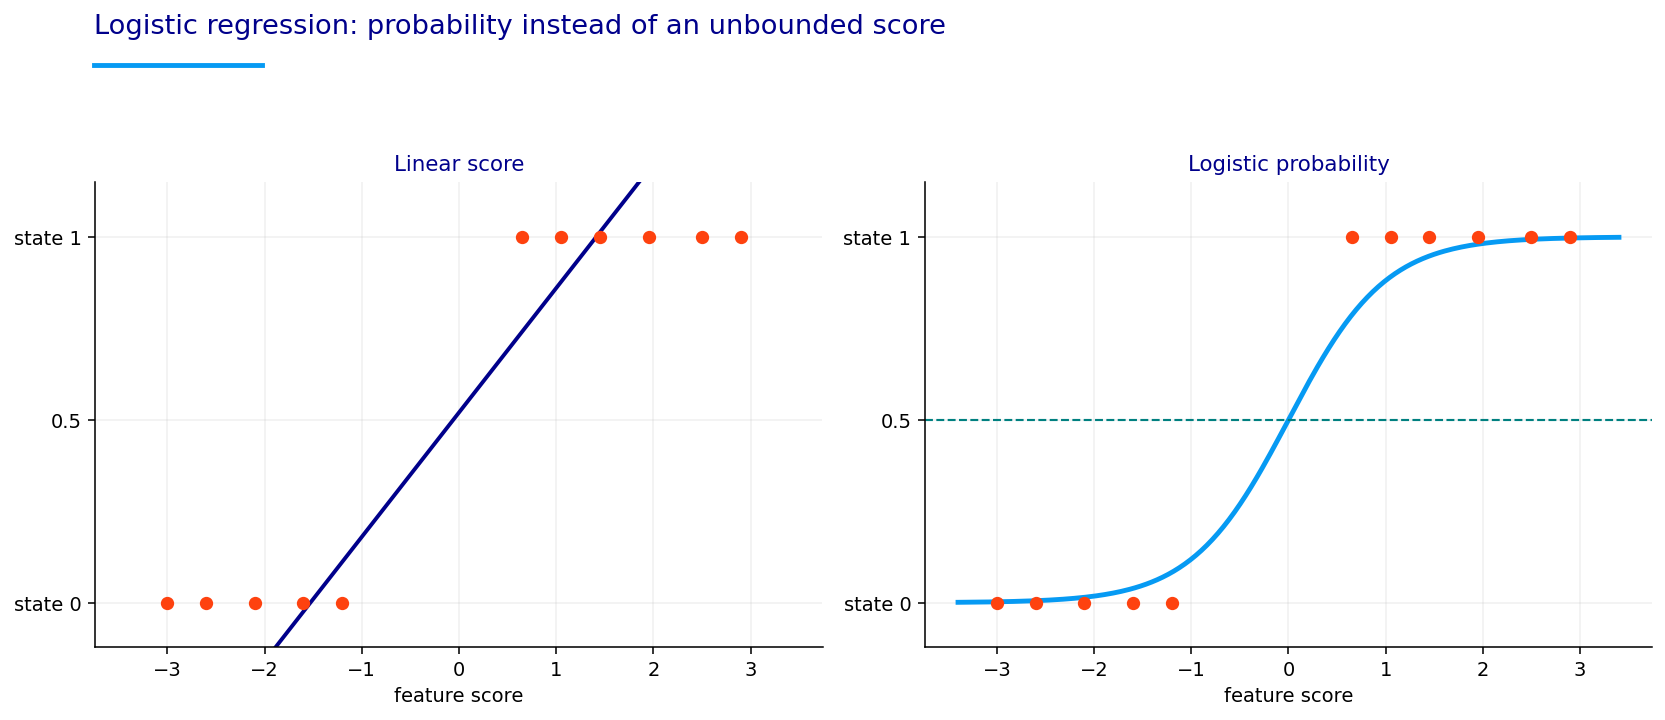

In [45]:
fig, axes = logistic_boundary()
plt.show()

In [46]:
logit = LogisticRegression(max_iter=2500, class_weight="balanced", C=0.75)
logit.fit(x_train, y_train)
ml_models["LogisticRegression"] = logit
ml_rows.append(classifier_score_local("LogisticRegression", logit))

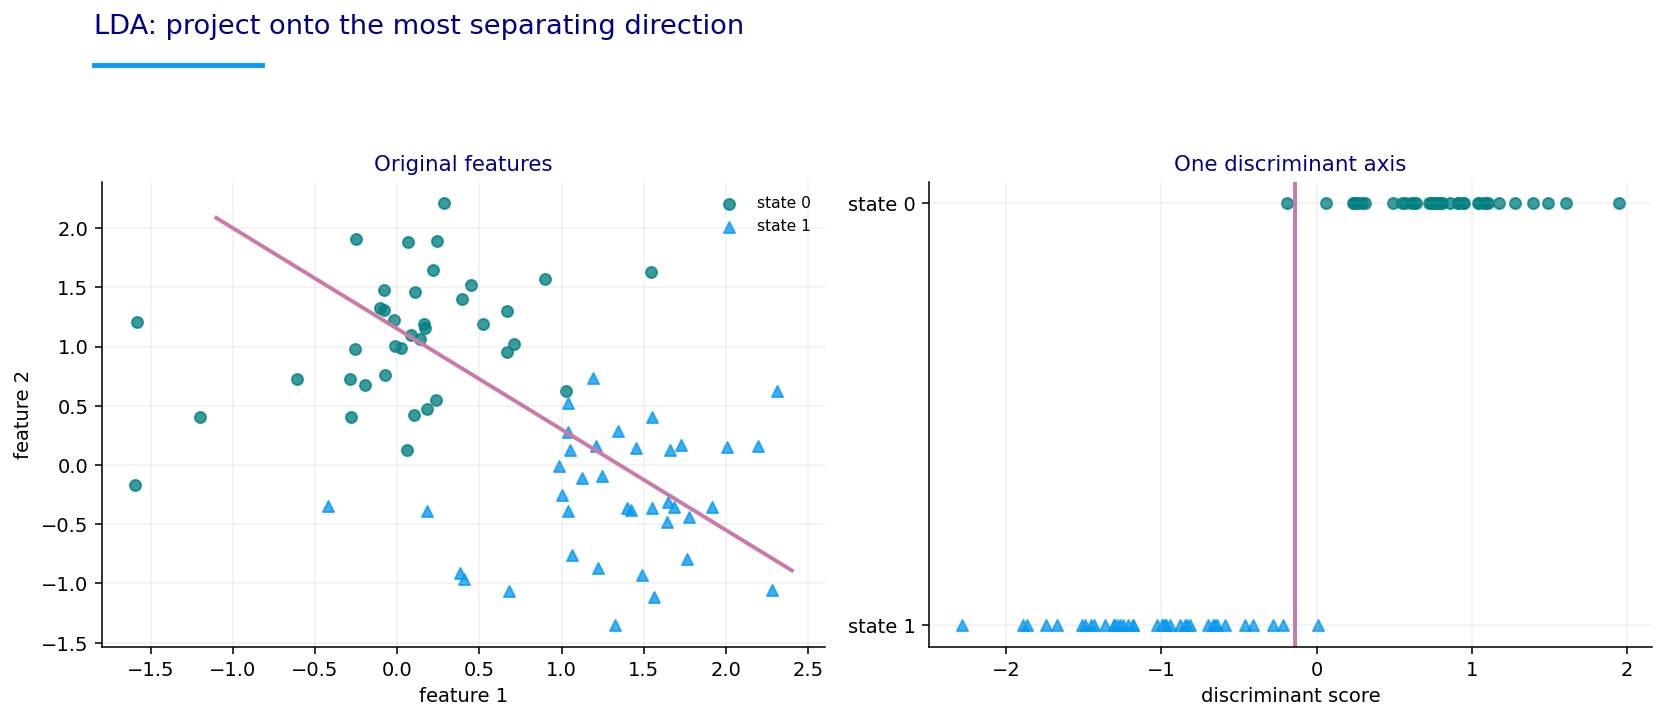

In [47]:
fig, axes = lda_projection()
plt.show()

In [48]:
lda = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
lda.fit(x_train, y_train)
ml_models["LinearDiscriminantAnalysis"] = lda
ml_rows.append(classifier_score_local("LinearDiscriminantAnalysis", lda))

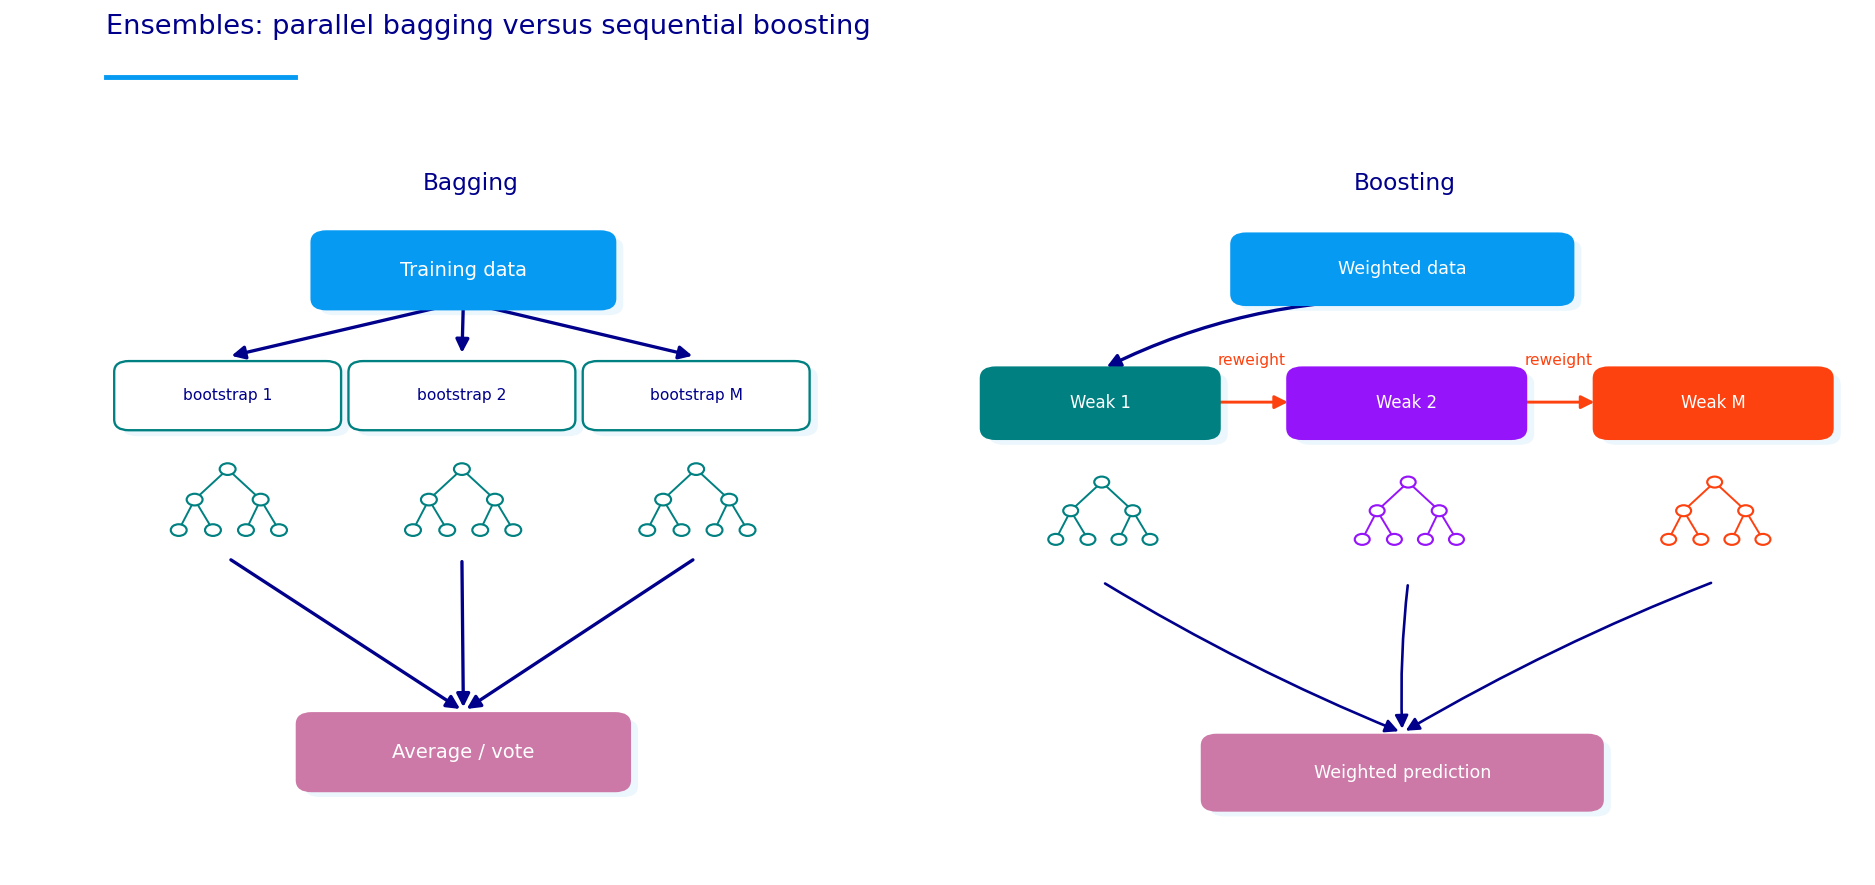

In [49]:
fig, axes = ensemble_bagging()
plt.show()

In [50]:
rf_clf = RandomForestClassifier(
    n_estimators=500,
    min_samples_leaf=20,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=1,
)
rf_clf.fit(x_train, y_train)
ml_models["RandomForestClassifier"] = rf_clf
ml_rows.append(classifier_score_local("RandomForestClassifier", rf_clf))

In [51]:
gb_clf = GradientBoostingClassifier(
    n_estimators=260,
    learning_rate=0.035,
    max_depth=2,
    min_samples_leaf=25,
    random_state=42,
)
gb_clf.fit(x_train, y_train)
ml_models["GradientBoostingClassifier"] = gb_clf
ml_rows.append(classifier_score_local("GradientBoostingClassifier", gb_clf))

In [52]:
if lgbm_available:
    lgbm = LGBMClassifier(
        n_estimators=360,
        learning_rate=0.025,
        num_leaves=15,
        min_child_samples=45,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="multiclass",
        random_state=42,
        verbosity=-1,
        n_jobs=1,
    )
    lgbm.fit(x_train, y_train)
    ml_models["LGBMClassifier"] = lgbm
    ml_rows.append(classifier_score_local("LGBMClassifier", lgbm))
else:
    print("LightGBM unavailable; skipped")

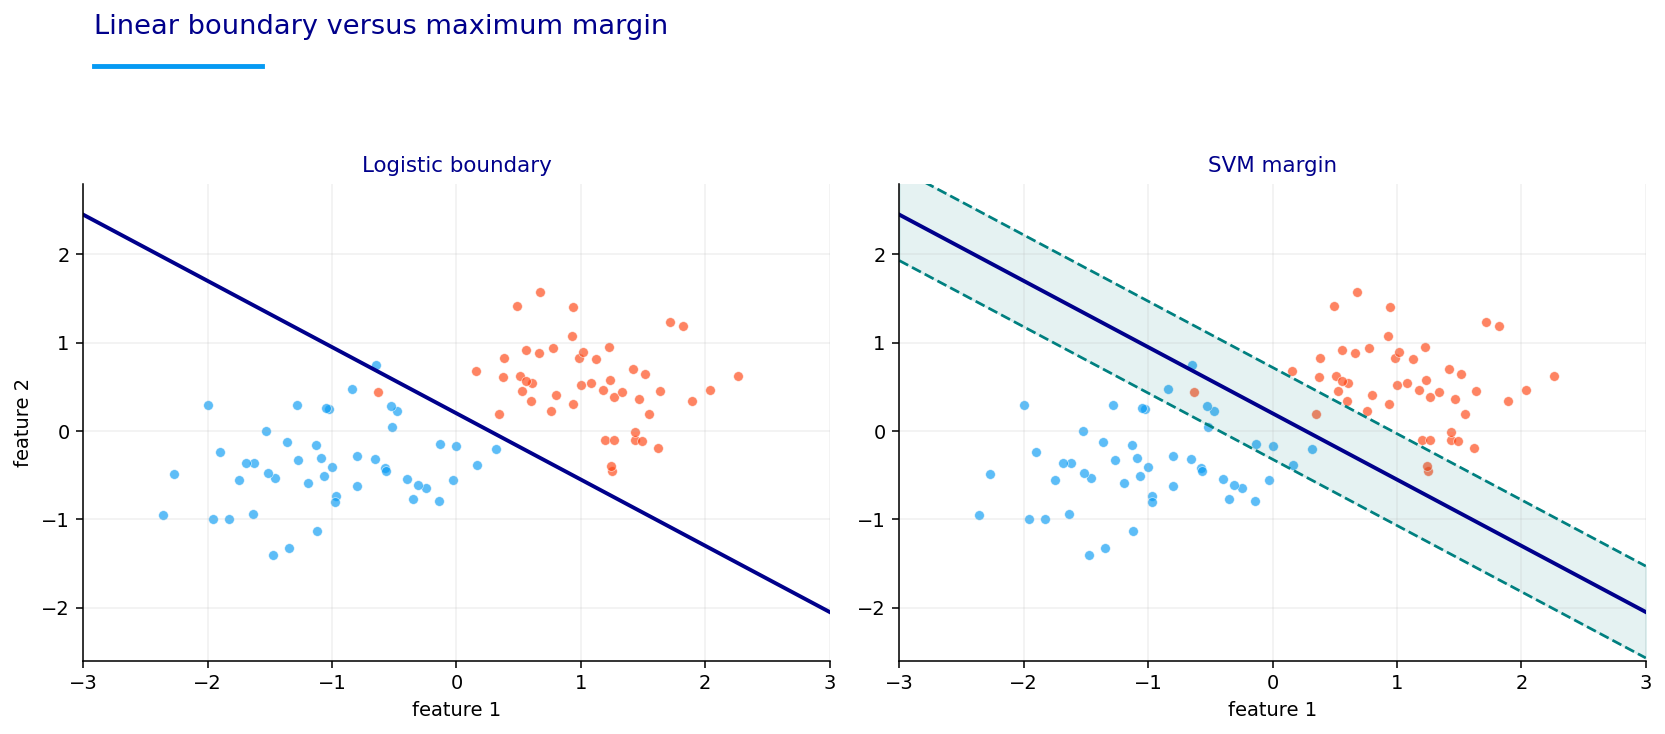

In [53]:
fig, axes = svm_margin()
plt.show()

In [54]:
svm = SVC(C=1.8, gamma="scale", probability=True, class_weight="balanced", random_state=42)
svm.fit(x_train, y_train)
ml_models["SVC"] = svm
ml_rows.append(classifier_score_local("SVC", svm))

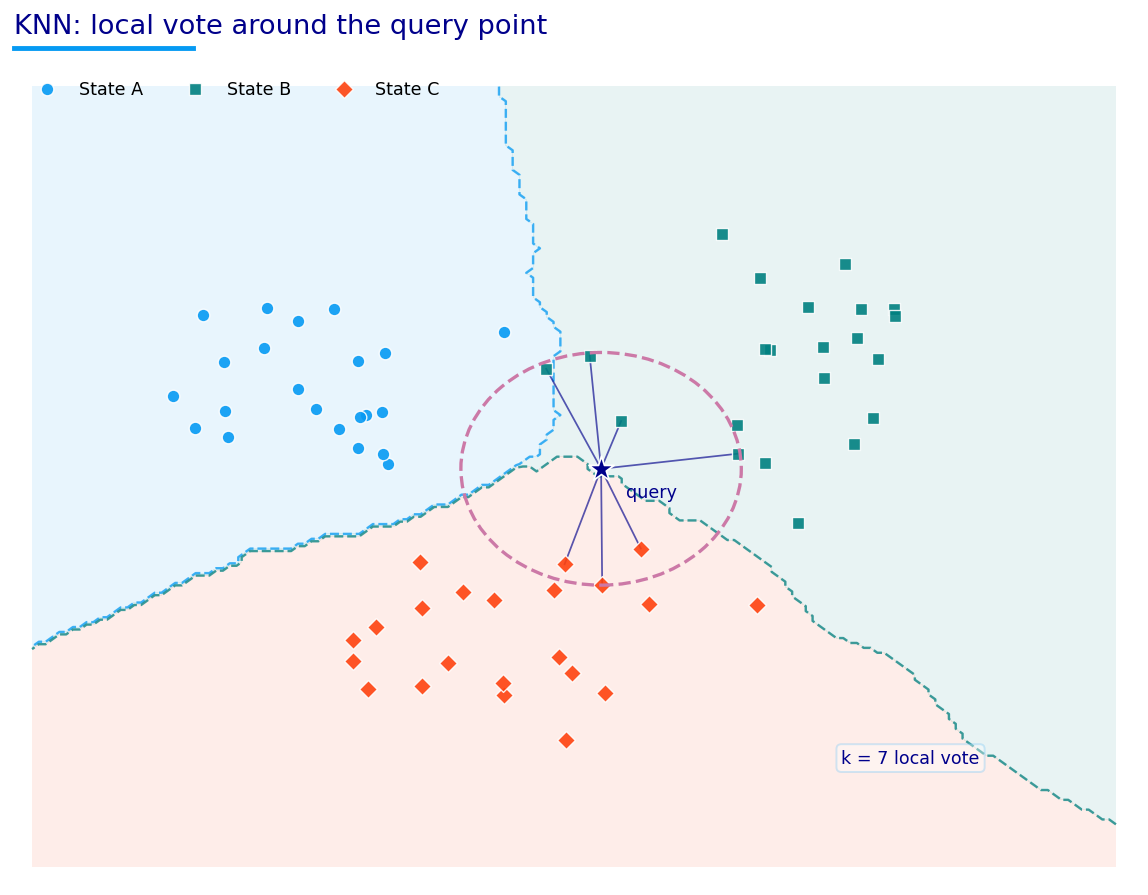

In [55]:
fig, ax = knn_neighbors()
plt.show()

In [56]:
knn = KNeighborsClassifier(n_neighbors=31, weights="distance")
knn.fit(x_train, y_train)
ml_models["KNeighborsClassifier"] = knn
ml_rows.append(classifier_score_local("KNeighborsClassifier", knn))

In [57]:
eco_quality = pd.DataFrame(eco_rows).drop_duplicates("model").set_index("model")
classifier_table = pd.DataFrame(ml_rows).drop_duplicates("model").set_index("model")
display(eco_quality.round(4))
display(classifier_table.sort_values(["balanced_accuracy", "macro_f1", "log_loss"], ascending=[False, False, True]).round(4))

,states,loglike,aic,bic,silhouette,min_state_share,avg_state_duration,transitions_per_year,posterior_confidence,economic_separation
model,,,,,,,,,,
KMeans 3,3,NaN,NaN,NaN,0.1749,0.1861,20.7177,12.3111,NaN,0.4551
KMeans 4,4,NaN,NaN,NaN,0.1789,0.1353,27.4051,9.2925,NaN,0.6251
Agglomerative 3,3,NaN,NaN,NaN,0.2350,0.0441,166.5385,1.4797,NaN,1.0132
Agglomerative 4,4,NaN,NaN,NaN,0.2304,0.0441,154.6429,1.5981,NaN,1.0600
GMM 3 diag,3,-84066.8666,168329.7331,168954.3187,0.1920,0.1342,29.0604,8.7598,0.9776,0.4999
GMM 4 diag,4,-81379.0189,163020.0377,163854.9430,0.1049,0.0506,20.0463,12.7254,0.9632,0.9971
Bayesian GMM,6,-76901.3555,NaN,NaN,0.1565,0.0309,24.7429,10.2987,0.9732,1.5629
MarkovRegression 3,3,-3753.7253,7531.4506,7607.9305,0.0405,0.0797,43.7374,5.8004,0.8945,0.8683
HMM 3,3,-80541.7466,161291.4932,161954.3188,0.1726,0.1513,73.3898,3.4329,0.9927,0.4804


,accuracy,balanced_accuracy,macro_f1,log_loss
model,,,,
LogisticRegression,0.4912,0.3998,0.3948,1.1634
LGBMClassifier,0.5806,0.3998,0.3774,1.5469
RandomForestClassifier,0.5631,0.3969,0.3758,0.9683
GradientBoostingClassifier,0.5574,0.3947,0.3788,1.0765
SVC,0.4646,0.3571,0.3516,1.5950
LinearDiscriminantAnalysis,0.5178,0.3445,0.3054,1.1675
KNeighborsClassifier,0.5003,0.3254,0.2864,6.9680


In [58]:
eco_rank = eco_quality.copy()
eligible_eco = eco_rank[
    eco_rank.index.to_series().str.contains("HMM|GMM|Markov", regex=True)
    & eco_rank["states"].eq(len(regime_names))
    & eco_rank["min_state_share"].ge(0.04)
    & eco_rank["avg_state_duration"].ge(4.0)
].copy()
if eligible_eco.empty:
    eligible_eco = eco_rank[eco_rank["states"].eq(len(regime_names))].copy()
if eligible_eco.empty:
    eligible_eco = eco_rank.copy()
eco_rank_score = (
    eligible_eco["economic_separation"].rank(pct=True)
    + eligible_eco["posterior_confidence"].fillna(0.0).rank(pct=True)
    + eligible_eco["avg_state_duration"].rank(pct=True)
    - eligible_eco["transitions_per_year"].rank(pct=True) * 0.35
    + eligible_eco["min_state_share"].rank(pct=True)
)
best_eco = str(eco_rank_score.sort_values(ascending=False).index[0])

def classifier_economic_utility(model):
    if hasattr(model, "predict_proba"):
        raw = model.predict_proba(x_test)
        proba = pd.DataFrame(0.0, index=x_test.index, columns=range(len(regime_names)))
        for j, cls in enumerate(model.classes_):
            proba[int(cls)] = raw[:, j]
    else:
        pred = pd.Series(model.predict(x_test), index=x_test.index)
        proba = pd.get_dummies(pred).reindex(index=x_test.index, columns=range(len(regime_names)), fill_value=0.0)
    p = proba.rename(columns=dict(enumerate(regime_names)))
    fwd = future_for_quality.reindex(x_test.index)
    utility = fwd["risk_defensive_spread_63"]
    signal = p["risk_on"] - p["defensive"]
    r = (signal * utility).replace([np.inf, -np.inf], np.nan).dropna()
    return np.sqrt(12.0) * r.mean() / r.std(ddof=1) if r.std(ddof=1) > 1e-12 else 0.0

ml_rank = classifier_table.copy()
ml_rank["economic_utility_raw"] = pd.Series({name: classifier_economic_utility(model) for name, model in ml_models.items()})
ml_rank["economic_utility_score"] = 0.30 * ml_rank["economic_utility_raw"].rank(pct=True)
ml_rank["log_loss_bad_rank"] = ml_rank["log_loss"].replace(np.nan, ml_rank["log_loss"].max() + 1.0).rank(pct=True, ascending=True)
ml_rank["selection_score"] = (
    0.40 * ml_rank["balanced_accuracy"]
    + 0.30 * ml_rank["macro_f1"]
    - 0.30 * ml_rank["log_loss_bad_rank"]
    + ml_rank["economic_utility_score"]
)
classifier_table = ml_rank
display(classifier_table.sort_values("selection_score", ascending=False).round(4))
ml_rank_score = classifier_table["selection_score"]
best_ml = str(ml_rank_score.sort_values(ascending=False).index[0])

print("best econometric model:", best_eco)
print("best ML model:", best_ml)

,accuracy,balanced_accuracy,macro_f1,log_loss,economic_utility_raw,economic_utility_score,log_loss_bad_rank,selection_score
model,,,,,,,,
LogisticRegression,0.4912,0.3998,0.3948,1.1634,1.9351,0.3000,0.4286,0.4498
RandomForestClassifier,0.5631,0.3969,0.3758,0.9683,1.4080,0.1714,0.1429,0.4001
LinearDiscriminantAnalysis,0.5178,0.3445,0.3054,1.1675,1.5670,0.2571,0.5714,0.3151
GradientBoostingClassifier,0.5574,0.3947,0.3788,1.0765,1.3588,0.1286,0.2857,0.3144
SVC,0.4646,0.3571,0.3516,1.5950,1.5583,0.2143,0.8571,0.2055
LGBMClassifier,0.5806,0.3998,0.3774,1.5469,1.2816,0.0857,0.7143,0.1446
KNeighborsClassifier,0.5003,0.3254,0.2864,6.9680,0.8129,0.0429,1.0000,-0.0411


best econometric model: PCA-HMM 3
best ML model: LogisticRegression


,pred_0,pred_1,pred_2
true_0,671,177,145
true_1,218,61,133
true_2,104,122,136


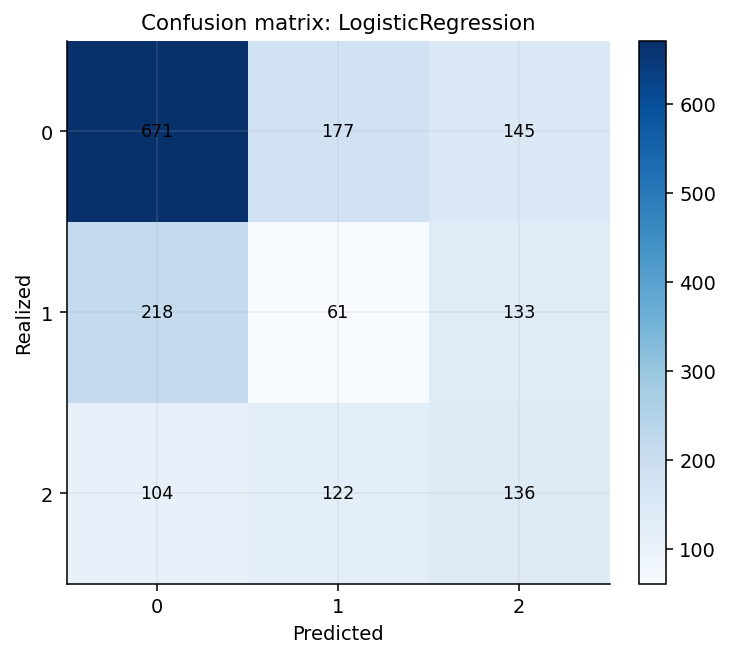

In [59]:
best_pred = ml_models[best_ml].predict(x_test)
best_cm = pd.DataFrame(
    confusion_matrix(y_test, best_pred, labels=class_labels),
    index=[f"true_{i}" for i in class_labels],
    columns=[f"pred_{i}" for i in class_labels],
)
display(best_cm)
fig, ax = plt.subplots(figsize=(5.8, 4.8))
im = ax.imshow(best_cm.values, cmap="Blues")
ax.set_xticks(range(len(class_labels)))
ax.set_yticks(range(len(class_labels)))
ax.set_xticklabels(class_labels)
ax.set_yticklabels(class_labels)
for i in range(best_cm.shape[0]):
    for j in range(best_cm.shape[1]):
        ax.text(j, i, int(best_cm.iloc[i, j]), ha="center", va="center", fontsize=9)
ax.set_xlabel("Predicted")
ax.set_ylabel("Realized")
ax.set_title(f"Confusion matrix: {best_ml}")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

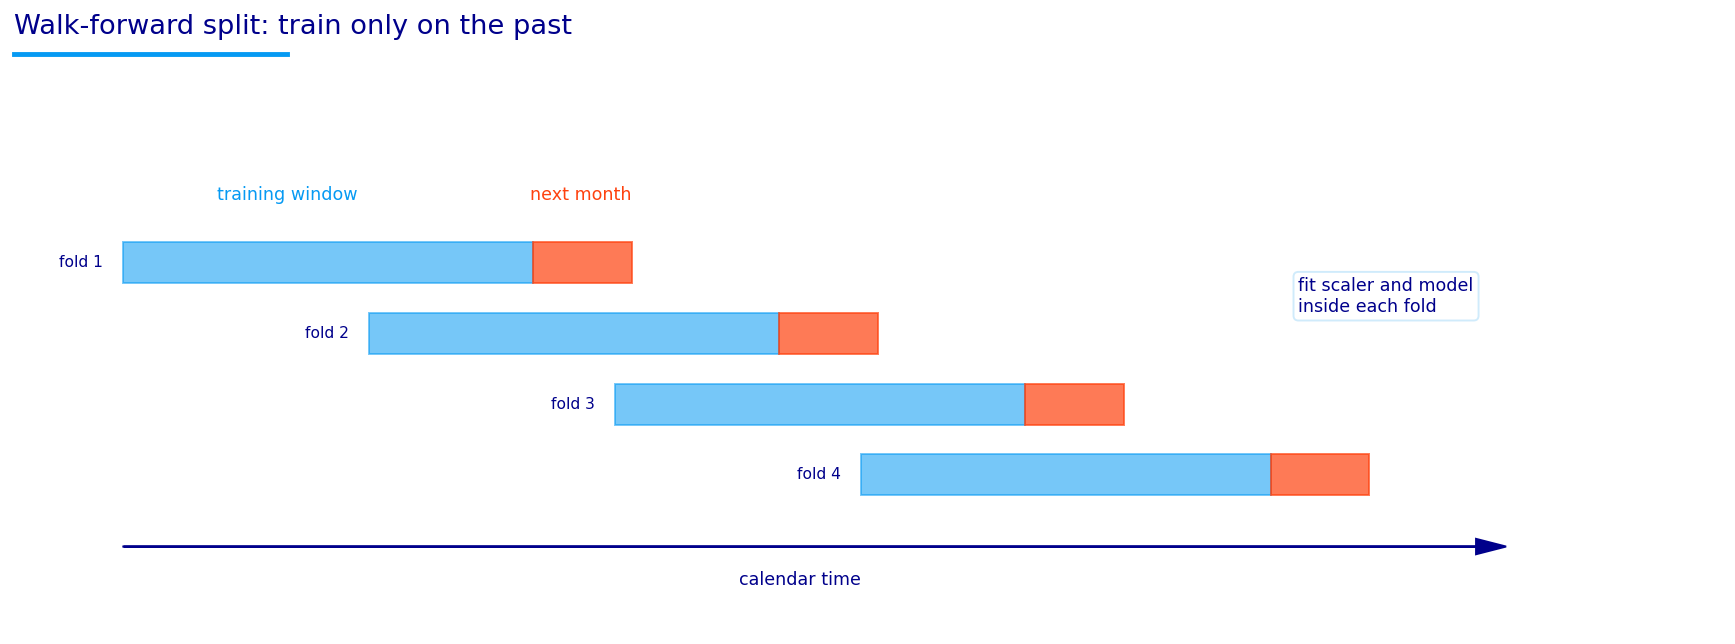

In [60]:
fig, ax = walkforward_split()
plt.show()

In [61]:
def fit_eco_now(model_name, train_raw):
    local_scaler = StandardScaler()
    train_z = pd.DataFrame(local_scaler.fit_transform(train_raw), index=train_raw.index, columns=train_raw.columns)
    state = {"model_name": model_name, "scaler": local_scaler, "train_z": train_z, "pca": None}
    if model_name.startswith("PCA-HMM"):
        n = int(str(model_name).split()[-1]) if str(model_name).split()[-1].isdigit() else len(regime_names)
        pca_n = min(5, train_z.shape[1])
        local_pca = PCA(n_components=pca_n, random_state=42).fit(train_z)
        z_fit = pd.DataFrame(local_pca.transform(train_z), index=train_z.index)
        model = GaussianHMM(n_components=n, covariance_type="diag", n_iter=100, random_state=42, min_covar=1e-4).fit(z_fit)
        lab = pd.Series(model.predict(z_fit), index=train_z.index)
        mapping = align_model_states_to_regimes(lab, train_raw)
        state.update({"model": model, "pca": local_pca, "mapping": mapping, "train_fit": z_fit})
        return state
    if model_name.startswith("HMM"):
        n = int(model_name.split()[1])
        model = GaussianHMM(n_components=n, covariance_type="diag", n_iter=100, random_state=42, min_covar=1e-4).fit(train_z)
        lab = pd.Series(model.predict(train_z), index=train_z.index)
        mapping = align_model_states_to_regimes(lab, train_raw)
        state.update({"model": model, "mapping": mapping, "train_fit": train_z})
        return state
    if model_name.startswith("GMM 3"):
        model = GaussianMixture(n_components=3, covariance_type="diag", n_init=5, random_state=42, reg_covar=1e-5).fit(train_z)
    elif model_name.startswith("Bayesian"):
        model = BayesianGaussianMixture(n_components=6, covariance_type="diag", random_state=42, max_iter=350, weight_concentration_prior=0.25).fit(train_z)
    else:
        model = GaussianMixture(n_components=4, covariance_type="diag", n_init=5, random_state=42, reg_covar=1e-5).fit(train_z)
    lab = pd.Series(model.predict(train_z), index=train_z.index)
    active = sorted(lab.unique())
    proba_train = pd.DataFrame(model.predict_proba(train_z), index=train_z.index).reindex(columns=active, fill_value=0.0)
    mapping = align_model_states_to_regimes(lab, train_raw)
    state.update({"model": model, "mapping": mapping, "active": active, "train_fit": train_z, "proba_train": proba_train})
    return state

def align_model_states_to_regimes(labels, train_raw):
    known_index = train_raw.index[:-horizon] if len(train_raw) > horizon else train_raw.index
    outcomes = future_for_quality.reindex(known_index).dropna()
    lab = labels.copy() if isinstance(labels, pd.Series) else pd.Series(labels, index=train_raw.index)
    lab = lab.reindex(outcomes.index).dropna()
    common = outcomes.index.intersection(lab.index)
    if len(common) < 60 or lab.loc[common].nunique() < 2:
        prof = state_profile_local(train_raw, labels)
    else:
        prof = state_profile_local(train_raw.reindex(common), lab.loc[common], outcomes.loc[common])
    order = sort_profile_states(prof)
    if not order:
        return {}
    mapping = {}
    if len(order) == 1:
        mapping[int(order[0])] = "neutral"
        return mapping
    mapping[int(order[0])] = "risk_on"
    mapping[int(order[-1])] = "defensive"
    for old in order[1:-1]:
        mapping[int(old)] = "neutral"
    return mapping

def shrink_probabilities(p, base=0.10):
    p = pd.Series(p, dtype=float).reindex(regime_names).fillna(0.0)
    p = p / p.sum() if p.sum() > 1e-12 else pd.Series(1.0 / len(regime_names), index=regime_names)
    confidence = float(p.max())
    shrink = float(base + (0.15 if confidence > 0.98 else 0.0))
    uniform = pd.Series(1.0 / len(p), index=p.index)
    out = (1.0 - shrink) * p + shrink * uniform
    return out / out.sum()

def eco_current_proba(state, current_raw):
    z_cur = pd.DataFrame(state["scaler"].transform(current_raw), index=current_raw.index, columns=current_raw.columns)
    if state["model_name"].startswith("PCA-HMM"):
        z_seq = pd.concat([state["train_fit"], pd.DataFrame(state["pca"].transform(z_cur), index=z_cur.index)], axis=0)
        p_raw = state["model"].predict_proba(z_seq)[-1]
    elif state["model_name"].startswith("HMM"):
        z_seq = pd.concat([state["train_fit"], z_cur], axis=0)
        p_raw = state["model"].predict_proba(z_seq)[-1]
    else:
        p_raw = state["model"].predict_proba(z_cur)[0]
    p = pd.Series(0.0, index=regime_names)
    mapping = state.get("mapping", {})
    for old_i, val in enumerate(p_raw):
        p[mapping.get(int(old_i), "neutral")] += float(val)
    return shrink_probabilities(p, base=0.12)

In [62]:
wf_dates = pd.DatetimeIndex([d for d in rebalance_dates_all if d in x_raw.index and d in y.index or d in x_raw.index])
wf_dates = wf_dates[wf_dates >= x_raw.index[min(train_days, len(x_raw) - 1)]]
refit_every = 3
p_eco_rows = []
eco_state_cache = None

for i, dt in enumerate(wf_dates):
    hist_raw = x_raw.loc[:dt].tail(train_days)
    if len(hist_raw) < 756:
        continue
    if eco_state_cache is None or i % refit_every == 0:
        eco_state_cache = fit_eco_now(best_eco, hist_raw)
    p_now = eco_current_proba(eco_state_cache, x_raw.loc[[dt], selected_features])
    p_now.name = dt
    p_eco_rows.append(p_now)

p_eco = pd.DataFrame(p_eco_rows).sort_index()
display(p_eco.tail().round(4))

,risk_on,neutral,defensive
2025-06-30,0.0435,0.4794,0.4771
2025-07-31,0.0424,0.4795,0.4780
2025-08-29,0.8148,0.0926,0.0926
2025-09-30,0.8173,0.0914,0.0913
2025-10-31,0.8186,0.0907,0.0907


In [63]:
def make_ml_model(name):
    if name == "LogisticRegression":
        return LogisticRegression(max_iter=2500, class_weight="balanced", C=0.75)
    if name == "LinearDiscriminantAnalysis":
        return LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
    if name == "RandomForestClassifier":
        return RandomForestClassifier(n_estimators=320, min_samples_leaf=24, class_weight="balanced_subsample", random_state=42, n_jobs=1)
    if name == "GradientBoostingClassifier":
        return GradientBoostingClassifier(n_estimators=260, learning_rate=0.035, max_depth=2, min_samples_leaf=25, random_state=42)
    if name == "LGBMClassifier" and lgbm_available:
        return LGBMClassifier(n_estimators=320, learning_rate=0.025, num_leaves=15, min_child_samples=45, subsample=0.85, colsample_bytree=0.85, objective="multiclass", random_state=42, verbosity=-1, n_jobs=1)
    if name == "SVC":
        return SVC(C=1.8, gamma="scale", probability=True, class_weight="balanced", random_state=42)
    return KNeighborsClassifier(n_neighbors=31, weights="distance")

def make_calibrated_ml_model(name):
    return make_ml_model(name)

def current_ml_proba(model, current_z):
    if hasattr(model, "predict_proba"):
        raw = model.predict_proba(current_z)[0]
        classes = model.classes_
    else:
        pred = model.predict(current_z)[0]
        raw = np.array([1.0])
        classes = np.array([pred])
    p = pd.Series(0.0, index=regime_names)
    for cls, val in zip(classes, raw, strict=False):
        p[regime_names[int(cls)]] = float(val)
    return shrink_probabilities(p, base=0.06)

def current_stress_proba(model, current_z):
    if model is None:
        return 0.0
    raw = model.predict_proba(current_z)[0]
    classes = list(model.classes_)
    return float(raw[classes.index(1)]) if 1 in classes else 0.0

def blend_horizon_and_stress(p_fast, p_slow, p_stress):
    p = shrink_probabilities(0.65 * p_fast + 0.35 * p_slow, base=0.03)
    defensive_floor = 0.85 * float(p_stress)
    if defensive_floor > p["defensive"]:
        p["defensive"] = defensive_floor
        remaining = max(1.0 - p["defensive"], 0.0)
        nondef = p[["risk_on", "neutral"]]
        if nondef.sum() > 1e-12:
            p.loc[["risk_on", "neutral"]] = remaining * nondef / nondef.sum()
        else:
            p.loc[["risk_on", "neutral"]] = remaining / 2.0
    return p / p.sum()

In [64]:
p_ml_rows = []
ml_state_cache = None

for i, dt in enumerate(wf_dates):
    pos = x_raw.index.searchsorted(dt, side="right") - 1
    if pos <= horizon_slow:
        continue
    label_cutoff = x_raw.index[max(0, pos - horizon)]
    slow_cutoff = x_raw.index[max(0, pos - horizon_slow)]
    train_idx = y.loc[:label_cutoff].tail(train_days).index
    slow_idx = y_slow.loc[:slow_cutoff].tail(train_days).index
    stress_idx = stress_label.loc[:label_cutoff].tail(train_days).index
    if len(train_idx) < 756 or y.loc[train_idx].nunique() < 2:
        continue
    if ml_state_cache is None or i % refit_every == 0:
        local_scaler = StandardScaler()
        X_fit = pd.DataFrame(local_scaler.fit_transform(x_raw.loc[train_idx]), index=train_idx, columns=selected_features)
        model_fast = make_calibrated_ml_model(best_ml)
        try:
            model_fast.fit(X_fit, y.loc[train_idx])
        except Exception:
            model_fast = make_ml_model(best_ml)
            model_fast.fit(X_fit, y.loc[train_idx])

        model_slow = None
        if len(slow_idx) >= 756 and y_slow.loc[slow_idx].nunique() > 1:
            X_slow = pd.DataFrame(local_scaler.transform(x_raw.loc[slow_idx]), index=slow_idx, columns=selected_features)
            model_slow = make_calibrated_ml_model(best_ml)
            try:
                model_slow.fit(X_slow, y_slow.loc[slow_idx])
            except Exception:
                model_slow = make_ml_model(best_ml)
                model_slow.fit(X_slow, y_slow.loc[slow_idx])

        stress_model = None
        if len(stress_idx) >= 756 and stress_label.loc[stress_idx].nunique() > 1:
            X_stress = pd.DataFrame(local_scaler.transform(x_raw.loc[stress_idx]), index=stress_idx, columns=selected_features)
            stress_base = RandomForestClassifier(
                n_estimators=350,
                min_samples_leaf=25,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=1,
            )
            stress_model = stress_base.fit(X_stress, stress_label.loc[stress_idx])

        ml_state_cache = {"scaler": local_scaler, "model_fast": model_fast, "model_slow": model_slow, "stress_model": stress_model}
    current_z = pd.DataFrame(ml_state_cache["scaler"].transform(x_raw.loc[[dt]]), index=[dt], columns=selected_features)
    p_fast = current_ml_proba(ml_state_cache["model_fast"], current_z)
    p_slow = current_ml_proba(ml_state_cache["model_slow"], current_z) if ml_state_cache["model_slow"] is not None else p_fast
    p_stress = current_stress_proba(ml_state_cache["stress_model"], current_z)
    p_now = blend_horizon_and_stress(p_fast, p_slow, p_stress)
    p_now.name = dt
    p_ml_rows.append(p_now)

p_ml = pd.DataFrame(p_ml_rows).sort_index()
display(p_ml.tail().round(4))

,risk_on,neutral,defensive
2025-06-30,0.4548,0.1324,0.4128
2025-07-31,0.6658,0.2406,0.0936
2025-08-29,0.6262,0.3220,0.0518
2025-09-30,0.6106,0.1597,0.2297
2025-10-31,0.4776,0.1411,0.3814


In [65]:
rebal_dates = pd.DatetimeIndex(sorted(p_eco.index.intersection(p_ml.index)))
returns_bt = returns[backtest_cols].reindex(returns.index).fillna(0.0)

def align_benchmark_to_regime(w):
    out = w.reindex(index=rebal_dates, columns=backtest_cols).ffill().bfill()
    return out.fillna(0.0)

w_equal = align_benchmark_to_regime(w_equal_all)
w_mv = align_benchmark_to_regime(w_mv_all)
w_mean_cvar = align_benchmark_to_regime(w_mean_cvar_all)
w_wasserstein = align_benchmark_to_regime(w_wasserstein_all)
display(w_equal.head().round(4))
display(w_mv.head().round(4))
display(w_mean_cvar.head().round(4))
display(w_wasserstein.head().round(4))

,SPY,QQQ,IWM,EFA,EEM,VNQ,DBC,GLD,IEF,TLT,LQD,HYG,SHY
2013-11-29,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0
2013-12-31,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0
2014-01-31,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0
2014-02-28,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0
2014-03-31,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0833,0.0


,SPY,QQQ,IWM,EFA,EEM,VNQ,DBC,GLD,IEF,TLT,LQD,HYG,SHY
2013-11-29,0.2773,0.3001,0.0722,0.0002,0.0,0.0,0.0,0.0000,0.2174,0.0000,0.0004,0.1323,0.0
2013-12-31,0.2795,0.3049,0.0726,0.0002,0.0,0.0,0.0,0.0000,0.2110,0.0000,0.0004,0.1313,0.0
2014-01-31,0.2742,0.3037,0.0446,0.0002,0.0,0.0,0.0,0.0057,0.2170,0.0000,0.0218,0.1328,0.0
2014-02-28,0.1952,0.3088,0.0068,0.0002,0.0,0.0,0.0,0.0059,0.2119,0.0000,0.1399,0.1313,0.0
2014-03-31,0.1982,0.3016,0.0067,0.0002,0.0,0.0,0.0,0.0009,0.2132,0.0049,0.1416,0.1328,0.0


,SPY,QQQ,IWM,EFA,EEM,VNQ,DBC,GLD,IEF,TLT,LQD,HYG,SHY
2013-11-29,0.0000,0.4,0.1874,0.0000,0.0,0.0,0.0,0.0,0.4000,0.0126,0.0000,0.0,0.0
2013-12-31,0.0000,0.4,0.1890,0.0000,0.0,0.0,0.0,0.0,0.3925,0.0185,0.0000,0.0,0.0
2014-01-31,0.2190,0.4,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0000,0.1087,0.2724,0.0,0.0
2014-02-28,0.0000,0.4,0.0957,0.1618,0.0,0.0,0.0,0.0,0.0000,0.2950,0.0475,0.0,0.0
2014-03-31,0.3097,0.4,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0000,0.2903,0.0000,0.0,0.0


,SPY,QQQ,IWM,EFA,EEM,VNQ,DBC,GLD,IEF,TLT,LQD,HYG,SHY
2013-11-29,0.0000,0.4,0.2305,0.0000,0.0,0.0,0.0,0.0,0.3695,0.0000,0.0000,0.0,0.0
2013-12-31,0.0000,0.4,0.2002,0.0000,0.0,0.0,0.0,0.0,0.1823,0.0000,0.2175,0.0,0.0
2014-01-31,0.2000,0.4,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0000,0.0000,0.4000,0.0,0.0
2014-02-28,0.0000,0.4,0.0289,0.0311,0.0,0.0,0.0,0.0,0.0000,0.1400,0.4000,0.0,0.0
2014-03-31,0.2877,0.4,0.0000,0.0000,0.0,0.0,0.0,0.0,0.0000,0.3123,0.0000,0.0,0.0


In [66]:
period_prices = close[backtest_cols].reindex(rebal_dates).ffill()
period_returns = period_prices.shift(-1) / period_prices - 1.0

def zscore_assets(values, candidates=None):
    universe = list(candidates) if candidates is not None else backtest_cols
    s = pd.Series(values, dtype=float).reindex(universe).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    scale = s.std(ddof=0)
    return (s - s.mean()) / (scale if scale > 1e-12 else 1.0)

def sleeve_from_scores(scores, top_n=5, max_weight=0.30):
    s = pd.Series(scores, dtype=float).replace([np.inf, -np.inf], np.nan).dropna()
    s = s[s.index.isin(backtest_cols)].sort_values(ascending=False)
    w = pd.Series(0.0, index=backtest_cols, dtype=float)
    if s.empty:
        w.loc[assets] = 1.0 / len(assets)
        return w
    selected = s.head(top_n)
    raw = selected - min(0.0, float(selected.min())) + 1e-6
    if raw.sum() <= 1e-12:
        raw = pd.Series(1.0, index=selected.index)
    alloc = raw / raw.sum()
    for _ in range(10):
        over = alloc > max_weight
        if not bool(over.any()):
            break
        excess = float((alloc[over] - max_weight).sum())
        alloc[over] = max_weight
        room = (max_weight - alloc[~over]).clip(lower=0.0)
        if room.sum() <= 1e-12:
            break
        alloc.loc[room.index] += excess * room / room.sum()
    w.loc[alloc.index] = alloc
    w[cash_ticker] = max(1.0 - w[assets].sum(), 0.0)
    return w / w.sum()

def smooth_weights(weights, alpha=0.50):
    rows = []
    prev = None
    neutral = pd.Series(0.0, index=backtest_cols, dtype=float)
    neutral.loc[assets] = 1.0 / len(assets)
    for dt, row in weights.iterrows():
        target = row.reindex(backtest_cols).fillna(0.0).astype(float)
        target = target / target.sum() if target.sum() > 1e-12 else neutral.copy()
        current = target if prev is None else alpha * target + (1.0 - alpha) * prev
        current = current / current.sum() if current.sum() > 1e-12 else neutral.copy()
        rows.append(current.rename(dt))
        prev = current
    return pd.DataFrame(rows)

asset_trend_63 = close[backtest_cols] / close[backtest_cols].shift(63) - 1.0
asset_trend_126 = close[backtest_cols] / close[backtest_cols].shift(126) - 1.0
asset_trend_252_21 = close[backtest_cols].shift(21) / close[backtest_cols].shift(252) - 1.0
asset_vol_126 = returns[backtest_cols].rolling(126).std(ddof=1) * np.sqrt(annualization)
asset_dd_252 = close[backtest_cols] / close[backtest_cols].rolling(252, min_periods=63).max() - 1.0

risk_on_candidates = ["SPY", "QQQ", "IWM", "EFA", "EEM", "VNQ", "DBC", "GLD", "HYG"]
defensive_candidates = ["SHY", "IEF", "TLT", "GLD", "LQD"]

def scored_sleeve(dt, candidates, top_n=5, max_weight=0.30):
    candidates = [c for c in candidates if c in backtest_cols]
    hist = returns.loc[:dt, candidates].tail(504)
    mu = hist.tail(252).mean() * annualization
    hit = hist.tail(252).gt(0.0).mean()
    trend_63 = asset_trend_63.loc[:dt].iloc[-1].reindex(candidates)
    trend_126 = asset_trend_126.loc[:dt].iloc[-1].reindex(candidates)
    skip_trend = asset_trend_252_21.loc[:dt].iloc[-1].reindex(candidates)
    vol = asset_vol_126.loc[:dt].iloc[-1].reindex(candidates)
    dd = asset_dd_252.loc[:dt].iloc[-1].reindex(candidates)
    score = (
        0.20 * zscore_assets(trend_63, candidates)
        + 0.25 * zscore_assets(trend_126, candidates)
        + 0.20 * zscore_assets(skip_trend, candidates)
        + 0.15 * zscore_assets(mu, candidates)
        + 0.08 * zscore_assets(hit, candidates)
        + 0.07 * zscore_assets(-vol, candidates)
        + 0.05 * zscore_assets(dd, candidates)
    )
    return sleeve_from_scores(score, top_n=top_n, max_weight=max_weight)

def neutral_sleeve(dt):
    mv = w_mv.reindex([dt], method="ffill").iloc[0].reindex(backtest_cols).fillna(0.0)
    scored = scored_sleeve(dt, assets, top_n=6, max_weight=0.25)
    w = 0.55 * mv + 0.45 * scored
    return w / w.sum() if w.sum() > 1e-12 else scored

def state_sleeves_at(dt, p_table, lookback_days=1008):
    hist_days = returns.index[returns.index < pd.Timestamp(dt)][-int(lookback_days):]
    R_hist = returns.loc[hist_days, assets].dropna(how="all")
    P_hist = p_table.reindex(hist_days.union(p_table.index)).sort_index().ffill().reindex(hist_days)
    P_hist = P_hist.dropna(how="all")
    common = R_hist.index.intersection(P_hist.index)
    trend = asset_trend_126.loc[:dt].iloc[-1]
    skip_trend = asset_trend_252_21.loc[:dt].iloc[-1]
    vol = asset_vol_126.loc[:dt].iloc[-1]
    dd = asset_dd_252.loc[:dt].iloc[-1]
    sleeves = {}
    for state in p_table.columns:
        if len(common) < 126 or state not in P_hist:
            score = 0.40 * zscore_assets(trend) + 0.20 * zscore_assets(skip_trend) + 0.20 * zscore_assets(-vol) + 0.20 * zscore_assets(dd)
            sleeves[state] = sleeve_from_scores(score)
            continue
        R_state = R_hist.loc[common]
        P_state = P_hist.loc[common]
        w_state = P_state[state].clip(lower=0.0)
        if w_state.sum() <= 1e-12:
            w_state = pd.Series(1.0, index=P_state.index)
        w_state = w_state / w_state.sum()
        mu = R_state.mul(w_state, axis=0).sum(axis=0) * annualization
        hit = R_state.gt(0.0).mul(w_state, axis=0).sum(axis=0)
        score = (
            0.30 * zscore_assets(mu)
            + 0.20 * zscore_assets(hit)
            + 0.20 * zscore_assets(trend)
            + 0.15 * zscore_assets(-vol)
            + 0.15 * zscore_assets(dd)
        )
        sleeves[state] = sleeve_from_scores(score)
    return pd.DataFrame(sleeves).T

def defensive_sleeve():
    base = pd.Series({"SHY": 0.40, "IEF": 0.24, "GLD": 0.20, "TLT": 0.10, "LQD": 0.06})
    w = pd.Series(0.0, index=backtest_cols, dtype=float)
    for ticker, weight in base.items():
        if ticker in w.index:
            w[ticker] = weight
    return w / w.sum() if w.sum() > 1e-12 else w

def adaptive_defensive_sleeve(dt):
    scored = scored_sleeve(dt, defensive_candidates, top_n=3, max_weight=0.45)
    base = defensive_sleeve()
    w = 0.60 * scored + 0.40 * base
    return w / w.sum() if w.sum() > 1e-12 else base

def regime_risk_budget(p):
    p = pd.Series(p, dtype=float).reindex(regime_names).fillna(0.0)
    p = p / p.sum() if p.sum() > 1e-12 else pd.Series(1.0 / len(regime_names), index=regime_names)
    entropy = -(p.clip(lower=1e-12) * np.log(p.clip(lower=1e-12))).sum() / np.log(len(p))
    risky_weight = 0.90 + 0.45 * p["risk_on"] - 0.75 * p["defensive"] - 0.10 * entropy
    return float(np.clip(risky_weight, 0.35, 1.00))

def blend_state_sleeves(dt, p_table):
    p = p_table.loc[dt].reindex(regime_names).fillna(0.0)
    if p.sum() <= 1e-12:
        p[:] = 1.0 / len(p)
    p = p / p.sum()
    risk_on = scored_sleeve(dt, risk_on_candidates, top_n=5, max_weight=0.30)
    neutral = neutral_sleeve(dt)
    defensive = adaptive_defensive_sleeve(dt)
    w = p["risk_on"] * risk_on + p["neutral"] * neutral + p["defensive"] * defensive
    if p["risk_on"] > 0.55:
        w = 0.75 * w + 0.25 * risk_on
    if p["defensive"] > 0.55:
        w = 0.70 * w + 0.30 * defensive
    w = w / w.sum()
    risky_budget = regime_risk_budget(p)
    risky_sleeve = w.copy()
    risky_sleeve[cash_ticker] = 0.0
    risky_sleeve = risky_sleeve / risky_sleeve.sum() if risky_sleeve.sum() > 1e-12 else neutral
    out = risky_budget * risky_sleeve + (1.0 - risky_budget) * defensive
    return out / out.sum()

def apply_mv_anchor(signal_weights, mv_weights, signal_share=0.80):
    mv_aligned = mv_weights.reindex(signal_weights.index).ffill().bfill().reindex(columns=signal_weights.columns).fillna(0.0)
    W = signal_share * signal_weights + (1.0 - signal_share) * mv_aligned
    return W.div(W.sum(axis=1), axis=0).fillna(0.0)

In [67]:
w_eco_signal = pd.DataFrame([blend_state_sleeves(dt, p_eco).rename(dt) for dt in rebal_dates])
w_eco_signal = smooth_weights(w_eco_signal.reindex(columns=backtest_cols).fillna(0.0), alpha=0.50)
w_eco = apply_mv_anchor(w_eco_signal, w_mv, signal_share=0.70)
display(w_eco.tail().round(4))

,SPY,QQQ,IWM,EFA,EEM,VNQ,DBC,GLD,IEF,TLT,LQD,HYG,SHY
2025-06-30,0.0143,0.0139,0.0006,0.0255,0.0131,0.0037,0.0003,0.3040,0.2446,0.0221,0.0629,0.1735,0.1214
2025-07-31,0.0154,0.0201,0.0003,0.0531,0.0170,0.0018,0.0001,0.3018,0.2029,0.0220,0.0927,0.1594,0.1132
2025-08-29,0.0617,0.0896,0.0300,0.0445,0.0773,0.0009,0.0001,0.2881,0.1482,0.0120,0.0512,0.1399,0.0566
2025-09-30,0.0842,0.1320,0.0504,0.0398,0.0923,0.0005,0.0000,0.2872,0.1202,0.0070,0.0301,0.1279,0.0283
2025-10-31,0.1108,0.1538,0.0258,0.0530,0.1304,0.0002,0.0000,0.2474,0.1188,0.0045,0.0199,0.1213,0.0141


In [68]:
w_ml_signal = pd.DataFrame([blend_state_sleeves(dt, p_ml).rename(dt) for dt in rebal_dates])
w_ml_signal = smooth_weights(w_ml_signal.reindex(columns=backtest_cols).fillna(0.0), alpha=0.50)
w_ml = apply_mv_anchor(w_ml_signal, w_mv, signal_share=0.85)
display(w_ml.tail().round(4))

,SPY,QQQ,IWM,EFA,EEM,VNQ,DBC,GLD,IEF,TLT,LQD,HYG,SHY
2025-06-30,0.0417,0.0543,0.0019,0.1008,0.0624,0.0236,0.0019,0.3210,0.1316,0.0159,0.0534,0.1330,0.0586
2025-07-31,0.0743,0.1335,0.0009,0.0932,0.1024,0.0118,0.0009,0.3003,0.1013,0.0092,0.0335,0.1094,0.0293
2025-08-29,0.0976,0.1550,0.0355,0.0622,0.1234,0.0059,0.0005,0.2874,0.0892,0.0053,0.0200,0.1034,0.0146
2025-09-30,0.1012,0.1629,0.0527,0.0435,0.1123,0.0029,0.0002,0.2984,0.0823,0.0069,0.0296,0.0881,0.0189
2025-10-31,0.0913,0.1339,0.0277,0.0427,0.1067,0.0015,0.0001,0.2947,0.0996,0.0133,0.0635,0.0802,0.0447


In [69]:
def schedule_period_returns(weights):
    aligned_ret = period_returns.reindex(weights.index).reindex(columns=weights.columns).fillna(0.0)
    return weights.mul(aligned_ret, axis=0).sum(axis=1)

def rolling_utility_weight(ra, rb, window=24, temperature=3.0):
    rows = []
    for dt in ra.index:
        a_hist = ra.loc[:dt].iloc[:-1].tail(window)
        b_hist = rb.loc[:dt].iloc[:-1].tail(window)
        if len(a_hist) < 12 or len(b_hist) < 12:
            alpha = 0.50
        else:
            ua = a_hist.mean() / (a_hist.std(ddof=1) + 1e-6)
            ub = b_hist.mean() / (b_hist.std(ddof=1) + 1e-6)
            scores = np.exp(np.clip(temperature * np.array([ua, ub]), -20, 20))
            alpha = float(scores[0] / scores.sum())
            alpha = float(np.clip(alpha, 0.25, 0.75))
        rows.append((dt, alpha))
    return pd.Series(dict(rows), name="eco_weight")

eco_period_ret = schedule_period_returns(w_eco)
ml_period_ret = schedule_period_returns(w_ml)
hybrid_eco_weight = rolling_utility_weight(eco_period_ret, ml_period_ret)
w_hybrid_signal = w_eco_signal.mul(hybrid_eco_weight, axis=0) + w_ml_signal.mul(1.0 - hybrid_eco_weight, axis=0)
w_hybrid_signal = w_hybrid_signal.div(w_hybrid_signal.sum(axis=1), axis=0).fillna(0.0)
w_hybrid = w_eco.mul(hybrid_eco_weight, axis=0) + w_ml.mul(1.0 - hybrid_eco_weight, axis=0)
w_hybrid = w_hybrid.div(w_hybrid.sum(axis=1), axis=0).fillna(0.0)
display(hybrid_eco_weight.tail().round(3).to_frame())
display(w_hybrid.tail().round(4))

,eco_weight
2025-06-30,0.512
2025-07-31,0.509
2025-08-29,0.517
2025-09-30,0.541
2025-10-31,0.539


,SPY,QQQ,IWM,EFA,EEM,VNQ,DBC,GLD,IEF,TLT,LQD,HYG,SHY
2025-06-30,0.0277,0.0336,0.0012,0.0622,0.0371,0.0134,0.0011,0.3123,0.1895,0.0191,0.0583,0.1538,0.0908
2025-07-31,0.0444,0.0758,0.0006,0.0728,0.0589,0.0067,0.0005,0.3011,0.1530,0.0157,0.0636,0.1348,0.0720
2025-08-29,0.0791,0.1212,0.0327,0.0531,0.0996,0.0033,0.0003,0.2877,0.1197,0.0087,0.0362,0.1222,0.0363
2025-09-30,0.0920,0.1462,0.0515,0.0415,0.1015,0.0016,0.0001,0.2923,0.1028,0.0069,0.0299,0.1096,0.0240
2025-10-31,0.1018,0.1446,0.0267,0.0483,0.1195,0.0008,0.0001,0.2692,0.1099,0.0086,0.0400,0.1024,0.0282


In [70]:
weights_by_strategy = {
    "Global EW": w_equal,
    "MV": w_mv,
    "Mean-CVaR 95": w_mean_cvar,
    "Wasserstein DRMV": w_wasserstein,
    "Econometric Regime": w_eco,
    "ML Regime": w_ml,
    "Hybrid Regime": w_hybrid,
}
w_max = pd.Series(0.40, index=backtest_cols)
w_max[cash_ticker] = 1.0
results = run_many_weights_backtests(
    weights_by_strategy,
    returns=returns_bt,
    cost_bps=cost_bps,
    rf_daily=rf_daily,
    w_min=0.0,
    w_max=w_max,
    long_only=True,
    normalize=True,
    weight_timing="next_close",
)
nav = pd.concat({name: res.net_values for name, res in results.items()}, axis=1).dropna(how="all")
strategy_returns = pd.concat({name: res.net_returns for name, res in results.items()}, axis=1).dropna(how="all")
turnover = pd.concat({name: res.turnover for name, res in results.items()}, axis=1)
costs = pd.concat({name: res.costs for name, res in results.items()}, axis=1)
display(nav.tail().round(4))

,Global EW,MV,Mean-CVaR 95,Wasserstein DRMV,Econometric Regime,ML Regime,Hybrid Regime
date,,,,,,,
2026-05-18,2.4784,2.1727,3.1200,3.1229,2.2342,3.4982,2.9318
2026-05-19,2.4653,2.1602,3.0904,3.0884,2.2141,3.4655,2.9050
2026-05-20,2.4889,2.1806,3.1253,3.1308,2.2435,3.5104,2.9430
2026-05-21,2.4889,2.1806,3.1253,3.1308,2.2435,3.5104,2.9430
2026-05-22,2.4889,2.1806,3.1253,3.1308,2.2435,3.5104,2.9430


In [71]:
summary = selection.build_strategy_summary(results, rf_daily=rf_daily, annualization=annualization)
display(summary.round(4))

,Optimizer,Mu model,Covariance model,CAGR,Vol,Sharpe,Max Drawdown,Calmar,Sortino,Turnover,Total Turnover,Cost Drag,Effective N,Fallbacks
Strategy,,,,,,,,,,,,,,
Global EW,Global EW,-,-,0.0746,0.1015,0.3799,-0.2218,0.3364,0.4676,0.0150,2.1559,0.0012,12.0000,0
MV,MV,-,-,0.0635,0.0726,0.3476,-0.1702,0.3729,0.4523,0.0626,9.0140,0.0059,4.4692,0
Mean-CVaR 95,Mean-CVaR 95,-,-,0.0941,0.1005,0.5595,-0.1693,0.5559,0.7245,0.3239,46.6411,0.0237,3.3015,0
Wasserstein DRMV,Wasserstein DRMV,-,-,0.0943,0.1095,0.5236,-0.1691,0.5573,0.6664,0.3313,47.7122,0.0232,3.2008,0
Econometric Regime,Econometric Regime,-,-,0.0658,0.0833,0.3415,-0.1745,0.3775,0.4275,0.1083,15.5891,0.0093,6.7676,0
ML Regime,ML Regime,-,-,0.1042,0.1037,0.6340,-0.1652,0.6306,0.8090,0.1144,16.4682,0.0078,6.6028,0
Hybrid Regime,Hybrid Regime,-,-,0.0889,0.0938,0.5419,-0.1635,0.5440,0.6864,0.1003,14.4364,0.0074,7.1535,0


In [72]:
rf_importance_table = importance.set_index("feature")
realized_profile_show = future_profile[[c for c in future_profile.columns if c.startswith("outcome_")]]
risky_hybrid = 1.0 - w_hybrid[cash_ticker]

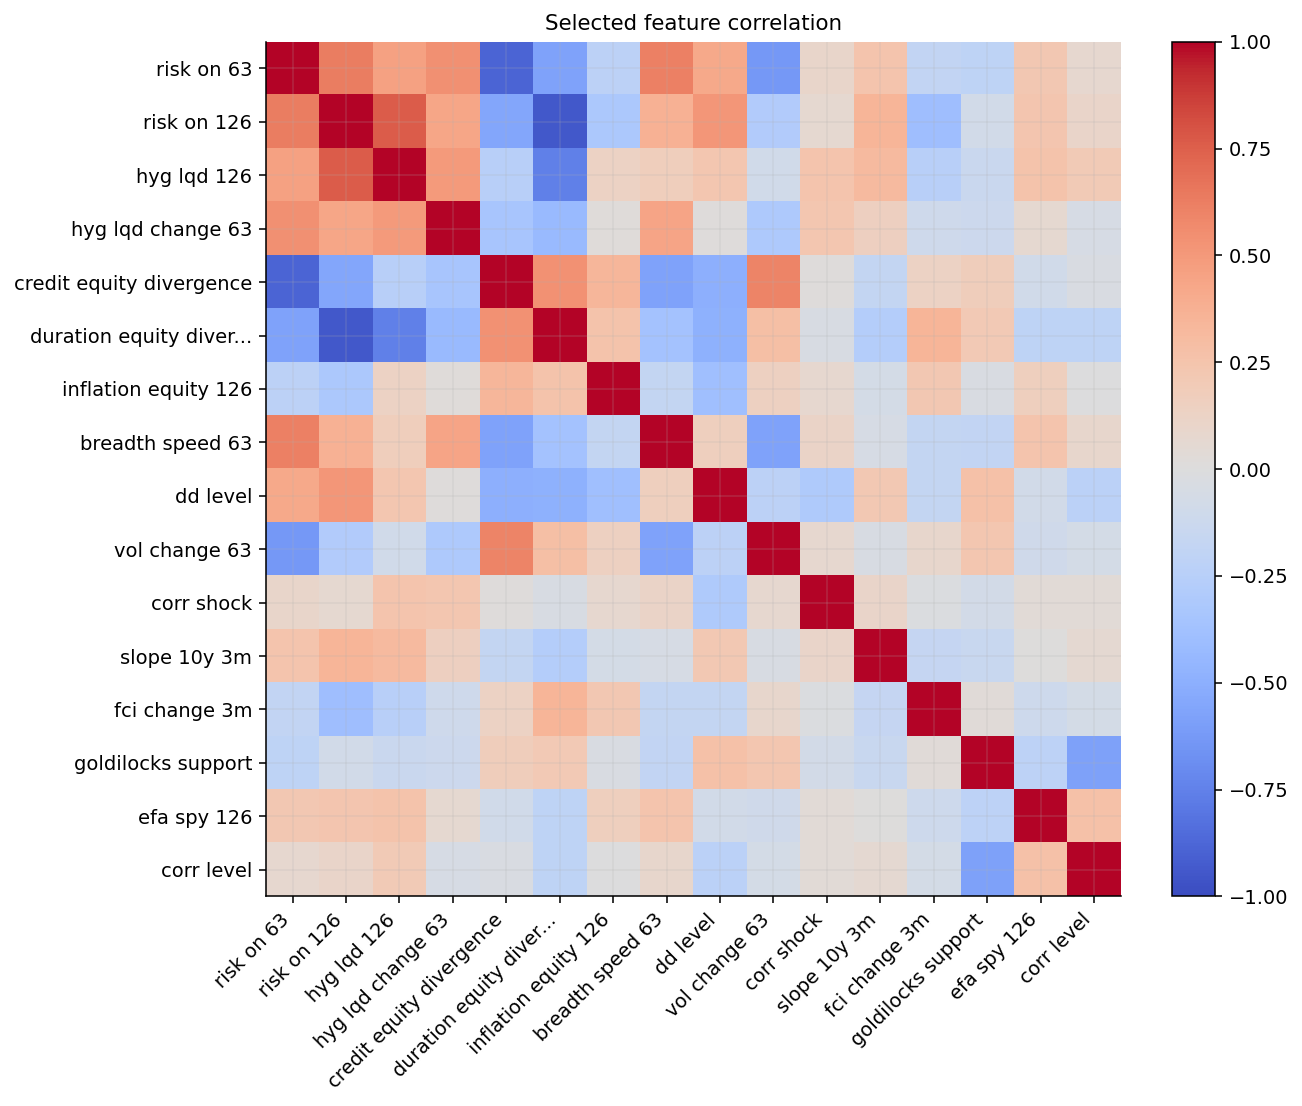

In [73]:
fig, ax = plt.subplots(figsize=(10.5, 8.0))
plot_corr_heatmap(ax, x_raw.corr(), title="Selected feature correlation", annotate=False)
plt.tight_layout()
plt.show()

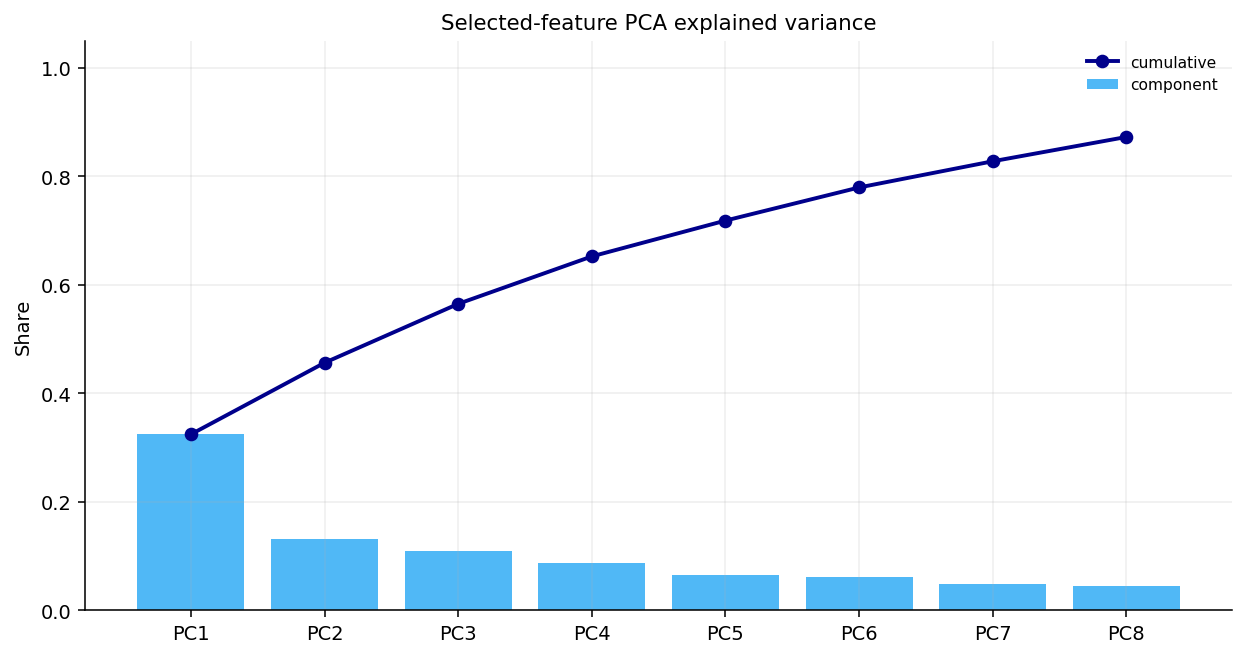

In [74]:
fig, ax = plt.subplots(figsize=(9.0, 4.8))
ax.bar(pca_explained.index, pca_explained["explained_variance_ratio"], color=LAB_COLORS[0], alpha=0.70, label="component")
ax.plot(pca_explained.index, pca_explained["cumulative"], color=LAB_COLORS[2], marker="o", lw=2.0, label="cumulative")
ax.set_title("Selected-feature PCA explained variance")
ax.set_ylabel("Share")
ax.set_ylim(0, 1.05)
ax.grid(True, axis="y", alpha=0.22)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

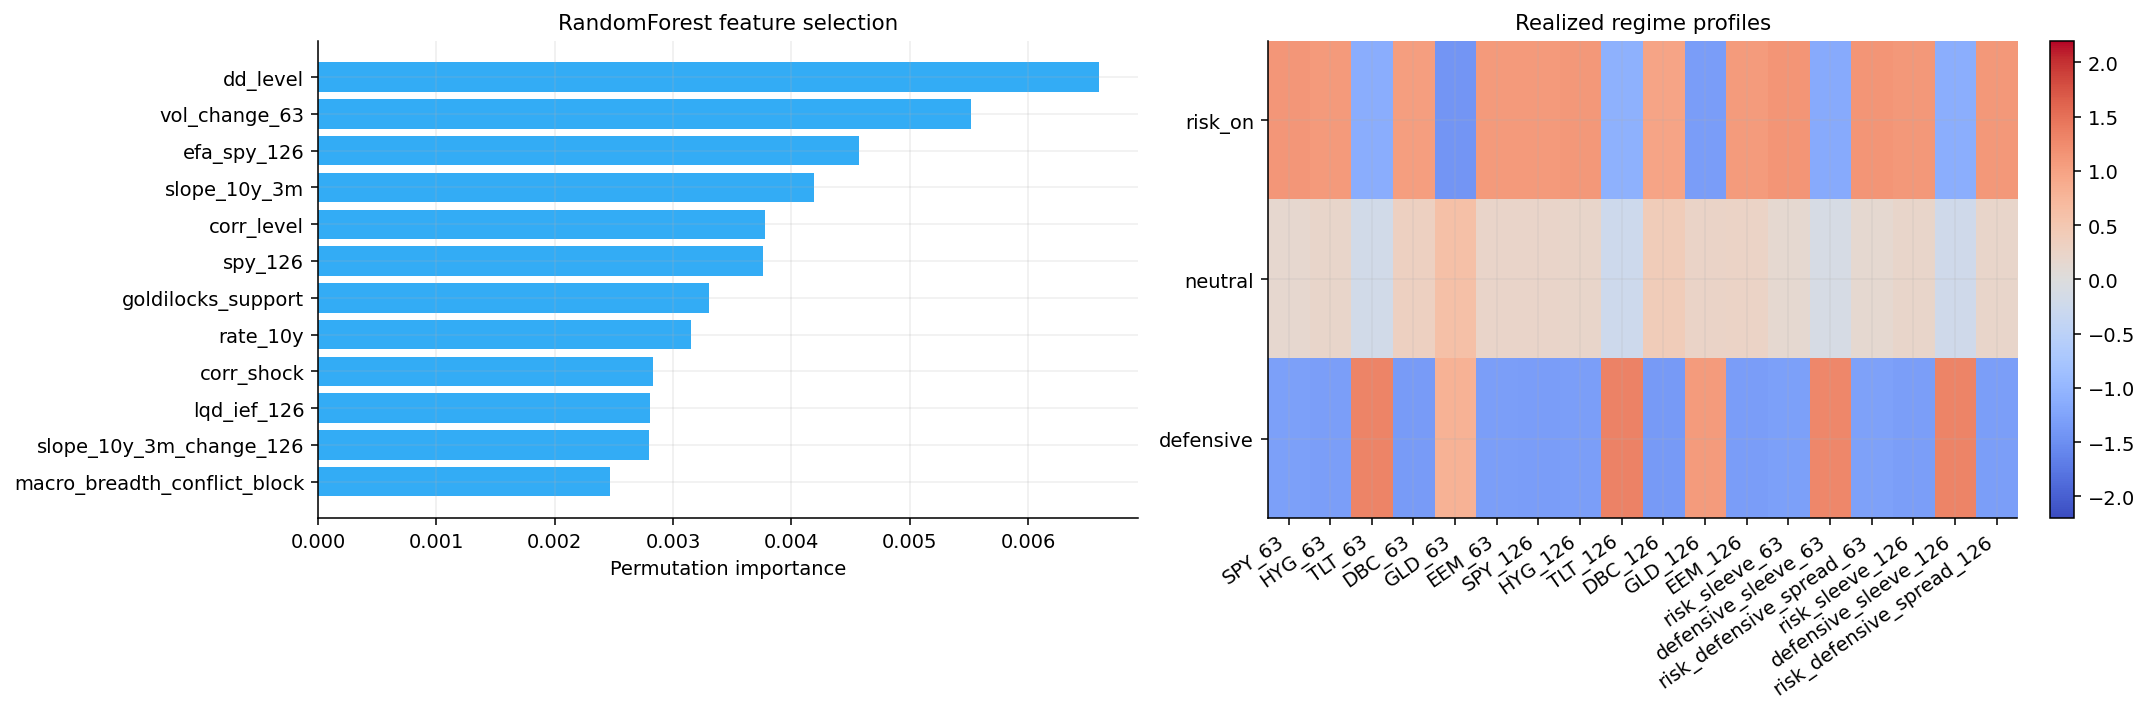

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.2))
top_imp = importance.head(12).sort_values("permutation_importance")
axes[0].barh(top_imp["feature"], top_imp["permutation_importance"], color=LAB_COLORS[0], alpha=0.82)
axes[0].set_title("RandomForest feature selection")
axes[0].set_xlabel("Permutation importance")
axes[0].grid(True, axis="x", alpha=0.22)
profile_plot = realized_profile_show.copy()
profile_plot = (profile_plot - profile_plot.mean()) / profile_plot.std(ddof=0).replace(0.0, np.nan)
im = axes[1].imshow(profile_plot.fillna(0.0).values, aspect="auto", cmap="coolwarm", vmin=-2.2, vmax=2.2)
axes[1].set_yticks(range(len(profile_plot.index)))
axes[1].set_yticklabels(profile_plot.index)
axes[1].set_xticks(range(len(profile_plot.columns)))
axes[1].set_xticklabels([c.replace("outcome_", "") for c in profile_plot.columns], rotation=35, ha="right")
axes[1].set_title("Realized regime profiles")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

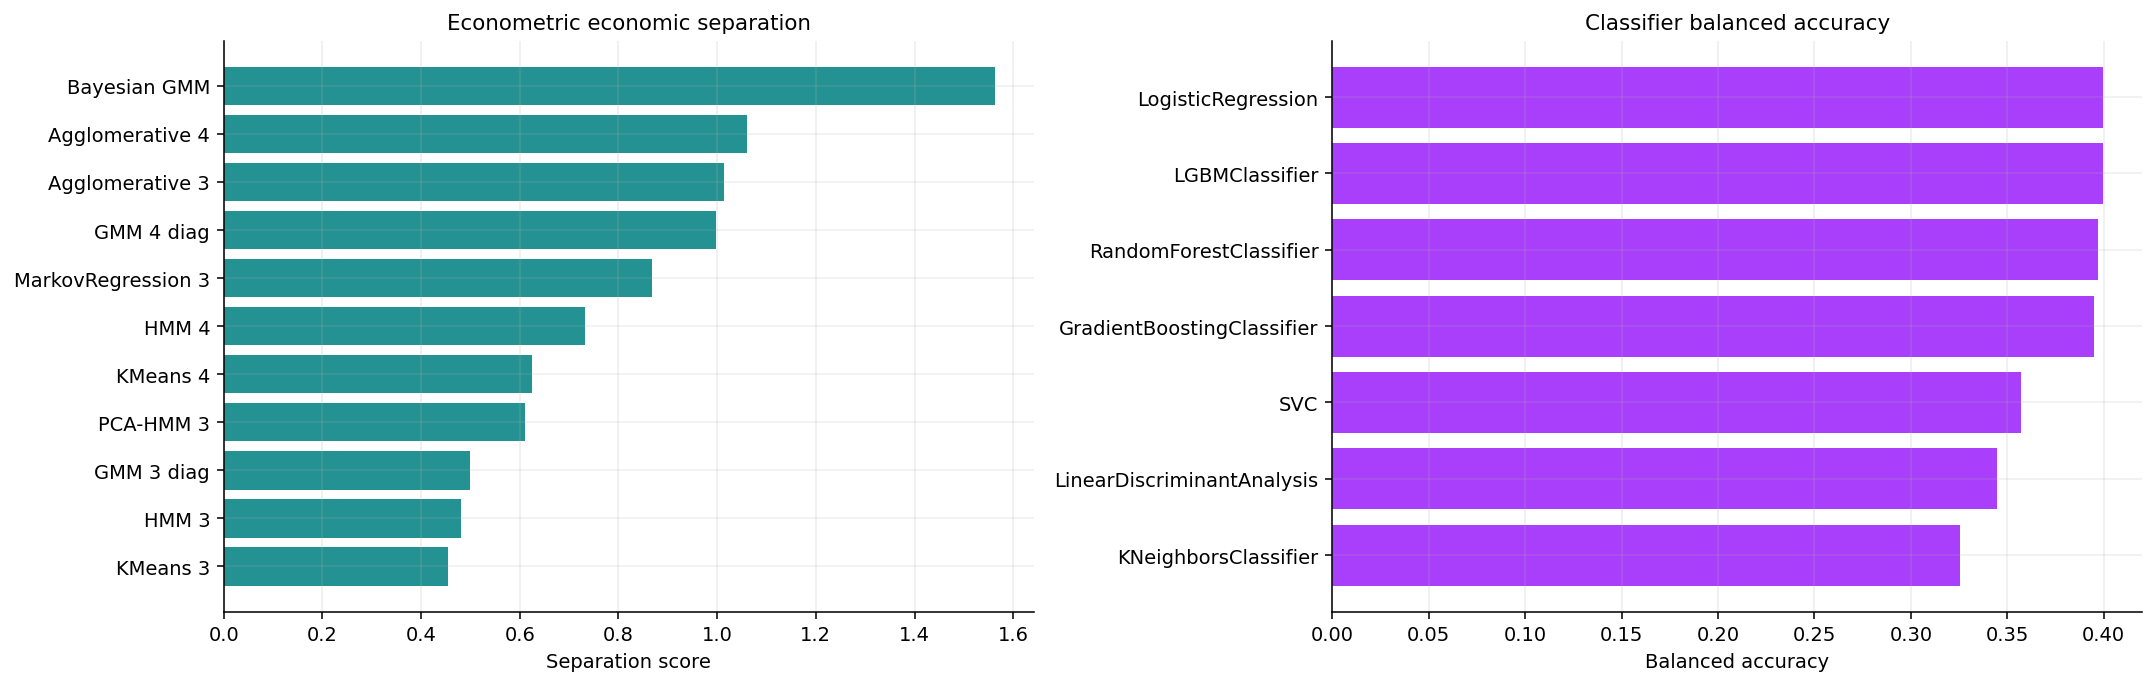

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.0))
eco_show = eco_quality["economic_separation"].sort_values()
axes[0].barh(eco_show.index, eco_show.values, color=LAB_COLORS[3], alpha=0.86)
axes[0].set_title("Econometric economic separation")
axes[0].set_xlabel("Separation score")
axes[0].grid(True, axis="x", alpha=0.22)
ml_show = classifier_table["balanced_accuracy"].sort_values()
axes[1].barh(ml_show.index, ml_show.values, color=LAB_COLORS[6], alpha=0.82)
axes[1].set_title("Classifier balanced accuracy")
axes[1].set_xlabel("Balanced accuracy")
axes[1].grid(True, axis="x", alpha=0.22)
plt.tight_layout()
plt.show()

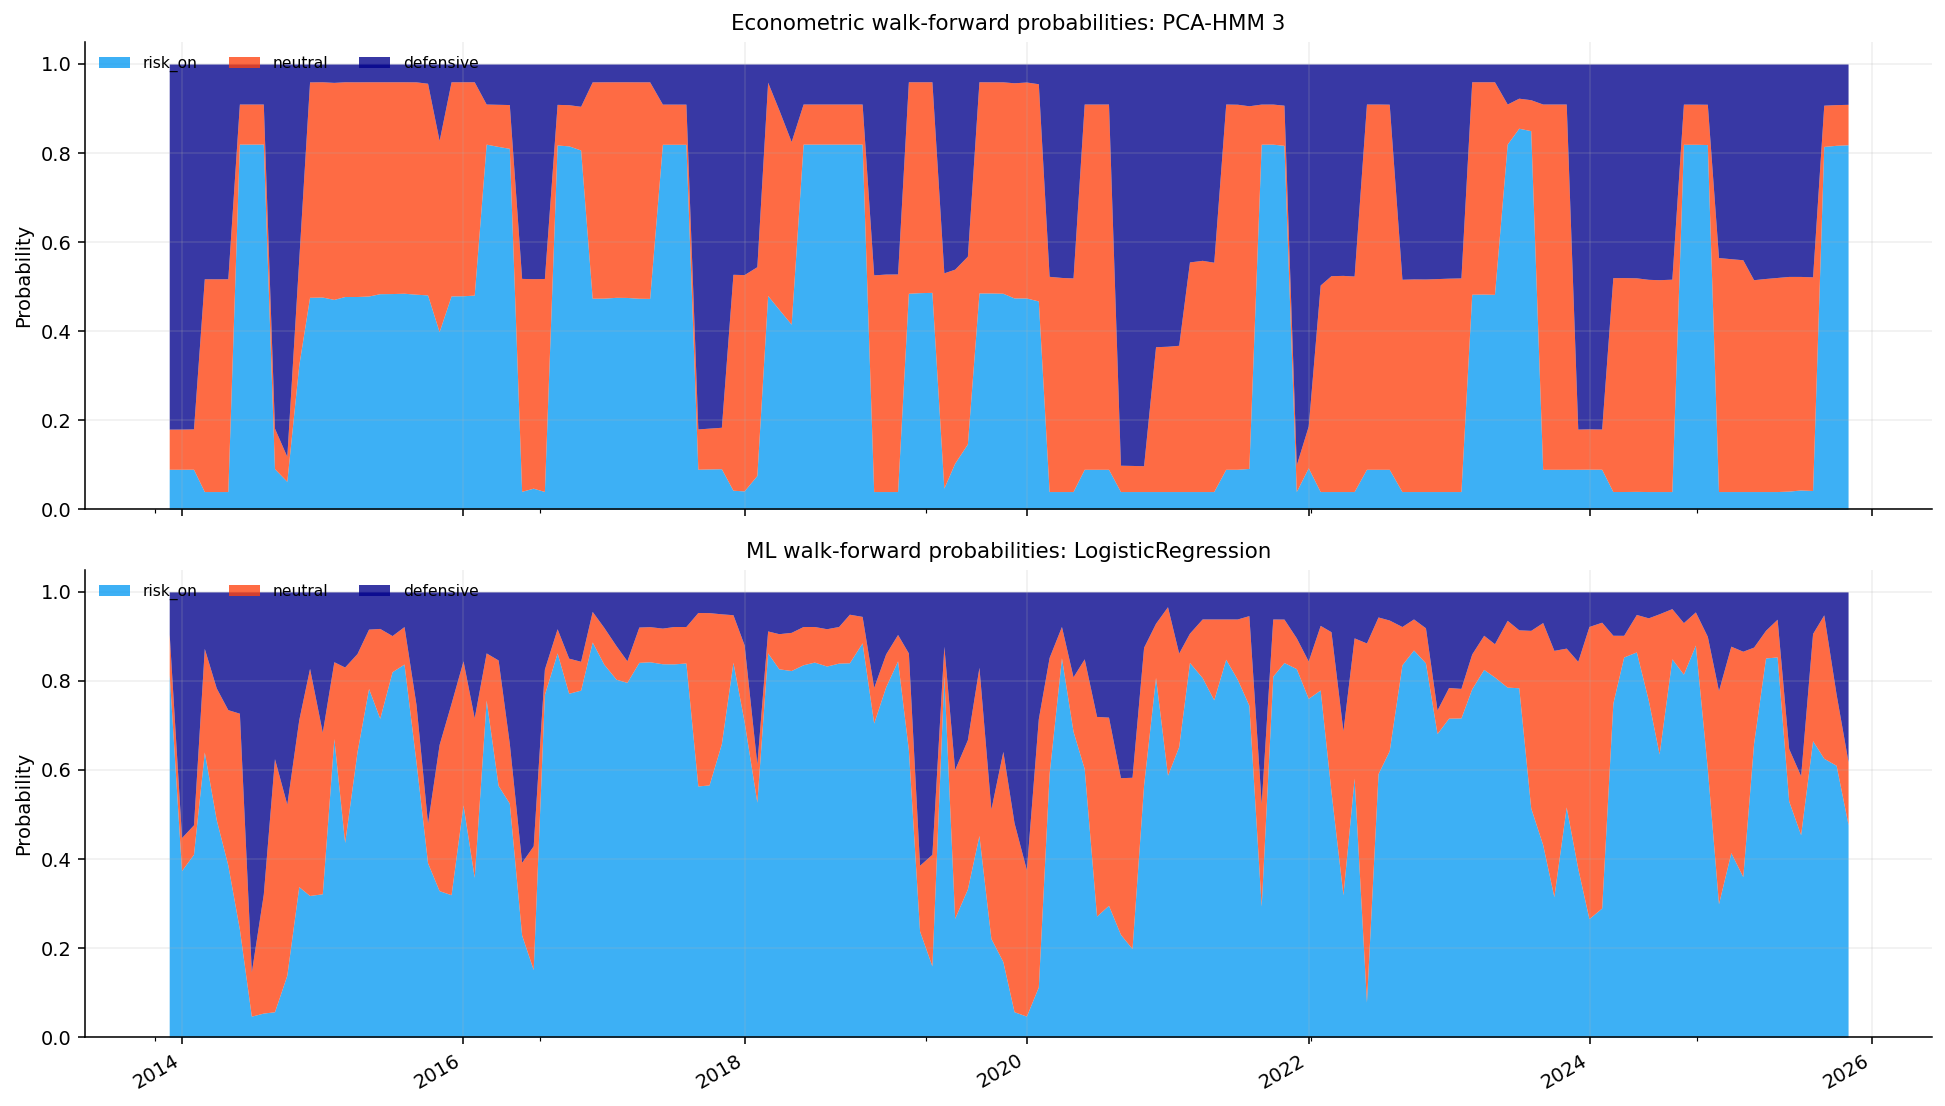

In [77]:
fig, axes = plt.subplots(2, 1, figsize=(14.0, 8.0), sharex=True)
p_eco.plot.area(ax=axes[0], stacked=True, color=LAB_COLORS[:p_eco.shape[1]], alpha=0.78, linewidth=0)
axes[0].set_title(f"Econometric walk-forward probabilities: {best_eco}")
axes[0].set_ylabel("Probability")
axes[0].legend(ncol=p_eco.shape[1], frameon=False, loc="upper left")
p_ml.plot.area(ax=axes[1], stacked=True, color=LAB_COLORS[:p_ml.shape[1]], alpha=0.78, linewidth=0)
axes[1].set_title(f"ML walk-forward probabilities: {best_ml}")
axes[1].set_ylabel("Probability")
axes[1].legend(ncol=p_ml.shape[1], frameon=False, loc="upper left")
plt.tight_layout()
plt.show()

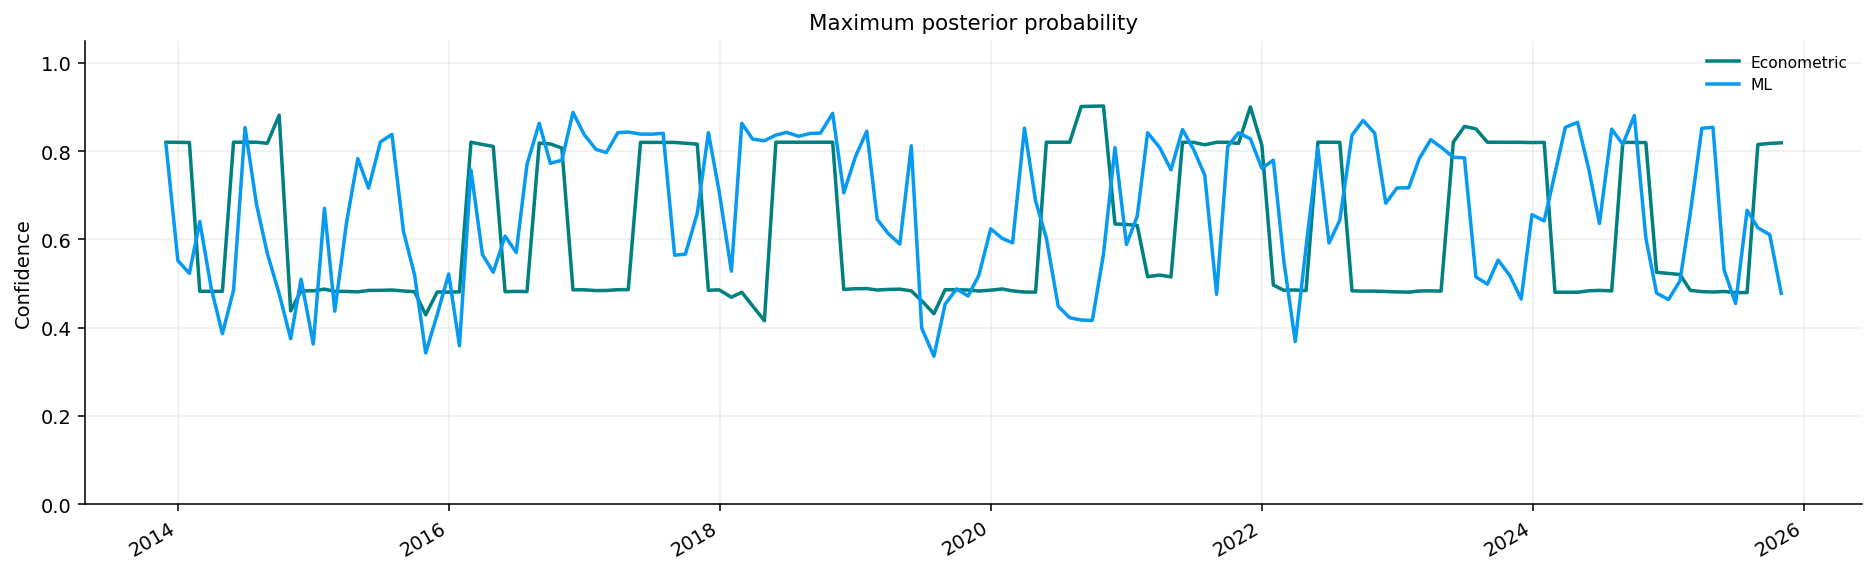

In [78]:
fig, ax = plt.subplots(figsize=(13.5, 4.2))
p_eco.max(axis=1).plot(ax=ax, color=LAB_COLORS[3], lw=1.8, label="Econometric")
p_ml.max(axis=1).plot(ax=ax, color=LAB_COLORS[0], lw=1.8, label="ML")
ax.set_title("Maximum posterior probability")
ax.set_ylabel("Confidence")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.22)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

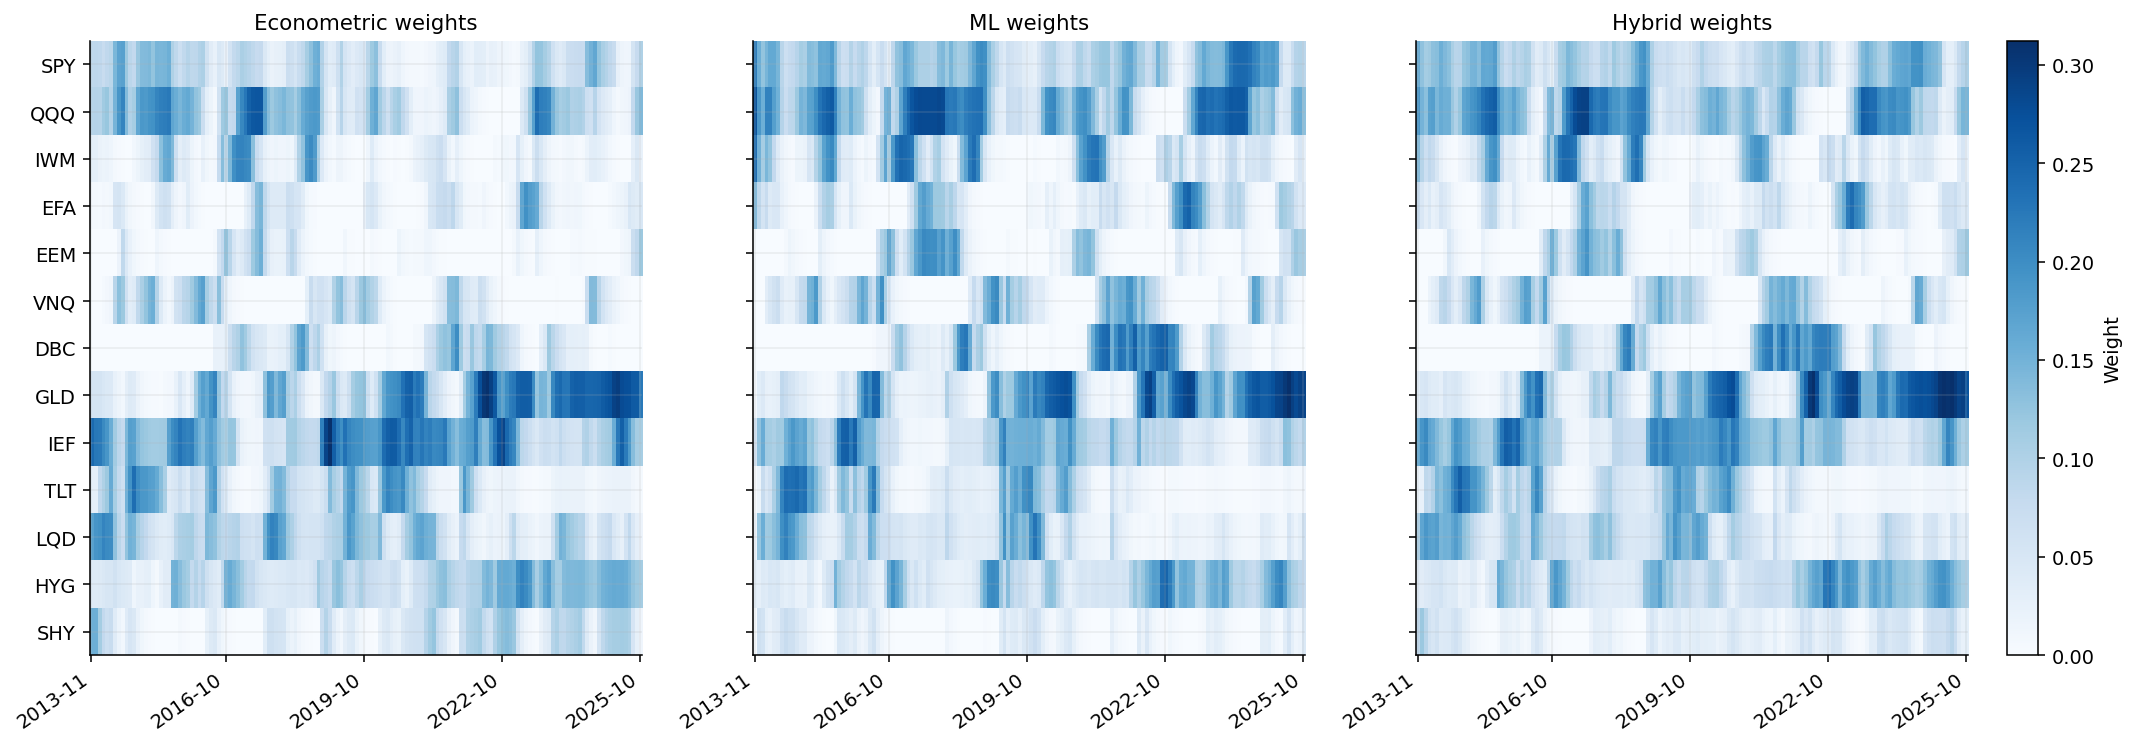

In [79]:
fig, axes = plt.subplots(1, 3, figsize=(18.0, 5.7), sharey=True)
for ax, schedule, title in zip(axes, [w_eco, w_ml, w_hybrid], ["Econometric weights", "ML weights", "Hybrid weights"], strict=False):
    im = ax.imshow(schedule.T.values, aspect="auto", cmap="Blues", vmin=0.0, vmax=max(0.22, float(schedule.max().max())))
    ax.set_title(title)
    ax.set_yticks(range(len(schedule.columns)))
    ax.set_yticklabels(schedule.columns)
    tick_pos = np.linspace(0, len(schedule.index) - 1, min(5, len(schedule.index))).astype(int)
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([schedule.index[i].strftime("%Y-%m") for i in tick_pos], rotation=35, ha="right")
fig.colorbar(im, ax=axes, fraction=0.018, pad=0.02, label="Weight")
plt.show()

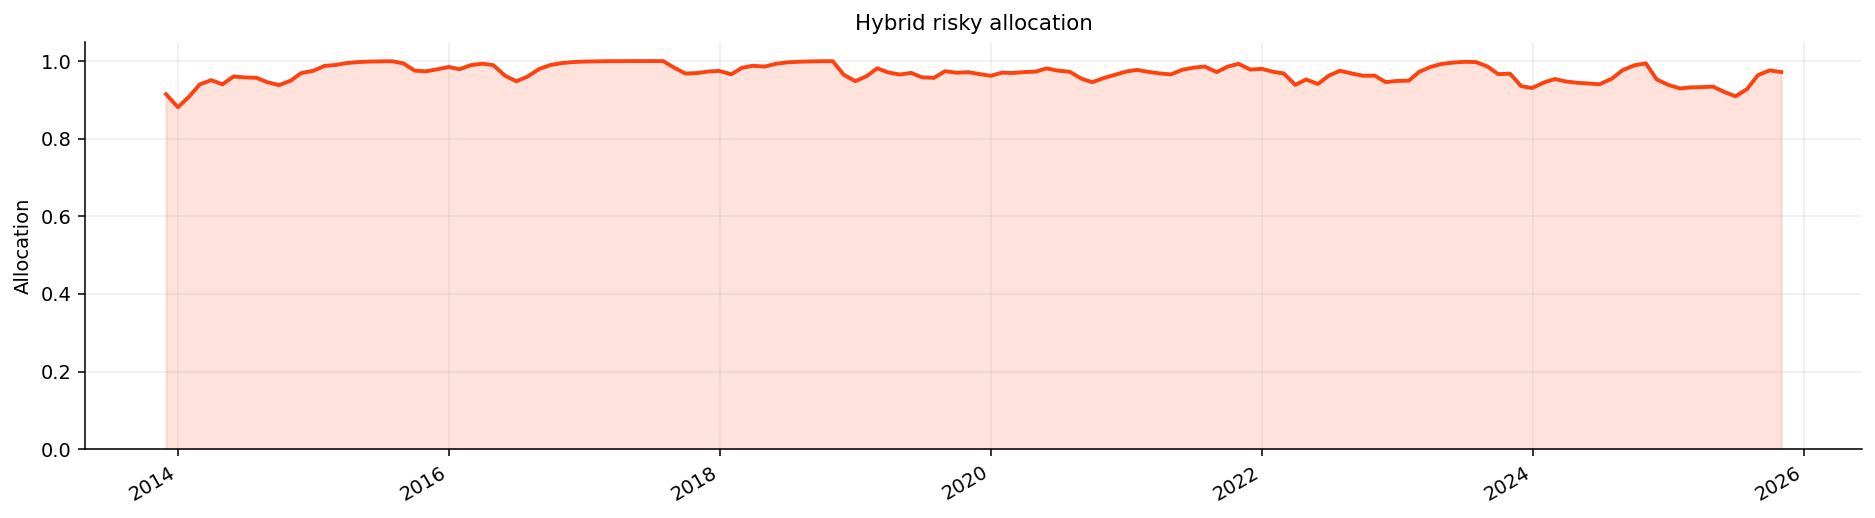

In [80]:
fig, ax = plt.subplots(figsize=(13.5, 3.8))
risky_hybrid.plot(ax=ax, color=LAB_COLORS[1], lw=2.0)
ax.fill_between(risky_hybrid.index, 0.0, risky_hybrid.values, color=LAB_COLORS[1], alpha=0.15)
ax.set_title("Hybrid risky allocation")
ax.set_ylabel("Allocation")
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.22)
plt.tight_layout()
plt.show()

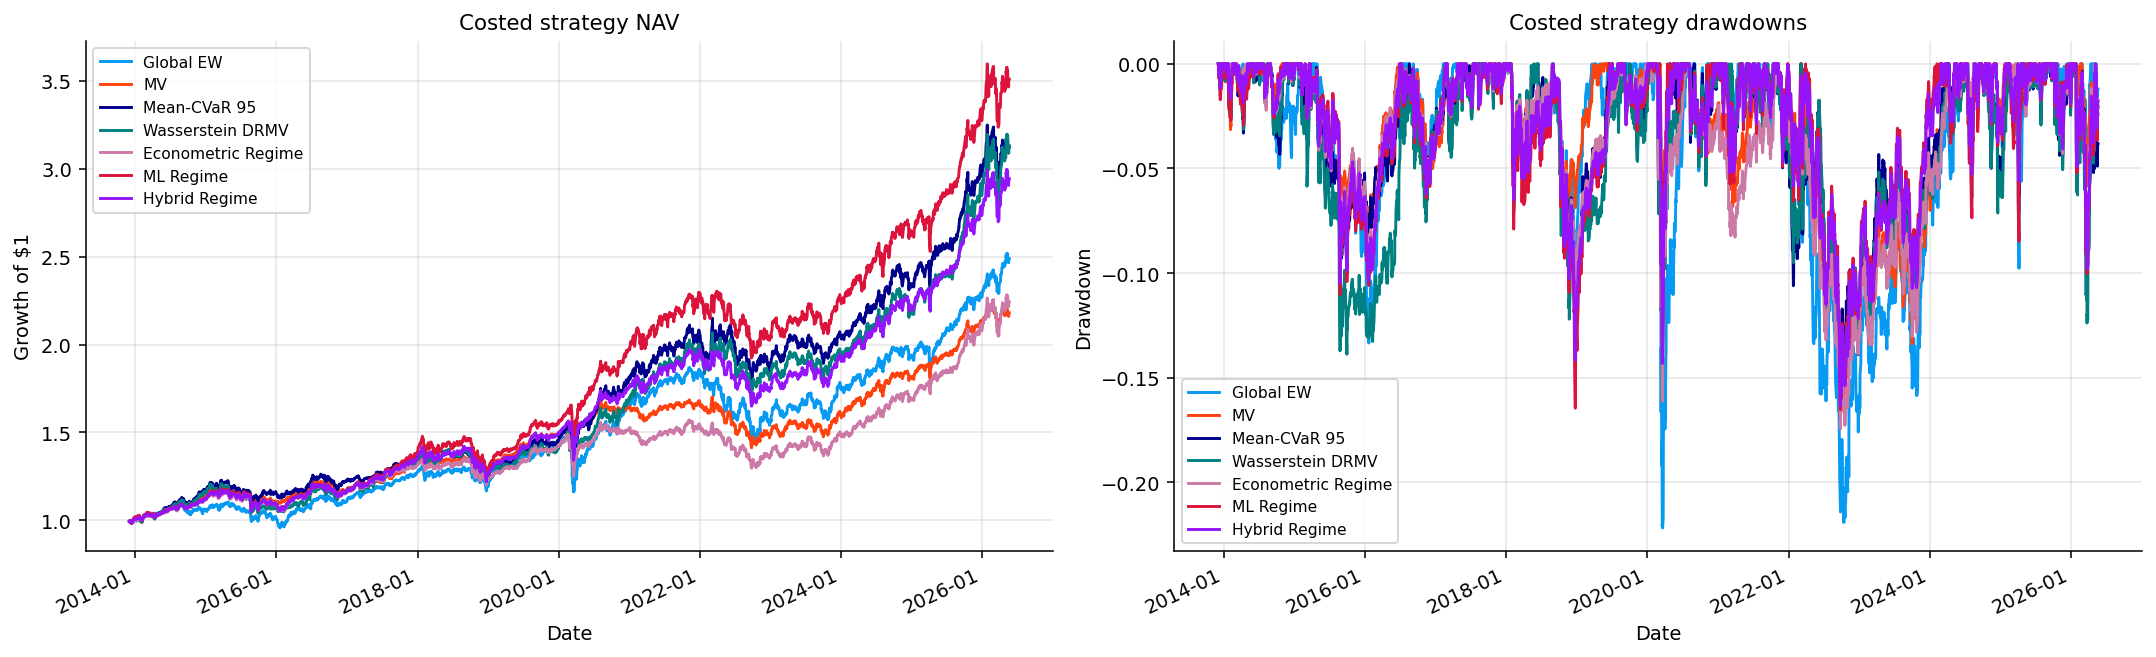

In [81]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 4.8))
plot_strategy_nav(nav, ax=axes[0], title="Costed strategy NAV")
plot_strategy_drawdowns(nav, ax=axes[1], title="Costed strategy drawdowns")
plt.tight_layout()
plt.show()

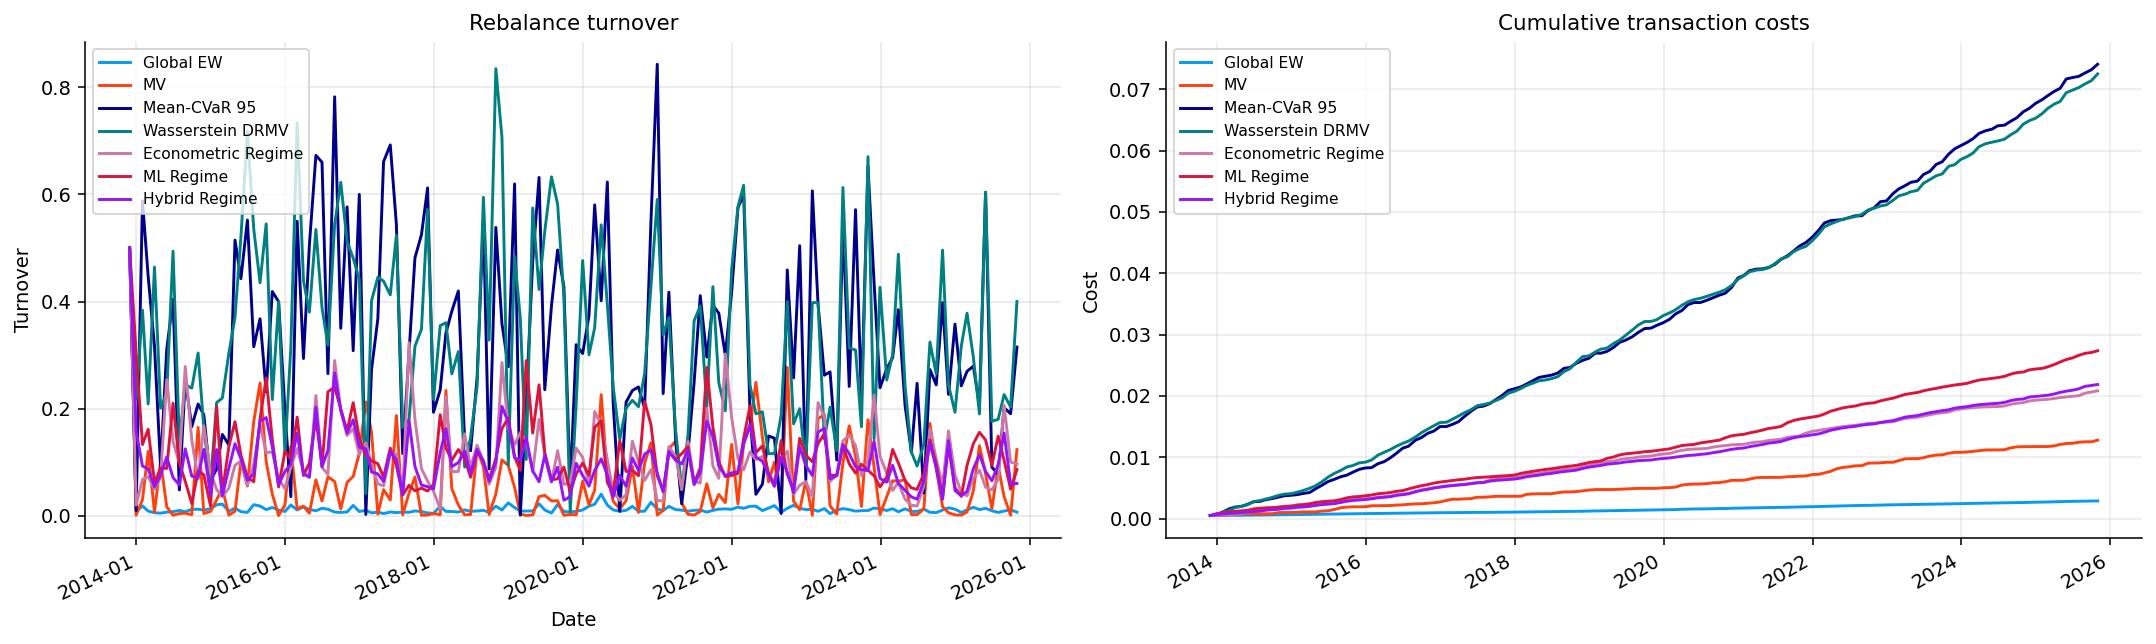

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(15.5, 4.7))
plot_turnover(turnover, ax=axes[0], title="Rebalance turnover")
costs.cumsum().plot(ax=axes[1])
axes[1].set_title("Cumulative transaction costs")
axes[1].set_ylabel("Cost")
axes[1].grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [83]:
latest_dt = w_hybrid.index[-1]
latest_snapshot = pd.DataFrame(
    {
        "eco_probability": p_eco.loc[latest_dt],
        "ml_probability": p_ml.loc[latest_dt],
    }
)
latest_weights = w_hybrid.loc[latest_dt].sort_values(ascending=False).to_frame("hybrid_weight")
latest_risky = 1.0 - float(w_hybrid.loc[latest_dt, cash_ticker])
print("latest rebalance:", latest_dt.date())
display(latest_snapshot.round(4))
display(latest_weights[latest_weights["hybrid_weight"] > 0.001].round(4))
print("latest risky allocation:", round(latest_risky, 4))

latest rebalance: 2025-10-31


,eco_probability,ml_probability
risk_on,0.8186,0.4776
neutral,0.0907,0.1411
defensive,0.0907,0.3814


,hybrid_weight
GLD,0.2692
QQQ,0.1446
EEM,0.1195
IEF,0.1099
HYG,0.1024
SPY,0.1018
EFA,0.0483
LQD,0.0400
SHY,0.0282
IWM,0.0267


latest risky allocation: 0.9718


,hist_var5,hist_es5,cf_var5,cf_es5,fhs_var5,fhs_es5
object,,,,,,
Econometric Regime,0.0081,0.0128,0.0087,0.0165,0.0169,0.0249
Global EW,0.0094,0.0151,0.0098,0.0273,0.0111,0.0169
Hybrid Regime,0.0093,0.0144,0.0096,0.0174,0.0166,0.0249
ML Regime,0.0102,0.0160,0.0103,0.0192,0.0162,0.0245
MV,0.0071,0.0110,0.0074,0.0135,0.0103,0.0152
Mean-CVaR 95,0.0098,0.0151,0.0102,0.0190,0.0156,0.0223
Wasserstein DRMV,0.0107,0.0169,0.0114,0.0201,0.0205,0.0293


breach_count  breach_rate  coverage_error  abs_coverage_error  longest_breach_streak  avg_gap_days  kupiec_p  christoffersen_p  \
object             method                                                                                                                                   
Econometric Regime cf               152       0.0517          0.0017              0.0017                      3       19.4172    0.6770            0.0064   
                   fhs              163       0.0554          0.0054              0.0054                      3       18.0988    0.1844            0.0113   
                   hist             176       0.0598          0.0098              0.0098                      3       16.7543    0.0174            0.0008   
Global EW          cf               166       0.0564          0.0064              0.0064                      4       17.7758    0.1159            0.0072   
                   fhs              159       0.0541          0.0041              0.0041                      3       18.5633    0.3180            0.0347   
                   hist             172       0.0585          0.0085              0.0085                      4       17.1520    0.0396            0.0011   
Hybrid Regime      cf               158       0.0537          0.0037              0.0037                      3       18.6115    0.3597            0.0008   
                   fhs              159       0.0541          0.0041              0.0041                      3       18.5570    0.3180            0.0067   
                   hist             170       0.0578          0.0078              0.0078                      3       17.3491    0.0579            0.0003   
ML Regime          cf               162       0.0551          0.0051              0.0051                      3       18.1118    0.2130            0.0002   
                   fhs              154       0.0524          0.0024              0.0024                      3       19.0980    0.5594            0.0198   
                   hist             175       0.0595          0.0095              0.0095                      3       16.7586    0.0215            0.0003   
MV                 cf               143       0.0486         -0.0014              0.0014                      3       20.5352    0.7307            0.0000   
                   fhs              162       0.0551          0.0051              0.0051                      3       18.2112    0.2130            0.0225   
                   hist             161       0.0547          0.0047              0.0047                      4       18.3250    0.2447            0.0000   
Mean-CVaR 95       cf               159       0.0541          0.0041              0.0041                      4       18.5570    0.3180            0.0000   
                   fhs              162       0.0551          0.0051              0.0051                      3       18.2112    0.2130            0.0006   
                   hist             164       0.0558          0.0058              0.0058                      3       17.9877    0.1588            0.0008   
Wasserstein DRMV   cf               163       0.0554          0.0054              0.0054                      3       18.0988    0.1844            0.0000   
                   fhs              159       0.0541          0.0041              0.0041                      3       18.5570    0.3180            0.0347   
                   hist             176       0.0598          0.0098              0.0098                      3       16.7543    0.0174            0.0008   

                           quantile_loss  accuracy_rank  accuracy_score  is_best  
object             method                                                         
Econometric Regime cf             0.0007            2.0          0.1250    False  
                   fhs            0.0007            1.0          0.1429     True  
                   hist           0.0007            3.0          0.0833    False  


,object,cum_return,max_dd,worst_day,worst_week
window,,,,,
2018 Q4,Econometric Regime,-0.0856,-0.1068,-0.0235,-0.0279
2018 Q4,Global EW,-0.0730,-0.0974,-0.0165,-0.0328
2018 Q4,Hybrid Regime,-0.1068,-0.1350,-0.0253,-0.0413
2018 Q4,ML Regime,-0.1230,-0.1567,-0.0267,-0.0520
2018 Q4,MV,-0.0376,-0.0486,-0.0109,-0.0193
2018 Q4,Mean-CVaR 95,-0.0892,-0.1113,-0.0155,-0.0372
2018 Q4,Wasserstein DRMV,-0.0906,-0.0998,-0.0193,-0.0374
2022 rates/inflation shock,Econometric Regime,-0.1478,-0.1659,-0.0244,-0.0234
2022 rates/inflation shock,Global EW,-0.1865,-0.2110,-0.0324,-0.0392


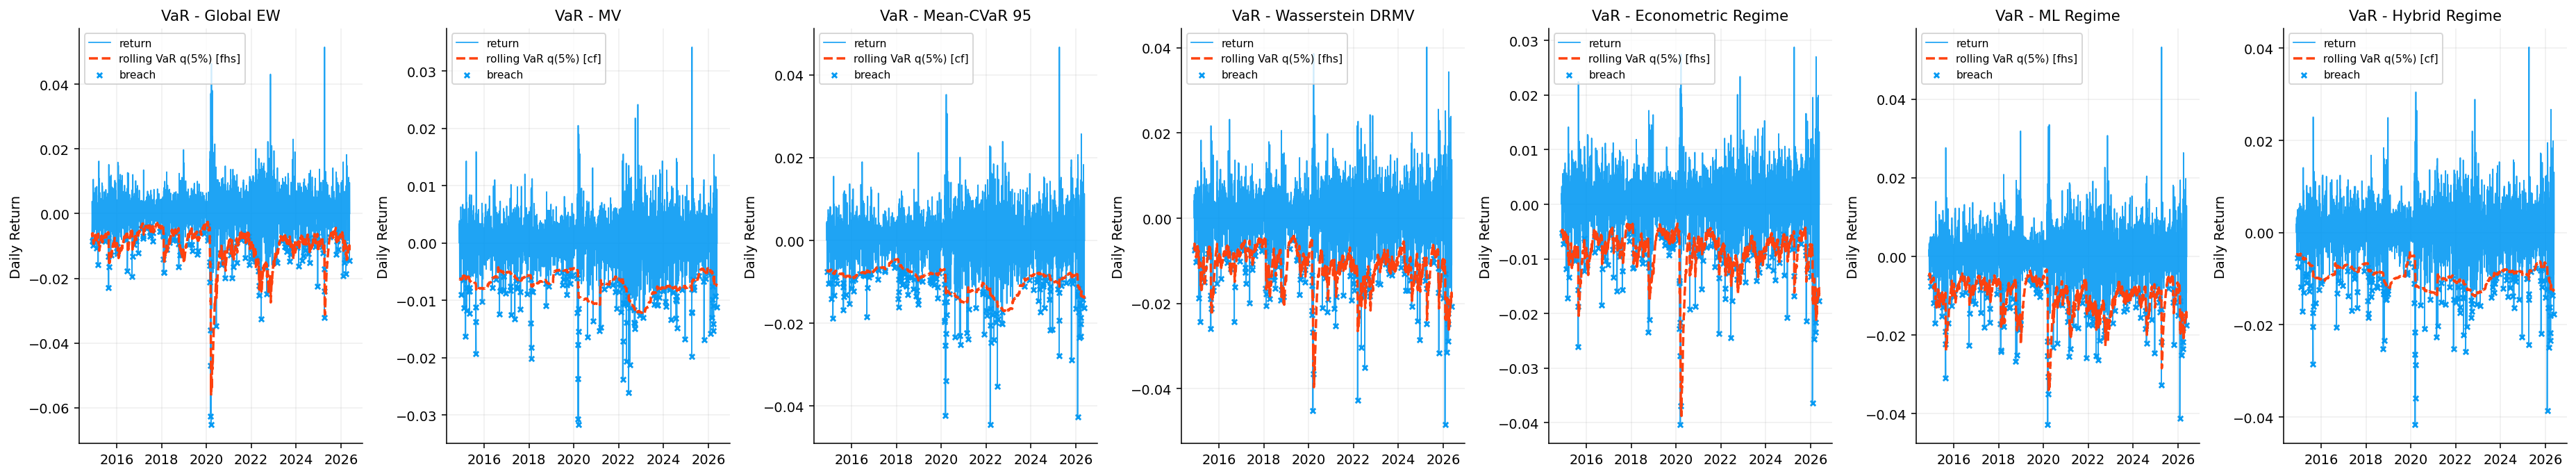

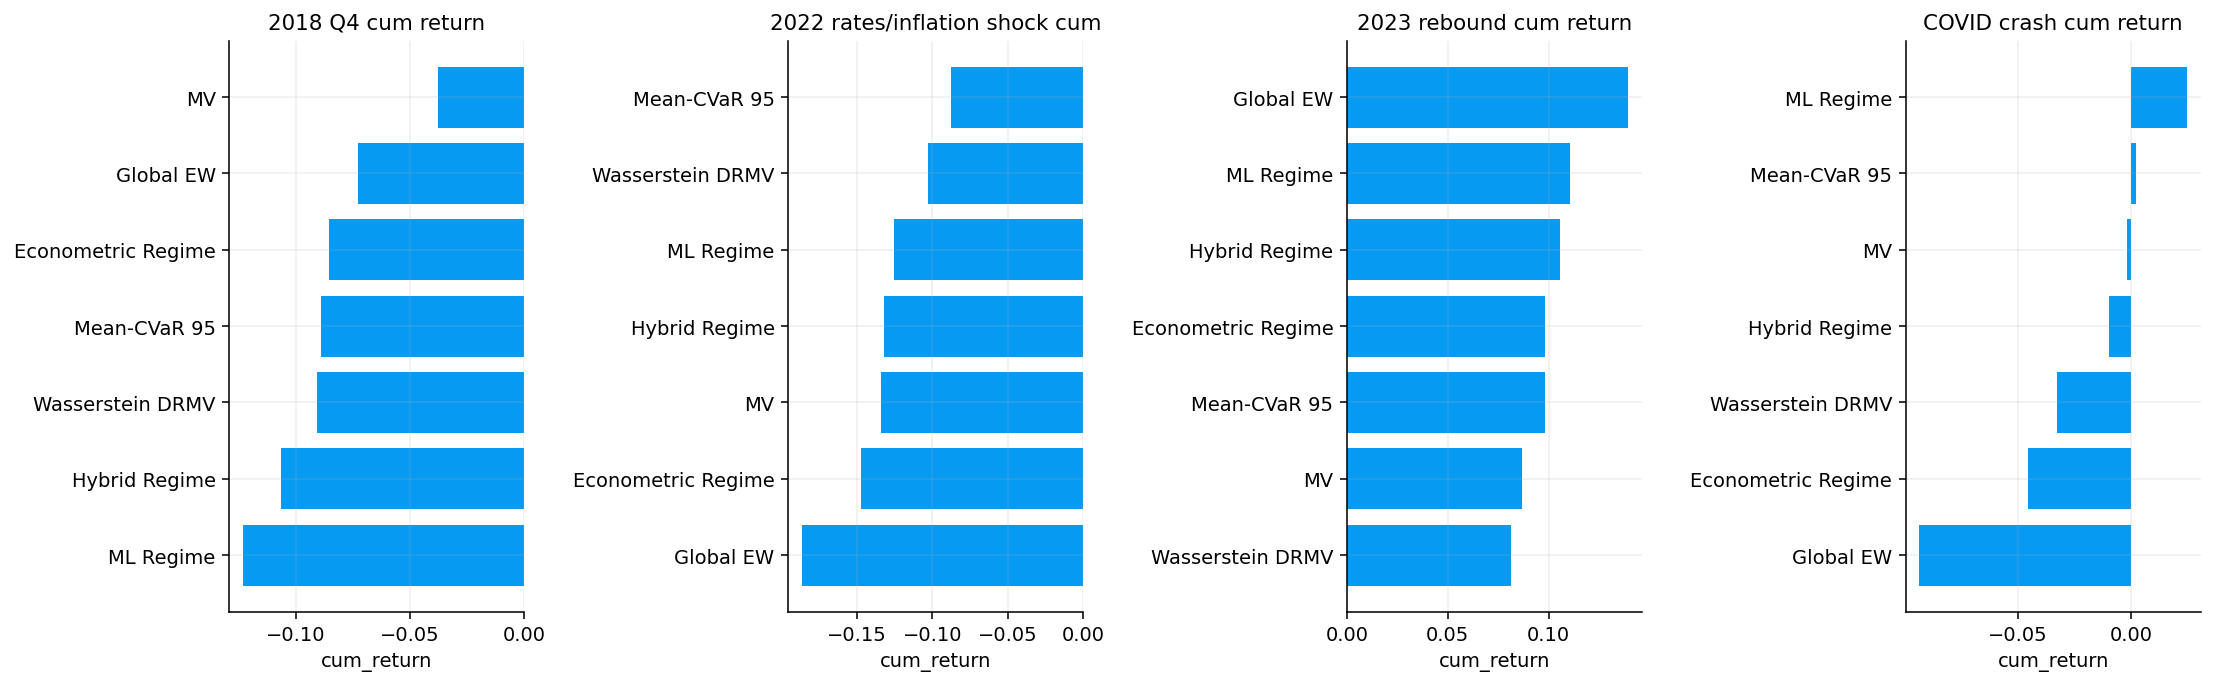

In [84]:
stress_windows = {
    "2018 Q4": ("2018-10-01", "2018-12-31"),
    "COVID crash": ("2020-02-20", "2020-04-30"),
    "2022 rates/inflation shock": ("2022-01-03", "2022-10-31"),
    "2023 rebound": ("2023-01-01", "2023-12-31"),
}
available_windows = {
    name: window
    for name, window in stress_windows.items()
    if strategy_returns.index.min() <= pd.Timestamp(window[1]) and strategy_returns.index.max() >= pd.Timestamp(window[0])
}
risk_report_artifacts = risk_report(
    objects={name: strategy_returns[name].dropna() for name in strategy_returns.columns},
    rf_daily=rf_daily,
    include={
        "performance_tables": False,
        "shape_tables": False,
        "drawdowns": False,
        "drawdown_episodes": False,
        "var_es": True,
        "var_backtest": True,
        "stress": True,
        "capm": False,
        "rolling_beta": False,
        "correlation": False,
        "attribution": False,
        "exec_bullets": False,
    },
    var_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"]},
    backtest_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"], "lookback": 252, "plot_method": "best"},
    stress_settings={"windows": available_windows, "worst_only": False},
    layout={"ncols": len(strategy_returns.columns), "sharex": True, "sharey": False},
    output={"display_table_keys": ["var_es", "var_backtest", "stress"], "round_tables": 4, "short_labels": False},
)

,states,loglike,aic,bic,silhouette,min_state_share,avg_state_duration,transitions_per_year,posterior_confidence,posterior_entropy,economic_separation
model,,,,,,,,,,,
KMeans 3,3,NaN,NaN,NaN,0.2350,0.1419,25.4615,9.0626,NaN,NaN,0.6045
KMeans 4,4,NaN,NaN,NaN,0.2034,0.1358,28.9220,8.7880,NaN,NaN,0.8635
Agglomerative 3,3,NaN,NaN,NaN,0.2518,0.0911,107.6793,1.8308,NaN,NaN,0.8579
Agglomerative 4,4,NaN,NaN,NaN,0.1760,0.0911,83.3756,2.6547,NaN,NaN,0.9266
GMM 3,3,-40662.8497,81473.6994,81913.0123,0.2331,0.1312,38.3258,6.0417,0.9699,0.0676,0.5975
GMM 4,4,-39127.9137,78453.8275,79041.5568,0.2084,0.1372,34.3378,6.9571,0.9654,0.0622,0.7579
Bayesian GMM,6,-37102.8463,NaN,NaN,0.1304,0.0736,37.2929,7.2318,0.9675,0.0481,1.0557
MarkovRegression 3,3,-3300.1979,6624.3957,6695.6357,0.0744,0.0229,25.2037,8.2387,0.9099,0.2001,1.3459
HMM 3,3,-41559.5806,83279.1612,83754.0940,0.0354,0.3181,33.6296,175.3932,0.6907,0.4359,0.2135


,accuracy,balanced_accuracy,macro_f1,log_loss
model,,,,
Logistic,0.3362,0.3194,0.2748,1.7724
LDA,0.4765,0.3121,0.3068,1.3474
RandomForest,0.4346,0.3253,0.3004,0.9965
GradientBoosting,0.5507,0.3166,0.3125,0.9704
SVM,0.4188,0.4018,0.2959,1.0881
KNN,0.4822,0.3719,0.3273,4.9350
LightGBM,0.5478,0.3218,0.3100,1.2833


best econometric: PCA-HMM 3
best ML: GradientBoosting


,selected_features
0,sector_avg_corr_252
1,sector_avg_vol_change_63
2,dbc_ief_126
3,sector_corr_shock
4,sector_avg_vol_63
5,gld_spy_126
6,fin_ind_mat_energy_def_126
7,sector_corr_change_63
8,rotation_spread_126
9,hyg_lqd_change_63


,observations,share,XLB_63,XLE_63,XLF_63,XLI_63,XLK_63,XLP_63,XLU_63,XLV_63,XLY_63,IYR_63,IYZ_63,XLB_126,XLE_126,XLF_126,XLI_126,XLK_126,XLP_126,XLU_126,XLV_126,XLY_126,IYR_126,IYZ_126,growth_sleeve_63,cyclical_sleeve_63,inflation_sleeve_63,risk_sleeve_63,defensive_sleeve_63,risk_defensive_spread_63,growth_sleeve_126,cyclical_sleeve_126,inflation_sleeve_126,risk_sleeve_126,defensive_sleeve_126,risk_defensive_spread_126,outcome_XLB_63,outcome_XLE_63,outcome_XLF_63,outcome_XLI_63,outcome_XLK_63,outcome_XLP_63,outcome_XLU_63,outcome_XLV_63,outcome_XLY_63,outcome_IYR_63,outcome_IYZ_63,outcome_XLB_126,outcome_XLE_126,outcome_XLF_126,outcome_XLI_126,outcome_XLK_126,outcome_XLP_126,outcome_XLU_126,outcome_XLV_126,outcome_XLY_126,outcome_IYR_126,outcome_IYZ_126,outcome_growth_sleeve_63,outcome_cyclical_sleeve_63,outcome_inflation_sleeve_63,outcome_risk_sleeve_63,outcome_defensive_sleeve_63,outcome_risk_defensive_spread_63,outcome_growth_sleeve_126,outcome_cyclical_sleeve_126,outcome_inflation_sleeve_126,outcome_risk_sleeve_126,outcome_defensive_sleeve_126,outcome_risk_defensive_spread_126
risk_on,2049,0.6718,0.0517,0.0705,0.0582,0.0576,0.0776,0.0240,0.0234,0.0319,0.0587,0.0269,0.0261,0.0691,0.0929,0.0872,0.0831,0.1249,0.0421,0.0468,0.0576,0.0819,0.0367,0.0338,0.0682,0.0485,0.0611,0.1092,0.0190,0.0902,0.1034,0.0671,0.0810,0.1555,0.0358,0.1197,0.0517,0.0705,0.0582,0.0576,0.0776,0.0240,0.0234,0.0319,0.0587,0.0269,0.0261,0.0691,0.0929,0.0872,0.0831,0.1249,0.0421,0.0468,0.0576,0.0819,0.0367,0.0338,0.0682,0.0485,0.0611,0.1092,0.0190,0.0902,0.1034,0.0671,0.0810,0.1555,0.0358,0.1197
neutral,707,0.2318,-0.0058,-0.0471,0.0086,0.0064,0.0256,0.0241,0.0433,0.0327,0.0139,0.0227,-0.0000,0.0123,-0.0429,0.0357,0.0364,0.0745,0.0489,0.0700,0.0495,0.0516,0.0433,0.0238,0.0197,-0.0025,-0.0265,0.0290,0.0253,0.0037,0.0630,0.0181,-0.0153,0.0812,0.0425,0.0387,-0.0058,-0.0471,0.0086,0.0064,0.0256,0.0241,0.0433,0.0327,0.0139,0.0227,-0.0000,0.0123,-0.0429,0.0357,0.0364,0.0745,0.0489,0.0700,0.0495,0.0516,0.0433,0.0238,0.0197,-0.0025,-0.0265,0.0290,0.0253,0.0037,0.0630,0.0181,-0.0153,0.0812,0.0425,0.0387
defensive,294,0.0964,-0.1012,-0.1613,-0.0936,-0.0863,-0.0734,-0.0008,0.0109,-0.0241,-0.0895,-0.0479,-0.0549,-0.0236,-0.1026,-0.0420,-0.0070,0.0221,0.0321,0.0574,0.0149,-0.0038,0.0112,-0.0009,-0.0814,-0.0909,-0.1313,-0.0623,-0.0008,-0.0615,0.0092,-0.0275,-0.0631,0.0315,0.0279,0.0036,-0.1012,-0.1613,-0.0936,-0.0863,-0.0734,-0.0008,0.0109,-0.0241,-0.0895,-0.0479,-0.0549,-0.0236,-0.1026,-0.0420,-0.0070,0.0221,0.0321,0.0574,0.0149,-0.0038,0.0112,-0.0009,-0.0814,-0.0909,-0.1313,-0.0623,-0.0008,-0.0615,0.0092,-0.0275,-0.0631,0.0315,0.0279,0.0036


...

,accuracy,balanced_accuracy,macro_f1,log_loss,economic_utility_raw,economic_utility_score,log_loss_bad_rank,selection_score
model,,,,,,,,
Logistic,0.3362,0.3194,0.2748,1.7724,0.1058,0.0429,0.8571,-0.0041
LDA,0.4765,0.3121,0.3068,1.3474,1.2499,0.0857,0.7143,0.0883
RandomForest,0.4346,0.3253,0.3004,0.9965,1.9690,0.1714,0.2857,0.3059
GradientBoosting,0.5507,0.3166,0.3125,0.9704,2.1204,0.2143,0.1429,0.3918
SVM,0.4188,0.4018,0.2959,1.0881,2.3245,0.2571,0.4286,0.3781
KNN,0.4822,0.3719,0.3273,4.9350,1.4237,0.1286,1.0000,0.0755
LightGBM,0.5478,0.3218,0.3100,1.2833,2.3548,0.3000,0.5714,0.3503


,Optimizer,Mu model,Covariance model,CAGR,Vol,Sharpe,Max Drawdown,Calmar,Sortino,Turnover,Total Turnover,Cost Drag,Effective N,Fallbacks
Strategy,,,,,,,,,,,,,,
Sector EW,Sector EW,-,-,0.1369,0.1813,0.5834,-0.3603,0.3800,0.6856,0.0232,1.3917,0.0007,11.0000,0
MV,MV,-,-,0.1450,0.1706,0.6567,-0.3076,0.4714,0.7957,0.1969,11.8130,0.0068,3.3882,0
Mean-CVaR 95,Mean-CVaR 95,-,-,0.1308,0.1711,0.5842,-0.3143,0.4161,0.7048,0.2500,14.9985,0.0086,3.2751,0
Wasserstein DRMV,Wasserstein DRMV,-,-,0.1408,0.1777,0.6192,-0.3143,0.4480,0.7649,0.2533,15.1952,0.0083,3.1665,0
Econometric Regime,Econometric Regime,-,-,0.1160,0.1634,0.5227,-0.3344,0.3470,0.6032,0.1389,8.3369,0.0052,6.0521,0
ML Regime,ML Regime,-,-,0.1586,0.1876,0.6764,-0.3407,0.4654,0.8147,0.1514,9.0847,0.0051,6.0777,0
Hybrid Regime,Hybrid Regime,-,-,0.1376,0.1731,0.6129,-0.3375,0.4077,0.7203,0.1313,7.8750,0.0046,7.6400,0


MV choice: MV (EWMA, Momentum)
MaxSharpe source for Mean-CVaR/Wasserstein: MaxSharpe (LedoitWolf, BayesStein)


,econometric,ml
risk_on,0.493,0.80
neutral,0.467,0.12
defensive,0.040,0.08


,weight
IYZ,0.266
XLK,0.234
XLY,0.137
XLI,0.131
XLU,0.082
XLF,0.058
XLP,0.039
XLV,0.034
SHY,0.016
IYR,0.003


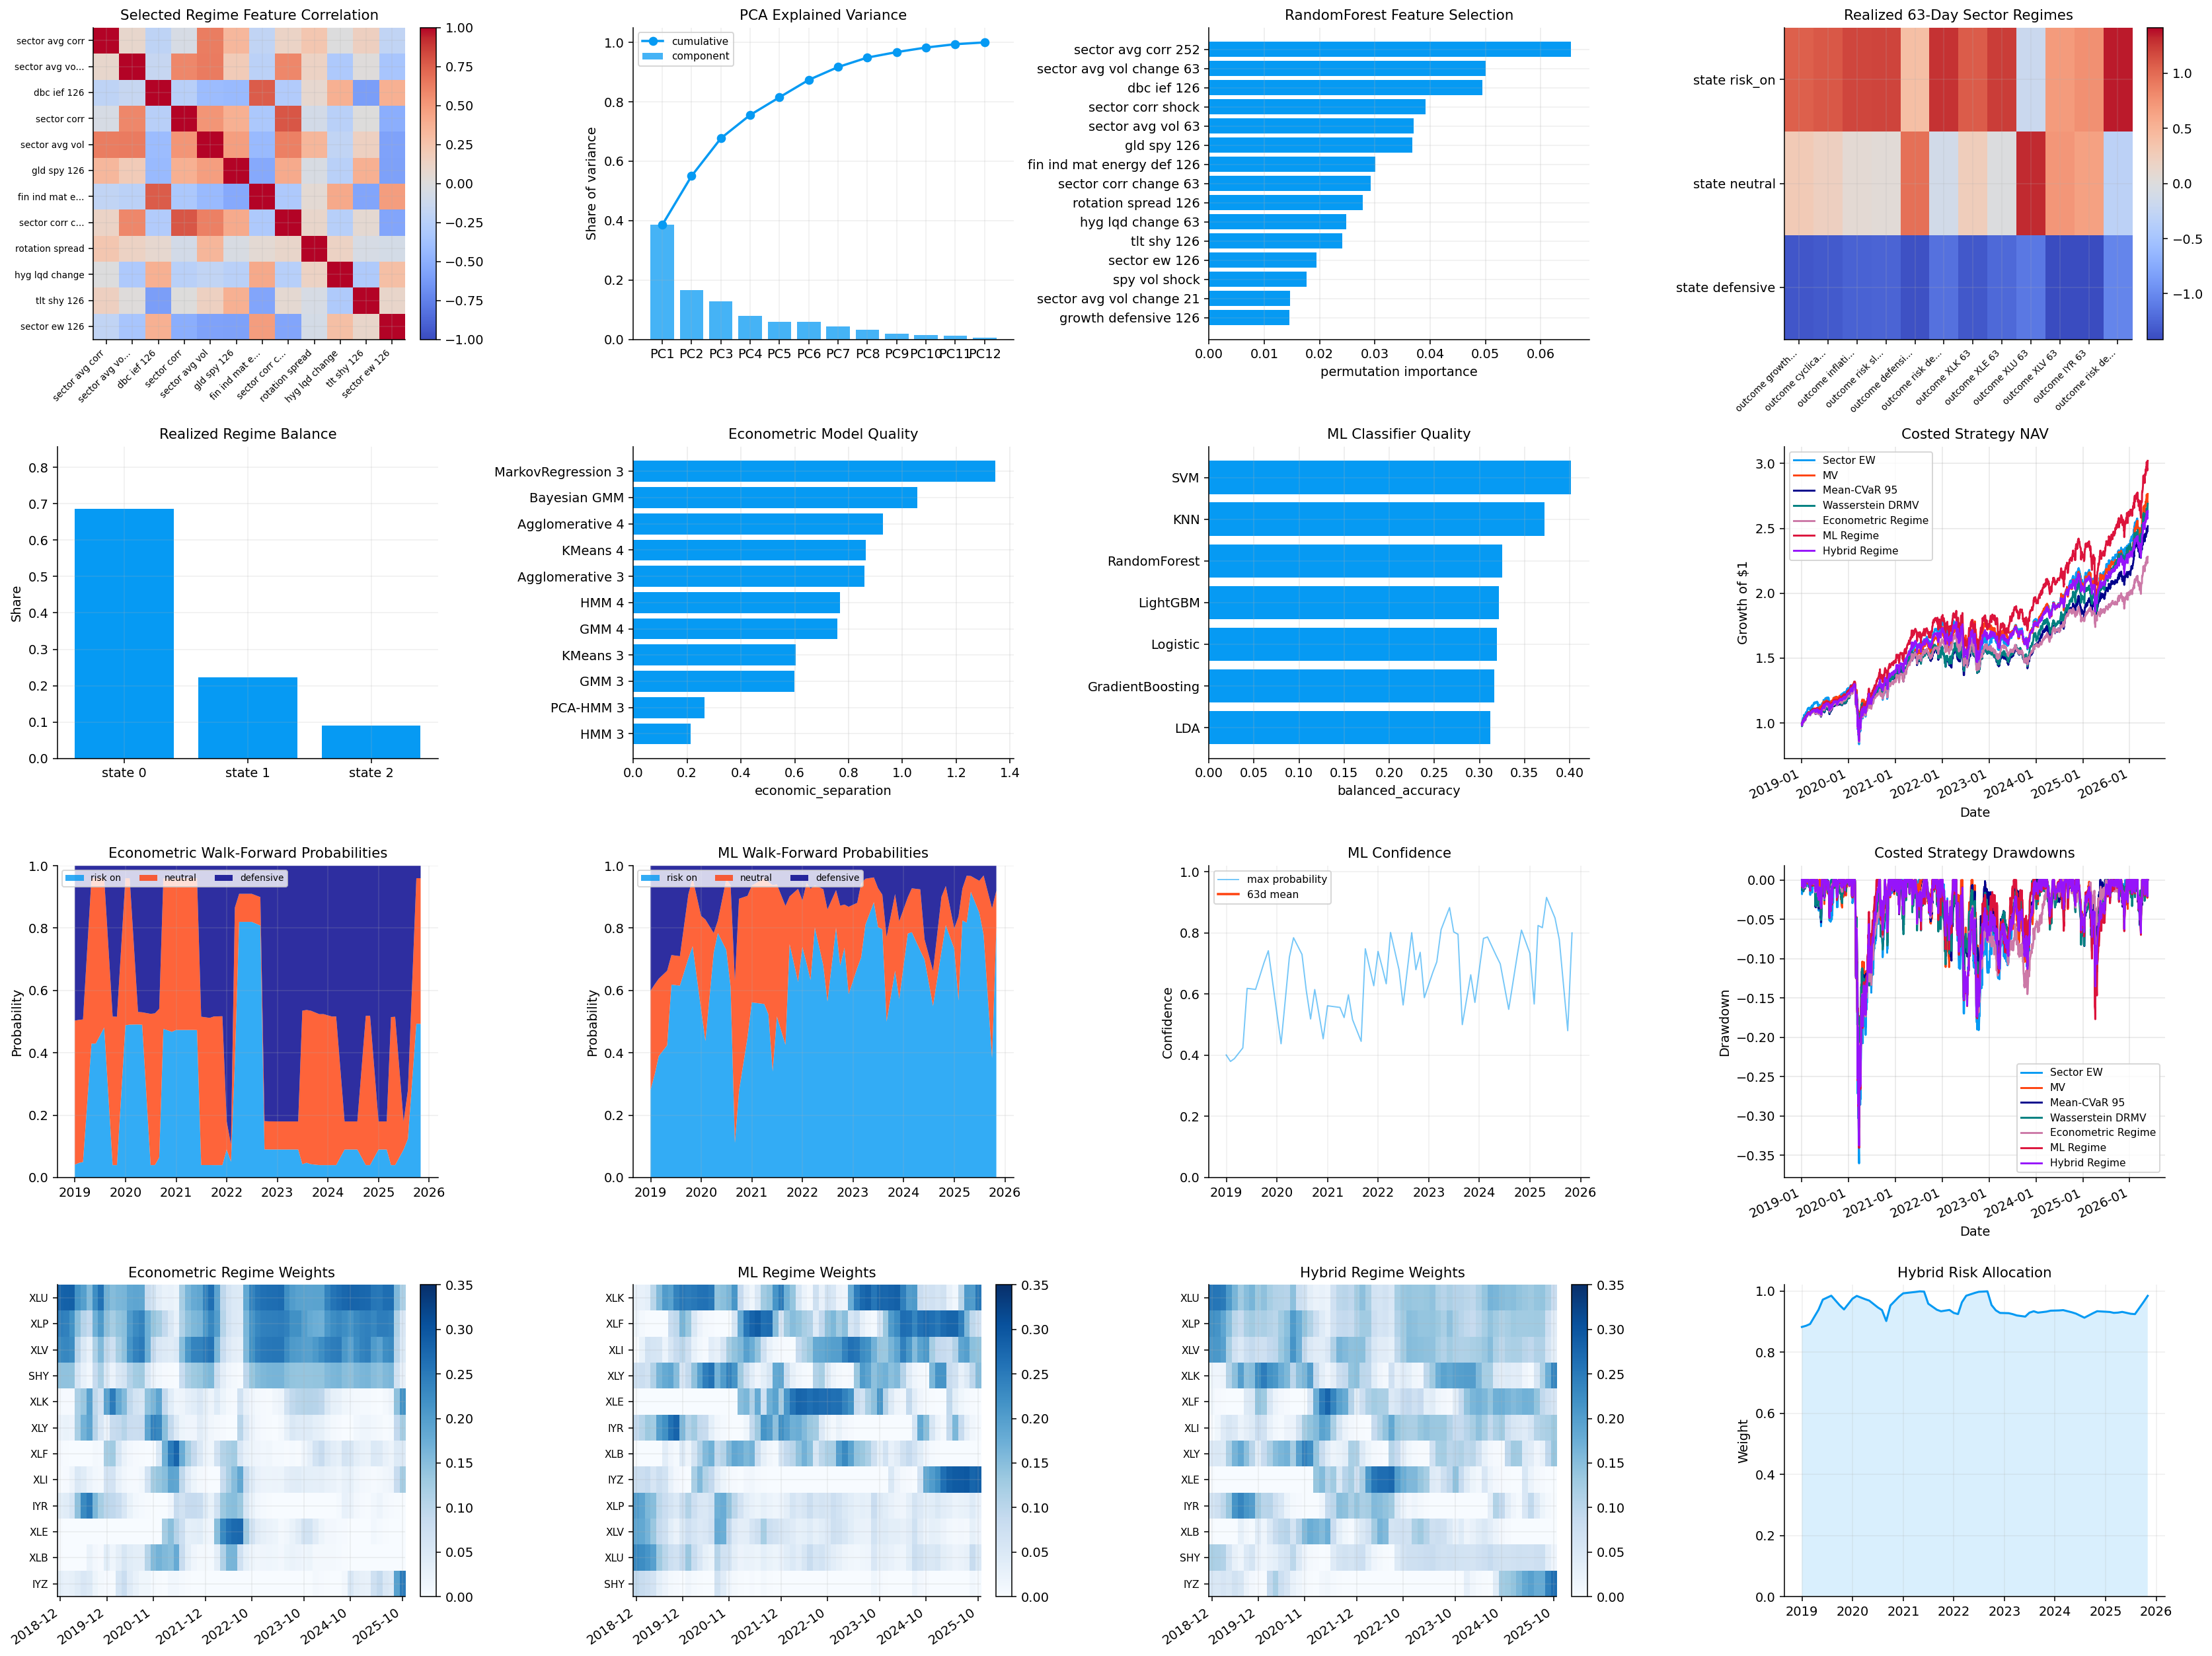

,hist_var5,hist_es5,cf_var5,cf_es5,fhs_var5,fhs_es5
object,,,,,,
Econometric Regime,0.0130,0.0241,0.0132,0.0615,0.0154,0.0228
Hybrid Regime,0.0146,0.0256,0.0146,0.0586,0.0164,0.0238
ML Regime,0.0165,0.0277,0.0166,0.0553,0.0172,0.0250
MV,0.0149,0.0244,0.0138,0.0543,0.0189,0.0264
Mean-CVaR 95,0.0141,0.0245,0.0130,0.0593,0.0142,0.0209
Sector EW,0.0153,0.0271,0.0159,0.0564,0.0107,0.0156
Wasserstein DRMV,0.0147,0.0253,0.0144,0.0559,0.0166,0.0243


breach_count  breach_rate  coverage_error  abs_coverage_error  longest_breach_streak  avg_gap_days  kupiec_p  christoffersen_p  \
object             method                                                                                                                                   
Econometric Regime cf                80       0.0488         -0.0012              0.0012                      3       20.4304    0.8157            0.0057   
                   fhs               93       0.0567          0.0067              0.0067                      2       17.5543    0.2242            0.7423   
                   hist              92       0.0561          0.0061              0.0061                      3       17.7363    0.2685            0.0055   
Hybrid Regime      cf                83       0.0506          0.0006              0.0006                      3       19.6829    0.9145            0.0002   
                   fhs               91       0.0555          0.0055              0.0055                      2       17.9333    0.3188            0.6626   
                   hist              87       0.0530          0.0030              0.0030                      3       18.7674    0.5786            0.0020   
ML Regime          cf                88       0.0536          0.0036              0.0036                      3       18.5517    0.5051            0.0000   
                   fhs               92       0.0561          0.0061              0.0061                      2       17.3516    0.2685            0.4132   
                   hist              93       0.0567          0.0067              0.0067                      3       17.5435    0.2242            0.0006   
MV                 cf                97       0.0591          0.0091              0.0091                      4       16.8125    0.0993            0.0015   
                   fhs               88       0.0536          0.0036              0.0036                      3       18.5517    0.5051            0.1427   
                   hist              92       0.0561          0.0061              0.0061                      4       17.7363    0.2685            0.0001   
Mean-CVaR 95       cf                88       0.0536          0.0036              0.0036                      4       18.5517    0.5051            0.0007   
                   fhs               88       0.0536          0.0036              0.0036                      2       18.5517    0.5051            0.1390   
                   hist              91       0.0555          0.0055              0.0055                      4       17.9333    0.3188            0.0004   
Sector EW          cf                87       0.0530          0.0030              0.0030                      3       18.7674    0.5786            0.0066   
                   fhs               92       0.0561          0.0061              0.0061                      2       17.7473    0.2685            0.1012   
                   hist              85       0.0518          0.0018              0.0018                      3       19.2143    0.7397            0.0013   
Wasserstein DRMV   cf                91       0.0555          0.0055              0.0055                      4       17.9333    0.3188            0.0014   
                   fhs               83       0.0506          0.0006              0.0006                      2       19.2561    0.9145            0.9173   
                   hist              88       0.0536          0.0036              0.0036                      4       18.1494    0.5051            0.0007   

                           quantile_loss  accuracy_rank  accuracy_score  is_best  
object             method                                                         
Econometric Regime cf             0.0013            1.0          0.1429     True  
                   fhs            0.0011            2.0          0.1111    False  
                   hist           0.0013            3.0          0.0909    False  


,object,cum_return,max_dd,worst_day,worst_week
window,,,,,
2022 rates/inflation shock,Econometric Regime,-0.0711,-0.1717,-0.0405,-0.0936
2022 rates/inflation shock,Hybrid Regime,-0.0574,-0.1739,-0.0417,-0.0952
2022 rates/inflation shock,ML Regime,-0.0452,-0.1759,-0.0455,-0.0967
2022 rates/inflation shock,MV,-0.0200,-0.1291,-0.0395,-0.0913
2022 rates/inflation shock,Mean-CVaR 95,-0.0441,-0.1419,-0.0375,-0.0843
2022 rates/inflation shock,Sector EW,-0.1038,-0.1910,-0.0388,-0.0700
2022 rates/inflation shock,Wasserstein DRMV,-0.0403,-0.1449,-0.0362,-0.0778
2023 rebound,Econometric Regime,0.0119,-0.0943,-0.0175,-0.0260
2023 rebound,Hybrid Regime,0.0640,-0.0944,-0.0178,-0.0439


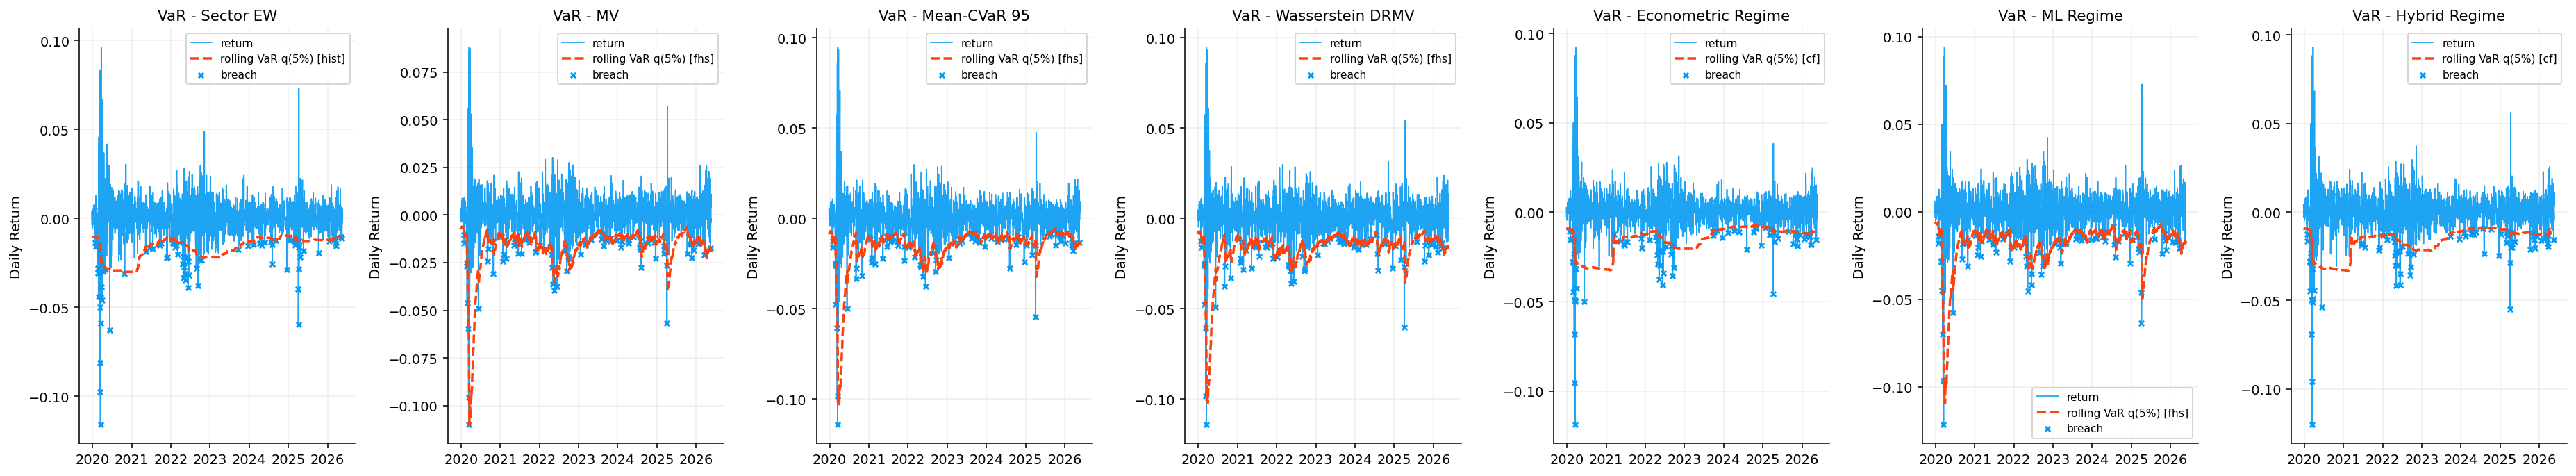

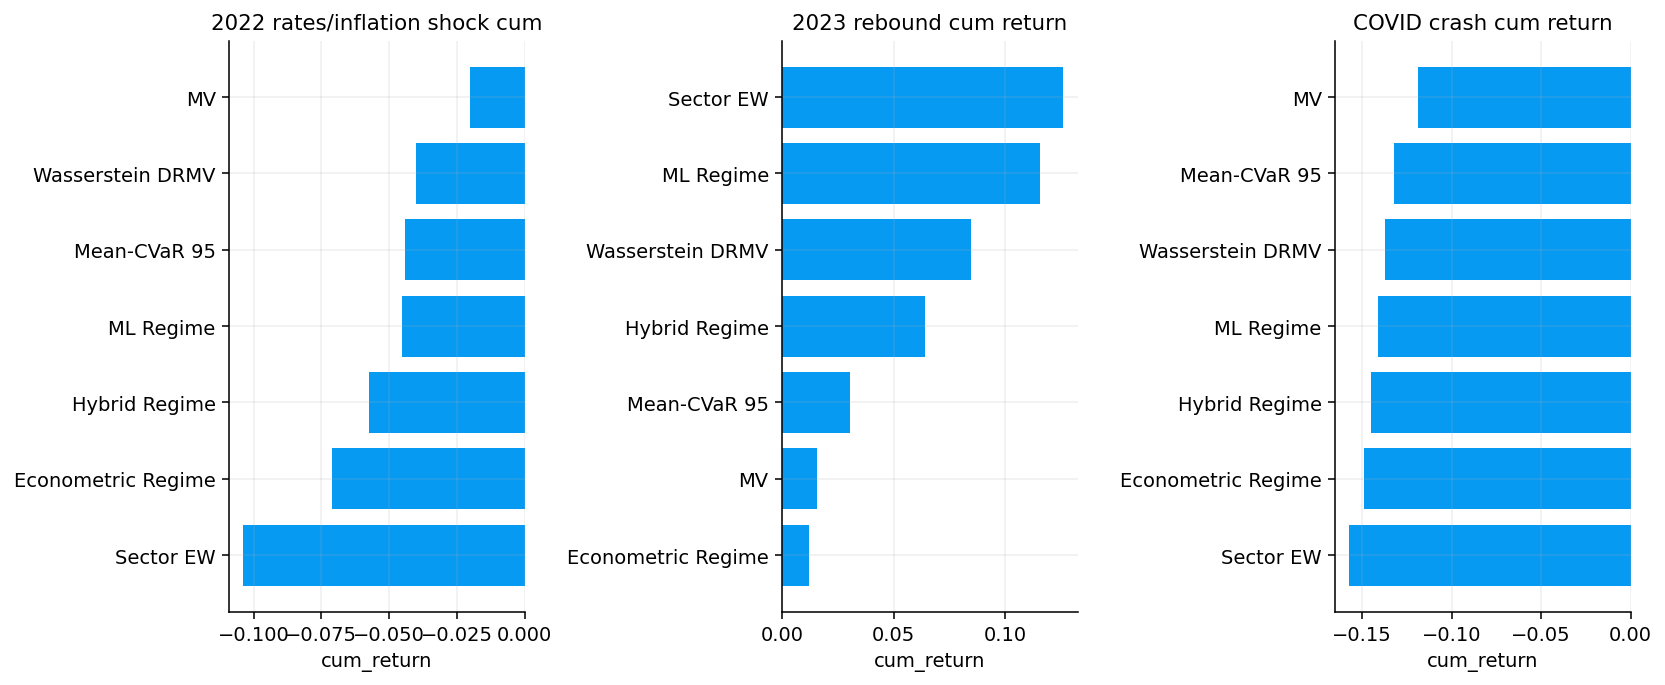

In [85]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.mixture import BayesianGaussianMixture, GaussianMixture
from sklearn.model_selection import TimeSeriesSplit
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

from hmmlearn.hmm import GaussianHMM
try:
    from lightgbm import LGBMClassifier
    lgbm_available = True
except ImportError:
    LGBMClassifier = None
    lgbm_available = False

from quantfinlab.backtest.portfolio import run_many_weights_backtests
from quantfinlab.dataio.panel import load_yfinance_panel, prices_to_returns_panel
from quantfinlab.portfolio import covariance, expected_returns, make_rebalance_dates, optimizers
from quantfinlab.portfolio.cvar import mean_cvar_weight_frame
from quantfinlab.portfolio.robust import wasserstein_weight_frame
from quantfinlab.portfolio.selection import build_strategy_summary, parse_strategy_spec
from quantfinlab.portfolio.walkforward import run_walkforward_grid
from quantfinlab.reports.risk_report import risk_report

from quantfinlab.ml.classifiers import classifier_scores, rf_importance
from quantfinlab.ml.features import (
    breadth,
    dispersion,
    drawdown_change,
    drawdown_level,
    feature_vif,
    future_return,
    pca_tables,
    realized_vol,
    relative_return,
    rolling_avg_corr,
    rolling_pair_corr,
    skip_return,
    total_return,
)
from quantfinlab.ml.regimes import (
    duration_table,
    model_quality_row,
    posterior_confidence,
    posterior_entropy,
    proba_frame,
    regime_separation_score,
    remap_labels,
    sort_states_by_profile,
    state_profile,
    transition_table,
)
from quantfinlab.ml.sequence_models import (
    align_state_probabilities,
    hmm_proba_frame,
    hmm_quality_row,
    pca_hmm_inputs,
)
from quantfinlab.portfolio.regimes import (
    blend_sleeves,
    hybrid_weights,
    regime_asset_scores,
    risky_allocation,
    sleeve_weights,
)

from quantfinlab.plotting.regimes import (
    class_balance,
    confusion,
    feature_corr,
    feature_importance,
    model_quality,
    pca_explained,
    pca_loadings,
    probability_confidence,
    regime_probabilities,
    regime_profiles,
    risky_allocation as risky_allocation_plot,
    weight_heatmap,
)

from quantfinlab.plotting.portfolio import plot_strategy_drawdowns, plot_strategy_nav

data_path = Path("../data")
etf_path = [data_path / "core_cross_asset_etfs.csv", data_path / "sector_etfs.csv"]

feature_tickers = [
    "SPY", "QQQ", "IWM", "EFA", "EEM",
    "VNQ", "DBC", "GLD", "IEF", "TLT",
    "LQD", "HYG", "SHY",
]

sector_tickers = [
    "XLB", "XLE", "XLF", "XLI", "XLK",
    "XLP", "XLU", "XLV", "XLY",
    "IYR", "IYZ",
]

cash_ticker = "SHY"
benchmark_ticker = "SPY"
regime_names = ["risk_on", "neutral", "defensive"]
annualization = 252.0
rf_daily = (1.0 + 0.04) ** (1.0 / annualization) - 1.0
horizon = 63
horizon_slow = 126
tickers = sorted(set(feature_tickers + sector_tickers + [cash_ticker, benchmark_ticker]))

panels = load_yfinance_panel(
    etf_path,
    fields=("close", "volume"),
    tickers=tickers,
    start="2013-01-01",
)

close = panels["close"].ffill(limit=3)
volume = panels["volume"].ffill(limit=3)
ret_d = prices_to_returns_panel(close).fillna(0.0)
close_m = close.resample("ME").last()
ret_m = close_m.pct_change(fill_method=None).dropna(how="all")

feature_close = close[feature_tickers]
feature_ret = ret_d[feature_tickers]
sector_close = close[sector_tickers]
sector_ret_d = ret_d[sector_tickers]
sector_ret_m = ret_m[sector_tickers]
cash_ret_d = ret_d[[cash_ticker]]
spy_ret_d = ret_d[benchmark_ticker]

risk_assets = ["SPY", "QQQ", "IWM", "EFA", "EEM", "VNQ", "HYG"]
defensive_assets = ["IEF", "TLT", "GLD", "SHY"]
cyclical = ["XLB", "XLE", "XLF", "XLI", "XLK", "XLY", "IYR", "IYZ"]
defensive = ["XLP", "XLU", "XLV"]
sector_ew_price = sector_close.mean(axis=1)

x_all = pd.concat(
    {
        "sector_breadth_63": breadth(sector_close, 63),
        "sector_breadth_126": breadth(sector_close, 126),
        "sector_dispersion_21": dispersion(sector_close, 21),
        "sector_dispersion_63": dispersion(sector_close, 63),
        "cyclical_defensive_63": total_return(sector_close[cyclical], 63).mean(axis=1) - total_return(sector_close[defensive], 63).mean(axis=1),
        "cyclical_defensive_126": total_return(sector_close[cyclical], 126).mean(axis=1) - total_return(sector_close[defensive], 126).mean(axis=1),
        "growth_defensive_126": total_return(sector_close[["XLK", "XLY"]], 126).mean(axis=1) - total_return(sector_close[defensive], 126).mean(axis=1),
        "fin_ind_mat_energy_def_126": total_return(sector_close[["XLF", "XLI", "XLB", "XLE"]], 126).mean(axis=1) - total_return(sector_close[defensive], 126).mean(axis=1),
        "technology_vs_sector_126": total_return(sector_close["XLK"], 126) - total_return(sector_ew_price, 126),
        "energy_materials_ief_126": total_return(sector_close[["XLE", "XLB"]], 126).mean(axis=1) - total_return(feature_close["IEF"], 126),
        "real_estate_tlt_126": total_return(sector_close["IYR"], 126) - total_return(feature_close["TLT"], 126),
        "defensive_relative_126": total_return(sector_close[defensive], 126).mean(axis=1) - total_return(sector_ew_price, 126),
        "sector_ew_126": total_return(sector_ew_price, 126),
        "sector_ew_drawdown": drawdown_level(sector_ew_price, 252),
        "sector_ew_dd_speed": drawdown_change(sector_ew_price, 252, 21),
        "sector_avg_vol_63": realized_vol(sector_ret_d, 63).mean(axis=1),
        "sector_avg_vol_change_21": realized_vol(sector_ret_d, 63).mean(axis=1).diff(21),
        "sector_avg_vol_change_63": realized_vol(sector_ret_d, 63).mean(axis=1).diff(63),
        "sector_avg_corr_252": rolling_avg_corr(sector_ret_d, 252),
        "sector_corr_shock": rolling_avg_corr(sector_ret_d, 63) - rolling_avg_corr(sector_ret_d, 252),
        "sector_corr_change_21": rolling_avg_corr(sector_ret_d, 126).diff(21),
        "sector_corr_change_63": rolling_avg_corr(sector_ret_d, 126).diff(63),
        "sector_breadth_speed_21": breadth(sector_close, 63).diff(21),
        "sector_breadth_speed_63": breadth(sector_close, 126).diff(63),
        "leadership_concentration_63": total_return(sector_close, 63).max(axis=1) - total_return(sector_close, 63).median(axis=1),
        "rotation_spread_63": total_return(sector_close, 63).apply(lambda row: row.nlargest(3).mean() - row.nsmallest(3).mean(), axis=1),
        "rotation_spread_126": total_return(sector_close, 126).apply(lambda row: row.nlargest(3).mean() - row.nsmallest(3).mean(), axis=1),
        "spy_252_21": skip_return(feature_close["SPY"], 252, 21),
        "hyg_lqd_126": relative_return(feature_close["HYG"], feature_close["LQD"], 126),
        "hyg_lqd_change_21": relative_return(feature_close["HYG"], feature_close["LQD"], 63).diff(21),
        "hyg_lqd_change_63": relative_return(feature_close["HYG"], feature_close["LQD"], 126).diff(63),
        "tlt_shy_126": relative_return(feature_close["TLT"], feature_close["SHY"], 126),
        "duration_equity_divergence_126": relative_return(feature_close["TLT"], feature_close["SPY"], 126),
        "dbc_ief_126": relative_return(feature_close["DBC"], feature_close["IEF"], 126),
        "gld_spy_126": relative_return(feature_close["GLD"], feature_close["SPY"], 126),
        "spy_vol_shock": realized_vol(feature_ret["SPY"], 21) / realized_vol(feature_ret["SPY"], 126),
        "spy_dd_level": drawdown_level(feature_close["SPY"], 252),
        "spy_dd_speed": drawdown_change(feature_close["SPY"], 252, 21),
    },
    axis=1,
).dropna()

train_end = "2018-12-31"
n_label_states = len(regime_names)
future_63 = future_return(sector_close, horizon)
future_126 = future_return(sector_close, horizon_slow)
cash_future_63 = future_return(close[cash_ticker], horizon)
cash_future_126 = future_return(close[cash_ticker], horizon_slow)

growth_sleeve_63 = future_63[["XLK", "XLY"]].mean(axis=1)
cyclical_sleeve_63 = future_63[["XLF", "XLI", "XLB", "XLE", "IYR", "IYZ"]].mean(axis=1)
inflation_sleeve_63 = future_63[["XLE", "XLB"]].mean(axis=1)
risk_sleeve_63 = pd.concat(
    [growth_sleeve_63, cyclical_sleeve_63, inflation_sleeve_63],
    axis=1,
).max(axis=1)
defensive_sleeve_63 = 0.70 * future_63[defensive].mean(axis=1) + 0.30 * cash_future_63
spread_63 = risk_sleeve_63 - defensive_sleeve_63

growth_sleeve_126 = future_126[["XLK", "XLY"]].mean(axis=1)
cyclical_sleeve_126 = future_126[["XLF", "XLI", "XLB", "XLE", "IYR", "IYZ"]].mean(axis=1)
inflation_sleeve_126 = future_126[["XLE", "XLB"]].mean(axis=1)
risk_sleeve_126 = pd.concat(
    [growth_sleeve_126, cyclical_sleeve_126, inflation_sleeve_126],
    axis=1,
).max(axis=1)
defensive_sleeve_126 = 0.70 * future_126[defensive].mean(axis=1) + 0.30 * cash_future_126
spread_126 = risk_sleeve_126 - defensive_sleeve_126

y_future = pd.concat(
    [
        future_63.add_suffix("_63"),
        future_126.add_suffix("_126"),
        growth_sleeve_63.rename("growth_sleeve_63"),
        cyclical_sleeve_63.rename("cyclical_sleeve_63"),
        inflation_sleeve_63.rename("inflation_sleeve_63"),
        risk_sleeve_63.rename("risk_sleeve_63"),
        defensive_sleeve_63.rename("defensive_sleeve_63"),
        spread_63.rename("risk_defensive_spread_63"),
        growth_sleeve_126.rename("growth_sleeve_126"),
        cyclical_sleeve_126.rename("cyclical_sleeve_126"),
        inflation_sleeve_126.rename("inflation_sleeve_126"),
        risk_sleeve_126.rename("risk_sleeve_126"),
        defensive_sleeve_126.rename("defensive_sleeve_126"),
        spread_126.rename("risk_defensive_spread_126"),
    ],
    axis=1,
).dropna()

common_index = x_all.index.intersection(y_future.index)
x_all = x_all.loc[common_index]
y_future = y_future.loc[common_index]

y = pd.Series(1, index=y_future.index, name="realized_regime")
y.loc[y_future["risk_defensive_spread_63"] > 0.025] = 0
y.loc[y_future["risk_defensive_spread_63"] < -0.025] = 2

y_slow = pd.Series(1, index=y_future.index, name="slow_regime")
y_slow.loc[y_future["risk_defensive_spread_126"] > 0.05] = 0
y_slow.loc[y_future["risk_defensive_spread_126"] < -0.05] = 2

stress_label = (
    (y_future["risk_defensive_spread_63"] < -0.06)
    | (future_63.mean(axis=1).reindex(y_future.index) < -0.10)
).astype(int).rename("stress_63")

profile = state_profile(y_future, y, y_future)
profile.index = regime_names

x_train_all = x_all.loc[:train_end]
y_train_all = y.loc[x_train_all.index]

rf_for_importance = RandomForestClassifier(
    n_estimators=500,
    max_depth=5,
    min_samples_leaf=25,
    random_state=42,
    n_jobs=1,
)
rf_for_importance.fit(x_train_all, y_train_all)

imp = rf_importance(
    rf_for_importance,
    x_train_all,
    y_train_all,
    n_repeats=8,
    random_state=42,
)

model_features = imp.head(12).index.tolist()
def selected_feature_transform(x, min_history=252, clip=4.0):
    base = x.replace([np.inf, -np.inf], np.nan).astype(float)
    mean = base.expanding(min_periods=int(min_history)).mean().shift(1)
    std = base.expanding(min_periods=int(min_history)).std(ddof=1).shift(1).replace(0.0, np.nan)
    out = ((base - mean) / std).clip(-float(clip), float(clip))
    return out

x_raw = selected_feature_transform(x_all[model_features]).dropna(how="any")
common_index = x_raw.index.intersection(y.index)
x_raw = x_raw.loc[common_index]
y = y.loc[common_index].astype(int)
y_slow = y_slow.loc[common_index].astype(int)
stress_label = stress_label.loc[common_index].astype(int)
y_future = y_future.loc[common_index]
vif = feature_vif(x_raw)
pca_info, pca_loading = pca_tables(x_raw)

scaler = StandardScaler()
z = pd.DataFrame(
    scaler.fit_transform(x_raw),
    index=x_raw.index,
    columns=x_raw.columns,
)

kmeans_3 = KMeans(n_clusters=3, n_init=50, random_state=42).fit(z)
kmeans_4 = KMeans(n_clusters=4, n_init=50, random_state=42).fit(z)

agg_3 = AgglomerativeClustering(n_clusters=3, linkage="ward").fit(z)
agg_4 = AgglomerativeClustering(n_clusters=4, linkage="ward").fit(z)

gmm_3 = GaussianMixture(n_components=3, covariance_type="diag", n_init=10, random_state=42, reg_covar=1e-5).fit(z)
gmm_4 = GaussianMixture(n_components=4, covariance_type="diag", n_init=10, random_state=42, reg_covar=1e-5).fit(z)

bgmm = BayesianGaussianMixture(
    n_components=6,
    covariance_type="diag",
    weight_concentration_prior_type="dirichlet_process",
    weight_concentration_prior=0.25,
    random_state=42,
).fit(z)

ew_ret = sector_ret_d.mean(axis=1).reindex(z.index).dropna() * 100.0
ms_fit = None
try:
    ms_model = MarkovRegression(
        ew_ret,
        k_regimes=3,
        trend="c",
        switching_variance=True,
    )
    ms_fit = ms_model.fit(search_reps=10, em_iter=8, maxiter=100, disp=False)
except Exception as exc:
    print("MarkovRegression skipped:", exc)

hmm_3 = GaussianHMM(n_components=3, covariance_type="diag", n_iter=250, random_state=42, min_covar=1e-4).fit(z)
hmm_4 = GaussianHMM(n_components=4, covariance_type="diag", n_iter=250, random_state=42, min_covar=1e-4).fit(z)

z_pca, pca_scaler, pca = pca_hmm_inputs(z, n_components=min(5, z.shape[1]), random_state=42)
pca_hmm_3 = GaussianHMM(n_components=n_label_states, covariance_type="diag", n_iter=250, random_state=42, min_covar=1e-4).fit(z_pca)

eco_rows = []
eco_rows.append(model_quality_row("KMeans 3", z, kmeans_3.labels_, outcomes=y_future))
eco_rows.append(model_quality_row("KMeans 4", z, kmeans_4.labels_, outcomes=y_future))
eco_rows.append(model_quality_row("Agglomerative 3", z, agg_3.labels_, outcomes=y_future))
eco_rows.append(model_quality_row("Agglomerative 4", z, agg_4.labels_, outcomes=y_future))
eco_rows.append(model_quality_row("GMM 3", z, gmm_3.predict(z), proba=gmm_3.predict_proba(z), outcomes=y_future, likelihood=gmm_3.score(z) * len(z), bic=gmm_3.bic(z), aic=gmm_3.aic(z)))
eco_rows.append(model_quality_row("GMM 4", z, gmm_4.predict(z), proba=gmm_4.predict_proba(z), outcomes=y_future, likelihood=gmm_4.score(z) * len(z), bic=gmm_4.bic(z), aic=gmm_4.aic(z)))
eco_rows.append(model_quality_row("Bayesian GMM", z, bgmm.predict(z), proba=bgmm.predict_proba(z), outcomes=y_future, likelihood=bgmm.score(z) * len(z)))
if ms_fit is not None:
    p_ms = pd.DataFrame(np.asarray(ms_fit.smoothed_marginal_probabilities), index=ew_ret.index)
    lab_ms = p_ms.idxmax(axis=1).astype(int)
    eco_rows.append(model_quality_row("MarkovRegression 3", z.loc[lab_ms.index], lab_ms, proba=p_ms, outcomes=y_future, likelihood=ms_fit.llf, bic=ms_fit.bic, aic=ms_fit.aic))
eco_rows.append(hmm_quality_row("HMM 3", hmm_3, z, outcomes=y_future))
eco_rows.append(hmm_quality_row("HMM 4", hmm_4, z, outcomes=y_future))
eco_rows.append(hmm_quality_row("PCA-HMM 3", pca_hmm_3, z_pca, outcomes=y_future))

eco_table = pd.DataFrame(eco_rows).set_index("model")
display(eco_table.round(4))

supervised_train = z.loc[:train_end]
supervised_test = z.loc[train_end:].iloc[1:]
y_train = y.loc[supervised_train.index]
y_test = y.loc[supervised_test.index]
class_labels = sorted(y.unique())

logit = LogisticRegression(max_iter=2000, class_weight="balanced").fit(supervised_train, y_train)
lda = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto").fit(supervised_train, y_train)
rf = RandomForestClassifier(n_estimators=420, max_depth=5, min_samples_leaf=25, class_weight="balanced", random_state=42, n_jobs=1).fit(supervised_train, y_train)
gb = GradientBoostingClassifier(n_estimators=240, learning_rate=0.035, max_depth=2, min_samples_leaf=25, random_state=42).fit(supervised_train, y_train)
svm = SVC(C=2.0, gamma="scale", probability=True, class_weight="balanced", random_state=42).fit(supervised_train, y_train)
knn = KNeighborsClassifier(n_neighbors=25, weights="distance").fit(supervised_train, y_train)

classifiers = {
    "Logistic": logit,
    "LDA": lda,
    "RandomForest": rf,
    "GradientBoosting": gb,
    "SVM": svm,
    "KNN": knn,
}
if lgbm_available:
    lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.03, num_leaves=15, min_child_samples=45, subsample=0.8, colsample_bytree=0.8, objective="multiclass", random_state=42, verbosity=-1, n_jobs=1).fit(supervised_train, y_train)
    classifiers["LightGBM"] = lgbm

ml_table = classifier_scores(classifiers, supervised_test, y_test, labels=class_labels)
display(ml_table.round(4))

hmm_candidates = eco_table.loc[eco_table.index.to_series().str.contains("HMM", regex=False)].copy()
eligible = hmm_candidates[
    hmm_candidates["states"].eq(n_label_states)
    & hmm_candidates["min_state_share"].ge(0.03)
    & hmm_candidates["avg_state_duration"].ge(4.0)
].copy()
if eligible.empty:
    eligible = eco_table[
        eco_table.index.to_series().str.contains("HMM|GMM|Markov", regex=True)
        & eco_table["states"].eq(n_label_states)
        & eco_table["min_state_share"].ge(0.03)
        & eco_table["avg_state_duration"].ge(4.0)
    ].copy()
if eligible.empty:
    eligible = eco_table[eco_table["states"].eq(n_label_states)].copy()
if eligible.empty:
    eligible = eco_table.copy()

best_eco_name = (
    1.60 * eligible["economic_separation"].rank(pct=True)
    + 1.10 * eligible["avg_state_duration"].rank(pct=True)
    + 0.70 * eligible["silhouette"].fillna(0.0).rank(pct=True)
    + 0.50 * eligible["posterior_confidence"].fillna(0.0).rank(pct=True)
    - 0.45 * eligible["transitions_per_year"].rank(pct=True)
    - 0.25 * eligible["posterior_entropy"].fillna(0.0).rank(pct=True)
).sort_values(ascending=False).index[0]

def classifier_economic_utility(model):
    if hasattr(model, "predict_proba"):
        raw = model.predict_proba(supervised_test)
        proba = pd.DataFrame(0.0, index=supervised_test.index, columns=range(n_label_states))
        for j, cls in enumerate(model.classes_):
            proba[int(cls)] = raw[:, j]
    else:
        pred = pd.Series(model.predict(supervised_test), index=supervised_test.index)
        proba = pd.get_dummies(pred).reindex(index=supervised_test.index, columns=range(n_label_states), fill_value=0.0)
    p = proba.rename(columns=dict(enumerate(regime_names)))
    fwd = y_future.reindex(supervised_test.index)
    sector_beta = fwd["risk_defensive_spread_63"]
    signal = p["risk_on"] - p["defensive"]
    r = (signal * sector_beta).replace([np.inf, -np.inf], np.nan).dropna()
    return np.sqrt(12.0) * r.mean() / r.std(ddof=1) if r.std(ddof=1) > 1e-12 else 0.0

ml_rank = ml_table.copy()
ml_rank["economic_utility_raw"] = pd.Series({name: classifier_economic_utility(model) for name, model in classifiers.items()})
ml_rank["economic_utility_score"] = 0.30 * ml_rank["economic_utility_raw"].rank(pct=True)
ml_rank["log_loss_bad_rank"] = ml_rank["log_loss"].replace(np.nan, ml_rank["log_loss"].max() + 1.0).rank(pct=True, ascending=True)
ml_rank["selection_score"] = (
    0.40 * ml_rank["balanced_accuracy"]
    + 0.30 * ml_rank["macro_f1"]
    - 0.30 * ml_rank["log_loss_bad_rank"]
    + ml_rank["economic_utility_score"]
)
ml_table = ml_rank
best_ml_name = ml_table["selection_score"].sort_values(ascending=False).index[0]

best_ml_template = classifiers[best_ml_name]
print("best econometric:", best_eco_name)
print("best ML:", best_ml_name)

def shrink_probability(p, base=0.10):
    p = pd.Series(p, dtype=float).reindex(regime_names).fillna(0.0)
    p = p / p.sum() if p.sum() > 1e-12 else pd.Series(1.0 / len(regime_names), index=regime_names)
    confidence = float(p.max())
    shrink = base + (0.15 if confidence > 0.98 else 0.0)
    uniform = pd.Series(1.0 / len(regime_names), index=regime_names)
    out = (1.0 - shrink) * p + shrink * uniform
    return out / out.sum()

def economic_state_mapping(labels, train_x):
    labels = pd.Series(labels, index=train_x.index)
    known_index = train_x.index[:-horizon] if len(train_x) > horizon else train_x.index
    known_outcomes = y_future.reindex(known_index).dropna(how="any")
    known_labels = labels.reindex(known_outcomes.index).dropna()
    common = known_outcomes.index.intersection(known_labels.index)
    if len(common) >= 60 and known_labels.loc[common].nunique() >= 2:
        prof = state_profile(train_x.reindex(common), known_labels.loc[common], known_outcomes.loc[common])
    else:
        prof = state_profile(train_x, labels)
    order = list(sort_states_by_profile(prof))
    if not order:
        return {}
    mapping = {int(s): "neutral" for s in order}
    mapping[int(order[0])] = "risk_on"
    mapping[int(order[-1])] = "defensive"
    return mapping

def fit_eco_model(name, train_x):
    sc = StandardScaler().fit(train_x)
    z_train = pd.DataFrame(sc.transform(train_x), index=train_x.index, columns=train_x.columns)
    out = {"name": name, "scaler": sc, "train_z": z_train, "pca": None, "pca_scaler": None}
    if str(name).startswith("PCA-HMM"):
        n_states = int(str(name).split()[-1]) if str(name).split()[-1].isdigit() else n_label_states
        z_fit, pca_scaler_t, pca_t = pca_hmm_inputs(z_train, n_components=min(5, z_train.shape[1]), random_state=42)
        model = GaussianHMM(n_components=n_states, covariance_type="diag", n_iter=200, random_state=42, min_covar=1e-4).fit(z_fit)
        labels = pd.Series(model.predict(z_fit), index=train_x.index)
        out.update({"model": model, "pca": pca_t, "pca_scaler": pca_scaler_t, "train_fit": z_fit, "mapping": economic_state_mapping(labels, train_x)})
        return out
    if str(name).startswith("HMM"):
        n_states = int(str(name).split()[1])
        model = GaussianHMM(n_components=n_states, covariance_type="diag", n_iter=200, random_state=42, min_covar=1e-4).fit(z_train)
        labels = pd.Series(model.predict(z_train), index=train_x.index)
        out.update({"model": model, "train_fit": z_train, "mapping": economic_state_mapping(labels, train_x)})
        return out
    if str(name).startswith("GMM 3"):
        model = GaussianMixture(n_components=3, covariance_type="diag", n_init=5, random_state=42, reg_covar=1e-5).fit(z_train)
    elif str(name).startswith("Bayesian"):
        model = BayesianGaussianMixture(n_components=6, covariance_type="diag", max_iter=300, weight_concentration_prior=0.25, random_state=42).fit(z_train)
    else:
        model = GaussianMixture(n_components=4, covariance_type="diag", n_init=5, random_state=42, reg_covar=1e-5).fit(z_train)
    labels = pd.Series(model.predict(z_train), index=train_x.index)
    out.update({"model": model, "train_fit": z_train, "mapping": economic_state_mapping(labels, train_x)})
    return out

def eco_probability(fitted, last_x):
    z_last = pd.DataFrame(fitted["scaler"].transform(last_x), index=last_x.index, columns=last_x.columns)
    if str(fitted["name"]).startswith("PCA-HMM"):
        z_last, _, _ = pca_hmm_inputs(
            z_last,
            n_components=fitted["train_fit"].shape[1],
            scaler=fitted["pca_scaler"],
            pca=fitted["pca"],
        )
        seq = pd.concat([fitted["train_fit"], z_last], axis=0)
        raw = hmm_proba_frame(fitted["model"], seq, index=seq.index).iloc[-1].to_numpy()
    elif str(fitted["name"]).startswith("HMM"):
        seq = pd.concat([fitted["train_fit"], z_last], axis=0)
        raw = hmm_proba_frame(fitted["model"], seq, index=seq.index).iloc[-1].to_numpy()
    else:
        raw = fitted["model"].predict_proba(z_last)[0]
    p = pd.Series(0.0, index=regime_names)
    for i, val in enumerate(raw):
        p[fitted.get("mapping", {}).get(int(i), "neutral")] += float(val)
    return shrink_probability(p, base=0.12)

def make_calibrated_model(name):
    return clone(best_ml_template)

def ml_probability(model, last_x):
    p = pd.Series(0.0, index=regime_names)
    raw = model.predict_proba(last_x)[0] if hasattr(model, "predict_proba") else np.array([1.0])
    classes = model.classes_ if hasattr(model, "classes_") else np.array([model.predict(last_x)[0]])
    for cls, val in zip(classes, raw, strict=False):
        p[regime_names[int(cls)]] = float(val)
    return shrink_probability(p, base=0.06)

def stress_probability(model, last_x):
    if model is None:
        return 0.0
    raw = model.predict_proba(last_x)[0]
    classes = list(model.classes_)
    return float(raw[classes.index(1)]) if 1 in classes else 0.0

def blend_horizons(p_fast, p_slow, p_stress):
    p = shrink_probability(0.65 * p_fast + 0.35 * p_slow, base=0.03)
    defensive_floor = 0.85 * float(p_stress)
    if defensive_floor > p["defensive"]:
        p["defensive"] = defensive_floor
        remaining = max(1.0 - p["defensive"], 0.0)
        nondef = p[["risk_on", "neutral"]]
        if nondef.sum() > 1e-12:
            p.loc[["risk_on", "neutral"]] = remaining * nondef / nondef.sum()
        else:
            p.loc[["risk_on", "neutral"]] = remaining / 2.0
    return p / p.sum()

rebalance_dates = close_m.index
rebalance_dates = rebalance_dates[rebalance_dates >= "2018-12-31"]
p_eco_rows = {}
p_ml_rows = {}
eco_fit = None
ml_fit = None

for i, dt in enumerate(rebalance_dates):
    if dt not in x_raw.index:
        pos = x_raw.index.searchsorted(dt, side="right") - 1
        if pos < 0:
            continue
        dt = x_raw.index[pos]
    train_x = x_raw.loc[:dt].tail(1260)
    if len(train_x) < 1000:
        continue
    pos = x_raw.index.searchsorted(dt, side="right") - 1
    if pos <= horizon_slow:
        continue
    label_cutoff = x_raw.index[max(0, pos - horizon)]
    slow_cutoff = x_raw.index[max(0, pos - horizon_slow)]
    train_idx = y.loc[:label_cutoff].tail(len(train_x)).index
    slow_idx = y_slow.loc[:slow_cutoff].tail(len(train_x)).index
    stress_idx = stress_label.loc[:label_cutoff].tail(len(train_x)).index
    train_x_ml = x_raw.loc[train_idx]
    train_y = y.loc[train_idx]
    if train_y.nunique() < 2:
        continue
    if eco_fit is None or i % 3 == 0:
        eco_fit = fit_eco_model(best_eco_name, train_x)
    p_eco_rows[pd.Timestamp(dt)] = eco_probability(eco_fit, x_raw.loc[[dt]])
    if ml_fit is None or i % 3 == 0:
        sc_t = StandardScaler().fit(train_x_ml)
        z_train = pd.DataFrame(sc_t.transform(train_x_ml), index=train_x_ml.index, columns=train_x_ml.columns)
        model_t = make_calibrated_model(best_ml_name)
        try:
            model_t.fit(z_train, train_y)
        except Exception:
            model_t = clone(best_ml_template).fit(z_train, train_y)

        model_slow = None
        if len(slow_idx) >= 756 and y_slow.loc[slow_idx].nunique() > 1:
            z_slow = pd.DataFrame(sc_t.transform(x_raw.loc[slow_idx]), index=slow_idx, columns=x_raw.columns)
            model_slow = make_calibrated_model(best_ml_name)
            try:
                model_slow.fit(z_slow, y_slow.loc[slow_idx])
            except Exception:
                model_slow = clone(best_ml_template).fit(z_slow, y_slow.loc[slow_idx])

        stress_model = None
        if len(stress_idx) >= 756 and stress_label.loc[stress_idx].nunique() > 1:
            z_stress = pd.DataFrame(sc_t.transform(x_raw.loc[stress_idx]), index=stress_idx, columns=x_raw.columns)
            stress_base = RandomForestClassifier(
                n_estimators=350,
                min_samples_leaf=25,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=1,
            )
            stress_model = stress_base.fit(z_stress, stress_label.loc[stress_idx])

        ml_fit = {"scaler": sc_t, "model": model_t, "model_slow": model_slow, "stress_model": stress_model}
    z_last = pd.DataFrame(ml_fit["scaler"].transform(x_raw.loc[[dt]]), index=[dt], columns=x_raw.columns)
    p_fast = ml_probability(ml_fit["model"], z_last)
    p_slow = ml_probability(ml_fit["model_slow"], z_last) if ml_fit["model_slow"] is not None else p_fast
    p_stress = stress_probability(ml_fit["stress_model"], z_last)
    p_ml_rows[pd.Timestamp(dt)] = blend_horizons(p_fast, p_slow, p_stress)

p_eco = pd.DataFrame.from_dict(p_eco_rows, orient="index").sort_index()
p_ml = pd.DataFrame.from_dict(p_ml_rows, orient="index").sort_index()
rebalance = p_eco.index.intersection(p_ml.index).intersection(sector_ret_m.index)
p_eco = p_eco.loc[rebalance]
p_ml = p_ml.loc[rebalance]

ret_for_backtest = pd.concat([sector_ret_d, cash_ret_d], axis=1).fillna(0.0)

w_equal = pd.DataFrame(1.0 / len(sector_tickers), index=rebalance, columns=sector_tickers)
w_equal[cash_ticker] = 0.0

benchmark_cov_lookback = 756
benchmark_mu_lookback = 252
benchmark_ewma_lambda = 0.97
benchmark_w_min = 0.0
benchmark_w_max = 0.40
benchmark_mv_lambda = 6.0
benchmark_alt_mv_lambda = 3.0
benchmark_cov_models = {
    "LedoitWolf": covariance.ledoit_wolf_covariance,
    "OAS": covariance.oas_covariance,
    "EWMA": covariance.ewma_covariance,
}
benchmark_mu_models = {
    "Momentum": expected_returns.momentum_mu,
    "BayesStein": expected_returns.bayes_stein_mu,
    "BayesSteinMomentum": expected_returns.bayes_stein_momentum_mu,
}

universe_by_date = {
    pd.Timestamp(dt): {"tickers": list(sector_tickers), "avg_dollar_volume": pd.Series(1.0, index=sector_tickers)}
    for dt in rebalance
}

mv_grid = run_walkforward_grid(
    returns=ret_for_backtest[sector_tickers],
    close=sector_close,
    rebalance_dates=rebalance,
    universe_by_date=universe_by_date,
    cov_models=benchmark_cov_models,
    mu_models=benchmark_mu_models,
    optimizers={
        "MV": optimizers.mean_variance,
        "MaxSharpe": optimizers.max_sharpe_slsqp,
    },
    strategy_specs=[
        {"name": f"{optimizer_name} ({cov_name}, {mu_name})", "optimizer": optimizer_name, "cov_model": cov_name, "mu_model": mu_name}
        for optimizer_name in ["MV", "MaxSharpe"]
        for cov_name in benchmark_cov_models
        for mu_name in benchmark_mu_models
    ],
    max_weight=benchmark_w_max,
    min_weight=benchmark_w_min,
    trading_cost_bps=10,
    turnover_penalty_bps=10,
    cov_lookback=benchmark_cov_lookback,
    mu_lookback=benchmark_mu_lookback,
    min_cov_observations=benchmark_cov_lookback - 1,
    min_mu_observations=benchmark_mu_lookback - 1,
    fallback="equal",
    annualization=annualization,
    rf_daily=rf_daily,
    ewma_lambda=benchmark_ewma_lambda,
    optimizer_params={"MV": {"mv_lambda": benchmark_mv_lambda}},
)

mv_pick = mv_grid.results[
    mv_grid.results["Optimizer"].eq("MV")
].sort_values(
    ["Sharpe", "Max Drawdown", "Turnover"],
    ascending=[False, False, True],
).index[0]

maxsharpe_candidates = mv_grid.results[
    mv_grid.results["Optimizer"].eq("MaxSharpe")
].dropna(subset=["Sharpe"])
maxsharpe_source = (
    maxsharpe_candidates.sort_values(
        ["Sharpe", "Max Drawdown", "Turnover", "CAGR"],
        ascending=[False, False, True, False],
    ).index[0]
    if not maxsharpe_candidates.empty
    else mv_pick
)

w_mv = mv_grid.weights[mv_pick].copy()
w_mv[cash_ticker] = 0.0
w_mv = w_mv.reindex(index=rebalance, columns=sector_tickers + [cash_ticker]).fillna(0.0)

_, maxsharpe_mu_model, maxsharpe_cov_model = parse_strategy_spec(maxsharpe_source, mv_grid.backtests[maxsharpe_source])

def align_benchmark_weights(w):
    out = w.reindex(index=rebalance, columns=sector_tickers).ffill()
    out = out.fillna(1.0 / len(sector_tickers))
    out[cash_ticker] = 0.0
    return out.reindex(columns=sector_tickers + [cash_ticker]).fillna(0.0)

w_mean_cvar = align_benchmark_weights(
    mean_cvar_weight_frame(
        cache=mv_grid.cache,
        rebalance_dates=rebalance,
        cov_model=maxsharpe_cov_model,
        mu_model=maxsharpe_mu_model,
        reference="equal",
        alpha=0.95,
        budget_scale=0.90,
        w_min=benchmark_w_min,
        w_max=benchmark_w_max,
    )
)

w_wasserstein = align_benchmark_weights(
    wasserstein_weight_frame(
        cache=mv_grid.cache,
        rebalance_dates=rebalance,
        cov_model=maxsharpe_cov_model,
        mu_model=maxsharpe_mu_model,
        radius=0.10,
        mv_lambda=benchmark_alt_mv_lambda,
        w_min=benchmark_w_min,
        w_max=benchmark_w_max,
    )
)

neutral_weight = pd.Series(1.0 / len(sector_tickers), index=sector_tickers + [cash_ticker])
neutral_weight[cash_ticker] = 0.0

def defensive_weight():
    w = pd.Series(0.0, index=sector_tickers + [cash_ticker])
    for ticker, weight in {"SHY": 0.30, "XLU": 0.25, "XLP": 0.22, "XLV": 0.23}.items():
        if ticker in w.index:
            w[ticker] = weight
    return w

def regime_risk_budget(p):
    p = pd.Series(p, dtype=float).reindex(regime_names).fillna(0.0)
    p = p / p.sum() if p.sum() > 1e-12 else pd.Series(1.0 / len(regime_names), index=regime_names)
    entropy = -(p * np.log(p + 1e-12)).sum() / np.log(len(p))
    risk = 0.92 + 0.50 * p["risk_on"] - 0.72 * p["defensive"] - 0.08 * entropy
    return float(np.clip(risk, 0.45, 1.00))

def normalize_target(w):
    out = w.reindex(sector_tickers + [cash_ticker]).fillna(0.0).astype(float)
    out[cash_ticker] = max(1.0 - float(out[sector_tickers].sum()), 0.0)
    return out / float(out.sum()) if float(out.sum()) > 1e-12 else neutral_weight.copy()

def smooth_schedule(w, alpha=0.50):
    rows = []
    prev = None
    for dt, row in w.iterrows():
        target = row.reindex(sector_tickers + [cash_ticker]).fillna(0.0).astype(float)
        target = target / float(target.sum()) if float(target.sum()) > 1e-12 else neutral_weight.copy()
        cur = target if prev is None else alpha * target + (1.0 - alpha) * prev
        cur = cur / float(cur.sum()) if float(cur.sum()) > 1e-12 else neutral_weight.copy()
        rows.append(cur.rename(dt))
        prev = cur
    return pd.DataFrame(rows)

sector_trend_63 = sector_close / sector_close.shift(63) - 1.0
sector_trend_126 = sector_close / sector_close.shift(126) - 1.0
sector_trend_252_21 = sector_close.shift(21) / sector_close.shift(252) - 1.0
sector_vol_126 = sector_ret_d.rolling(126).std(ddof=1) * np.sqrt(annualization)
sector_dd_252 = sector_close / sector_close.rolling(252, min_periods=63).max() - 1.0

def sector_zscore(values, candidates):
    s = pd.Series(values, dtype=float).reindex(candidates).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    scale = s.std(ddof=0)
    return (s - s.mean()) / (scale if scale > 1e-12 else 1.0)

def sector_sleeve_from_scores(scores, top_n=5, max_weight=0.30):
    s = pd.Series(scores, dtype=float).replace([np.inf, -np.inf], np.nan).dropna()
    s = s[s.index.isin(sector_tickers)].sort_values(ascending=False)
    w = pd.Series(0.0, index=sector_tickers + [cash_ticker], dtype=float)
    if s.empty:
        w.loc[sector_tickers] = 1.0 / len(sector_tickers)
        return w
    selected = s.head(top_n)
    raw = selected - min(0.0, float(selected.min())) + 1e-6
    if float(raw.sum()) <= 1e-12:
        raw = pd.Series(1.0, index=selected.index)
    alloc = raw / float(raw.sum())
    for _ in range(10):
        over = alloc > max_weight
        if not bool(over.any()):
            break
        excess = float((alloc[over] - max_weight).sum())
        alloc[over] = max_weight
        room = (max_weight - alloc[~over]).clip(lower=0.0)
        if float(room.sum()) <= 1e-12:
            break
        alloc.loc[room.index] += excess * room / float(room.sum())
    w.loc[alloc.index] = alloc
    return w / float(w.sum()) if float(w.sum()) > 1e-12 else w

def sector_score_sleeve(dt, candidates, top_n=5, max_weight=0.30):
    candidates = [c for c in candidates if c in sector_tickers]
    hist = sector_ret_d.loc[:dt, candidates].tail(504)
    mu = hist.tail(252).mean() * annualization
    hit = hist.tail(252).gt(0.0).mean()
    score = (
        0.20 * sector_zscore(sector_trend_63.loc[:dt].iloc[-1], candidates)
        + 0.25 * sector_zscore(sector_trend_126.loc[:dt].iloc[-1], candidates)
        + 0.20 * sector_zscore(sector_trend_252_21.loc[:dt].iloc[-1], candidates)
        + 0.15 * sector_zscore(mu, candidates)
        + 0.08 * sector_zscore(hit, candidates)
        + 0.07 * sector_zscore(-sector_vol_126.loc[:dt].iloc[-1], candidates)
        + 0.05 * sector_zscore(sector_dd_252.loc[:dt].iloc[-1], candidates)
    )
    return sector_sleeve_from_scores(score, top_n=top_n, max_weight=max_weight)

def state_weight(dt, probabilities):
    p_now = probabilities.loc[dt].reindex(regime_names).fillna(0.0)
    p_now = p_now / float(p_now.sum()) if float(p_now.sum()) > 1e-12 else pd.Series(1.0 / len(regime_names), index=regime_names)
    risk_sleeve = sector_score_sleeve(dt, cyclical, top_n=5, max_weight=0.30)
    neutral_sleeve = 0.50 * w_mv.loc[dt].reindex(neutral_weight.index).fillna(0.0) + 0.50 * sector_score_sleeve(dt, sector_tickers, top_n=6, max_weight=0.25)
    neutral_sleeve = neutral_sleeve / float(neutral_sleeve.sum()) if float(neutral_sleeve.sum()) > 1e-12 else neutral_weight.copy()
    safe_sleeve = defensive_weight()
    target = p_now["risk_on"] * risk_sleeve + p_now["neutral"] * neutral_sleeve + p_now["defensive"] * safe_sleeve
    if p_now["risk_on"] > 0.55:
        target = 0.75 * target + 0.25 * risk_sleeve
    if p_now["defensive"] > 0.55:
        target = 0.75 * target + 0.25 * safe_sleeve
    risky = target.copy()
    risky[cash_ticker] = 0.0
    risky = risky / float(risky.sum()) if float(risky.sum()) > 1e-12 else neutral_weight.copy()
    risk_budget = regime_risk_budget(p_now)
    target = risk_budget * risky + (1.0 - risk_budget) * safe_sleeve
    return normalize_target(target)

w_eco_raw = pd.DataFrame.from_dict(
    {pd.Timestamp(dt): state_weight(dt, p_eco) for dt in rebalance},
    orient="index",
).reindex(columns=sector_tickers + [cash_ticker]).fillna(0.0)

w_ml_raw = pd.DataFrame.from_dict(
    {pd.Timestamp(dt): state_weight(dt, p_ml) for dt in rebalance},
    orient="index",
).reindex(columns=sector_tickers + [cash_ticker]).fillna(0.0)

w_eco = smooth_schedule(w_eco_raw, alpha=0.58)
w_ml = smooth_schedule(w_ml_raw, alpha=0.62)

period_prices = close[sector_tickers + [cash_ticker]].reindex(rebalance).ffill()
period_returns = period_prices.shift(-1) / period_prices - 1.0

def schedule_period_returns(w):
    aligned = w.reindex(index=period_returns.index, columns=period_returns.columns).fillna(0.0)
    return (aligned * period_returns).sum(axis=1).dropna()

def rolling_utility_weight(a, b, window=24, temperature=3.0):
    def util(x):
        vol = x.rolling(window).std(ddof=1)
        return x.rolling(window).mean() / vol.replace(0.0, np.nan)
    spread = (util(a).shift(1) - util(b).shift(1)).reindex(rebalance).fillna(0.0)
    alpha = 1.0 / (1.0 + np.exp(-temperature * spread))
    return alpha.clip(0.25, 0.75)

eco_period = schedule_period_returns(w_eco)
ml_period = schedule_period_returns(w_ml)
hybrid_eco_weight = rolling_utility_weight(eco_period, ml_period).reindex(w_eco.index).ffill().fillna(0.50)
w_hybrid = w_eco.mul(hybrid_eco_weight, axis=0) + w_ml.mul(1.0 - hybrid_eco_weight, axis=0)
w_hybrid = w_hybrid.div(w_hybrid.sum(axis=1), axis=0).fillna(0.0)

w_max = pd.Series(0.40, index=sector_tickers + [cash_ticker])
w_max[cash_ticker] = 1.0

weights = {
    "Sector EW": w_equal,
    "MV": w_mv,
    "Mean-CVaR 95": w_mean_cvar,
    "Wasserstein DRMV": w_wasserstein,
    "Econometric Regime": w_eco,
    "ML Regime": w_ml,
    "Hybrid Regime": w_hybrid,
}

results = run_many_weights_backtests(
    weights,
    returns=ret_for_backtest[sector_tickers + [cash_ticker]],
    cost_bps=10,
    w_min=0.0,
    w_max=w_max,
    rf_daily=rf_daily,
    weight_timing="next_close",
)

summary = build_strategy_summary(results, rf_daily=rf_daily, annualization=annualization)
display(pd.DataFrame({"selected_features": model_features}))
display(profile.round(4))
display(vif.head(12).round(2))
display(eco_table.round(4))
display(ml_table.round(4))
display(summary.round(4))
print("MV choice:", mv_pick)
print("MaxSharpe source for Mean-CVaR/Wasserstein:", maxsharpe_source)

nav = pd.concat({name: result.net_values for name, result in results.items()}, axis=1).dropna(how="all")
strategy_returns = pd.concat({name: result.net_returns for name, result in results.items()}, axis=1).dropna(how="all")
risk_share = risky_allocation(w_hybrid, risky_assets=sector_tickers)

latest_weights = w_hybrid.iloc[-1].sort_values(ascending=False).to_frame("weight")
latest_prob = pd.concat({"econometric": p_eco.iloc[-1], "ml": p_ml.iloc[-1]}, axis=1).fillna(0.0)
display(latest_prob.round(3))
display(latest_weights[latest_weights["weight"] > 0.001].round(3))

fig, axes = plt.subplots(4, 4, figsize=(24, 18))
axes = axes.ravel()

feature_corr(axes[0], x_raw, title="Selected Regime Feature Correlation")
pca_explained(axes[1], pca_info, title="PCA Explained Variance")
feature_importance(axes[2], imp, title="RandomForest Feature Selection")
regime_profiles(
    axes[3],
    profile,
    cols=[
        "outcome_growth_sleeve_63",
        "outcome_cyclical_sleeve_63",
        "outcome_inflation_sleeve_63",
        "outcome_risk_sleeve_63",
        "outcome_defensive_sleeve_63",
        "outcome_risk_defensive_spread_63",
        "outcome_XLK_63",
        "outcome_XLE_63",
        "outcome_XLU_63",
        "outcome_XLV_63",
        "outcome_IYR_63",
        "outcome_risk_defensive_spread_126",
    ],
    title="Realized 63-Day Sector Regimes",
)

class_balance(axes[4], y, title="Realized Regime Balance")
model_quality(axes[5], eco_table, title="Econometric Model Quality")
model_quality(axes[6], ml_table, title="ML Classifier Quality")
plot_strategy_nav(nav, ax=axes[7], title="Costed Strategy NAV")

regime_probabilities(axes[8], p_eco, title="Econometric Walk-Forward Probabilities")
regime_probabilities(axes[9], p_ml, title="ML Walk-Forward Probabilities")
probability_confidence(axes[10], p_ml, title="ML Confidence")
plot_strategy_drawdowns(nav, ax=axes[11], title="Costed Strategy Drawdowns")

weight_heatmap(axes[12], w_eco, title="Econometric Regime Weights")
weight_heatmap(axes[13], w_ml, title="ML Regime Weights")
weight_heatmap(axes[14], w_hybrid, title="Hybrid Regime Weights")
risky_allocation_plot(axes[15], risk_share, title="Hybrid Risk Allocation")

fig.tight_layout()
plt.show()

stress_windows = {
    "2018 Q4": ("2018-10-01", "2018-12-31"),
    "COVID crash": ("2020-02-20", "2020-04-30"),
    "2022 rates/inflation shock": ("2022-01-03", "2022-10-31"),
    "2023 rebound": ("2023-01-01", "2023-12-31"),
}

available_windows = {
    name: window
    for name, window in stress_windows.items()
    if strategy_returns.index.min() <= pd.Timestamp(window[1])
    and strategy_returns.index.max() >= pd.Timestamp(window[0])
}

risk = risk_report(
    objects={name: strategy_returns[name].dropna() for name in strategy_returns.columns},
    market_ret=spy_ret_d.reindex(strategy_returns.index).dropna(),
    rf_daily=rf_daily,
    include={
        "performance_tables": False,
        "shape_tables": False,
        "drawdowns": False,
        "drawdown_episodes": False,
        "var_es": True,
        "var_backtest": True,
        "stress": True,
        "capm": False,
        "rolling_beta": False,
        "correlation": False,
        "attribution": False,
        "exec_bullets": False,
    },
    var_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"]},
    backtest_settings={"alpha": 0.05, "methods": ["hist", "cf", "fhs"], "lookback": 252, "plot_method": "best"},
    stress_settings={"windows": available_windows, "worst_only": False},
    layout={"ncols": len(strategy_returns.columns), "sharex": True, "sharey": False},
    output={
        "display_tables": True,
        "show_figures": True,
        "display_table_keys": ["var_es", "var_backtest", "stress"],
        "round_tables": 4,
        "short_labels": False,
    },
)
